In [1]:
# init
import importlib, sys

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from matplotlib.markers import MarkerStyle
from matplotlib.lines import Line2D

import superconductivity.api as sc

from superconductivity.api import G0_muS
from superconductivity.api import NDArray64
from superconductivity.visuals.thesis.latex import export_amplitude_maps_thesis

from IPython import get_ipython

from tqdm import tqdm

Textwidth: float = 4.25279  # in
Textheight: float = 6.85173  # in

_ip = get_ipython()
if _ip is not None:
    _ip.run_line_magic("reload_ext", "autoreload")
    _ip.run_line_magic("autoreload", "2")

    _ip.run_line_magic(
        "config",
        "InlineBackend.print_figure_kwargs = {'bbox_inches': None, 'pad_inches': 0.0}",
    )
    _ip.run_line_magic("config", 'InlineBackend.figure_format = "retina"')  # or "png"
    _ip.run_line_magic("config", "InlineBackend.rc = {'figure.dpi': 600}")

from superconductivity.style.thesislayout import save_figure
from superconductivity.utilities.functions.fill_nans import fill
from superconductivity.utilities.functions.upsampling import upsample

from nptdms import TdmsFile

# SSN - SET (2) - DCB

In [163]:
# get data single-iv tb
file = "/Users/oliver/Documents/measurement data/SSET/22 03 Scheer2/34/gmap.tdms"
key = "2022-03-28 08:54:08 G-4.00mV"
nu_sample_Hz, amp, rref = 5000.0, (2000.0, 500.0), 102000.0
dt_sample_s = 0.00019999999999999998
nu_downsample_Hz = 337.0
dt_downsample_s = 1 / nu_downsample_Hz

sweep = (25_000, 75_000)

Vbias0_mV = np.linspace(-0.9, 0.9, 3501)

with TdmsFile.open(file) as f:
    sample_V = f[key]["Sample"].as_dataframe()
    reference_V = f[key]["Reference"].as_dataframe()
    sample_V = sample_V.values
    reference_V = reference_V.values

sample_V = sample_V[sweep[0] : sweep[1], 0]
reference_V = reference_V[sweep[0] : sweep[1], 0]
time_s = np.arange(len(sample_V)) * dt_sample_s

nu_time_s = np.arange(0, np.max(time_s), dt_downsample_s)
nu_sample_V = sc.bin_y_over_x(sample_V, time_s, nu_time_s)
nu_reference_V = sc.bin_y_over_x(reference_V, time_s, nu_time_s)

v_mV = nu_sample_V * 1e3 / amp[0]
i_nA = nu_reference_V * 1e9 / (amp[1] * rref) + 4.78045
valid = np.logical_and(np.isfinite(v_mV), np.isfinite(i_nA))
i_nA, v_mV = upsample(i_nA[valid]), upsample(v_mV[valid])
Iexp0_nA = sc.bin_y_over_x(i_nA, v_mV, Vbias0_mV)
Iexp0_nA = savgol_filter(Iexp0_nA, 50, 1)

from fit_sin import simulate_sin_current_nA

Ifit0_nA = simulate_sin_current_nA(
    Vbias0_mV,
    G_T_uS=30.8835,
    T_K=0.0594786,
    Delta_meV=0.195994,
    gamma_meV=1.48048e-3,
    V0_uV=-27.1783,
    I0_nA=0,
)

valid = np.isfinite(Iexp0_nA)
Vbias_mV = np.linspace(-0.05, 0.68, 551)
Ibias_nA = Vbias_mV * 61.7631
Iexp_nA = sc.bin_y_over_x(
    upsample(Iexp0_nA[valid]), upsample(Vbias0_mV[valid]), Vbias_mV
)
Vexp_mV = sc.bin_y_over_x(
    upsample(Vbias0_mV[valid]), upsample(Iexp0_nA[valid]), Ibias_nA
)
Ifit_nA = sc.bin_y_over_x(upsample(Ifit0_nA), upsample(Vbias0_mV), Vbias_mV)
Vfit_mV = sc.bin_y_over_x(upsample(Vbias0_mV), upsample(Ifit0_nA), Ibias_nA)

dGexp_G0 = np.gradient(Iexp_nA, Vbias_mV) / sc.G0_muS
dRexp_R0 = np.gradient(Vexp_mV, Ibias_nA) * sc.G0_muS
dGfit_G0 = np.gradient(Ifit_nA, Vbias_mV) / sc.G0_muS
dRfit_R0 = np.gradient(Vfit_mV, Ibias_nA) * sc.G0_muS

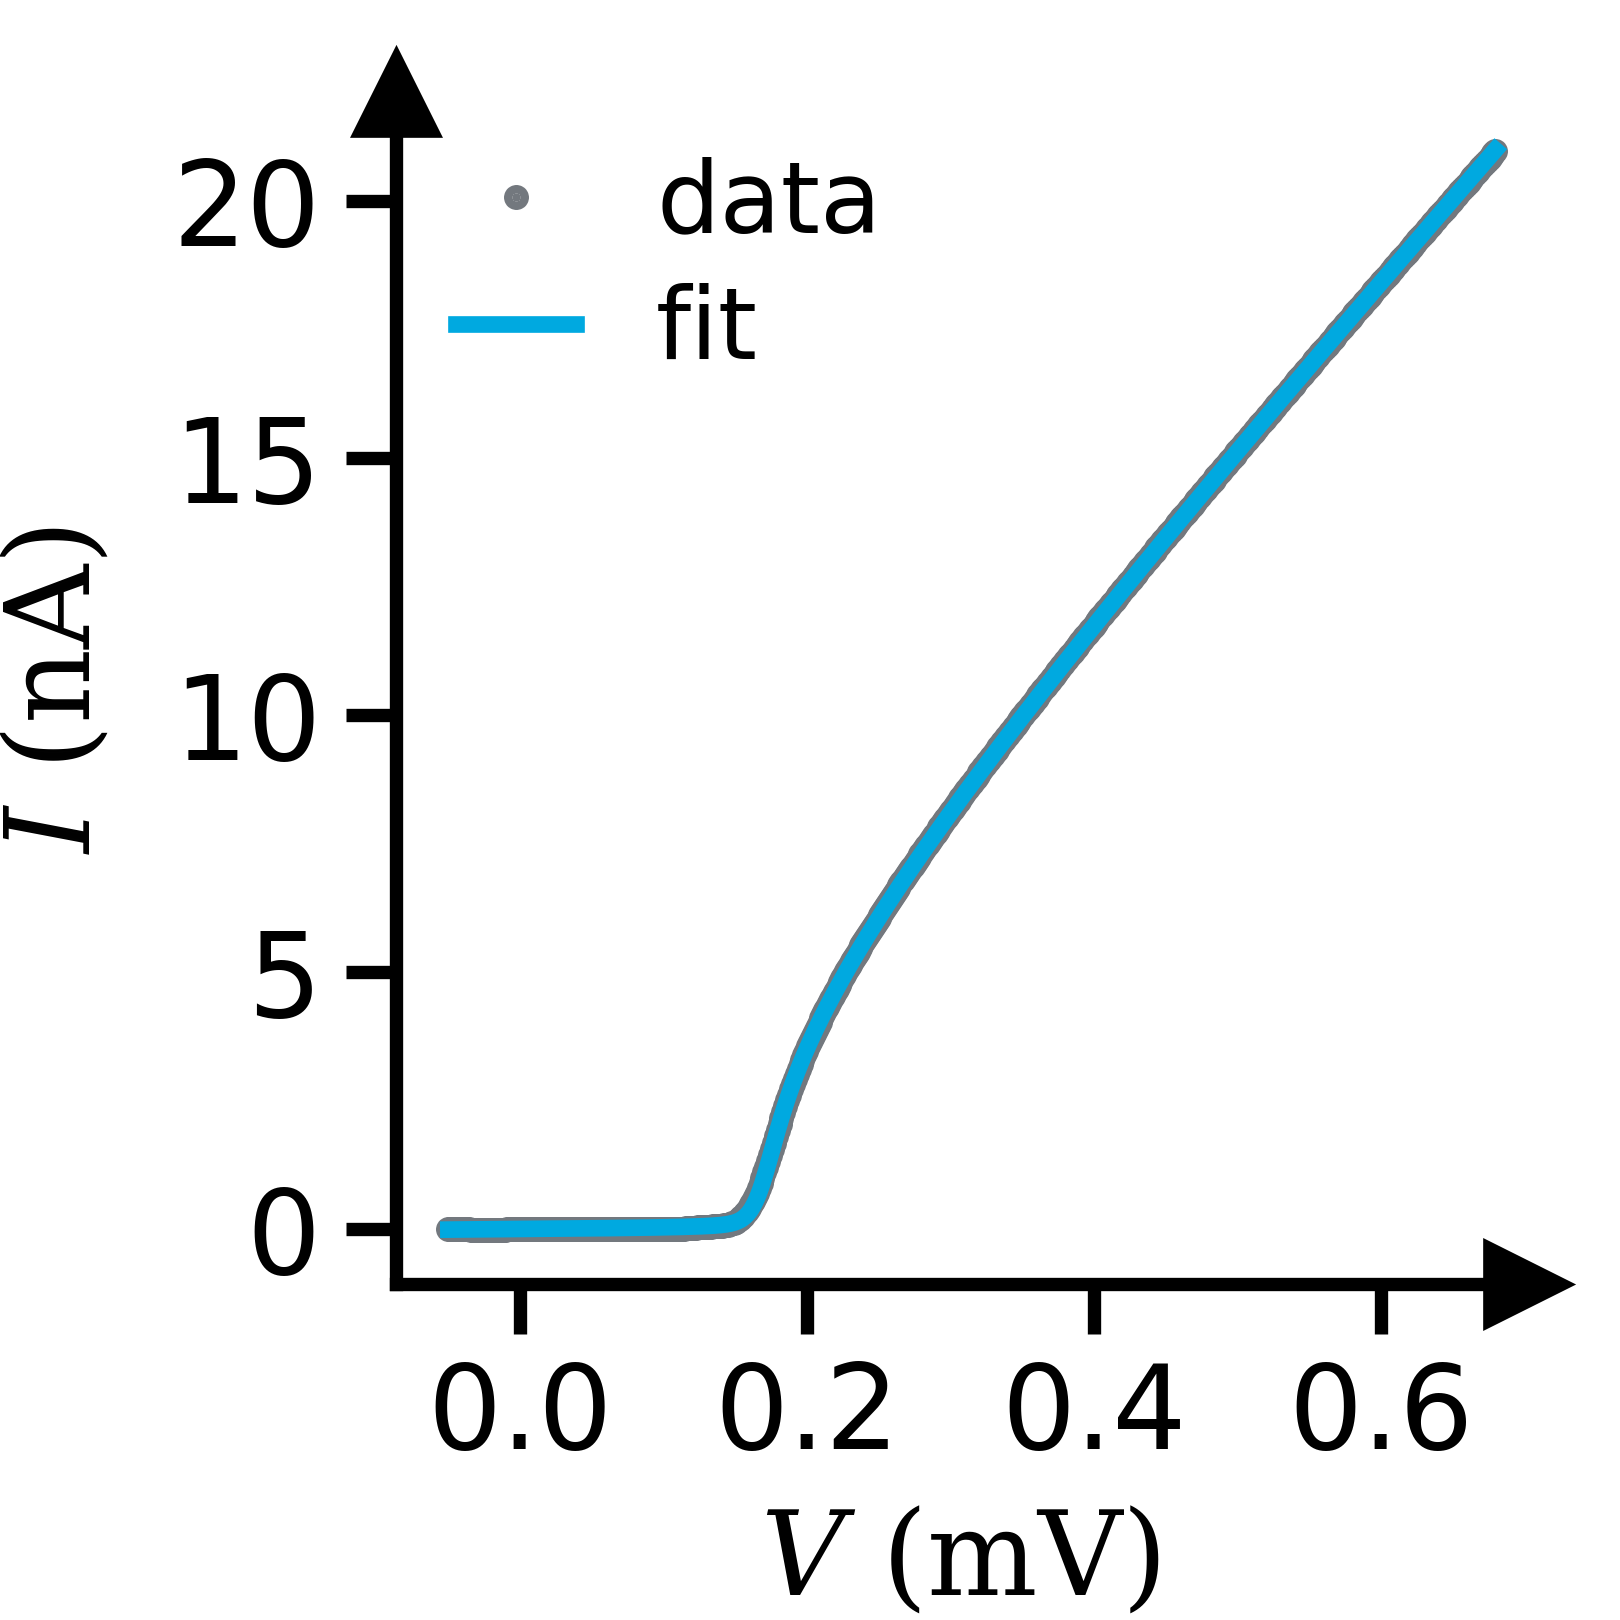

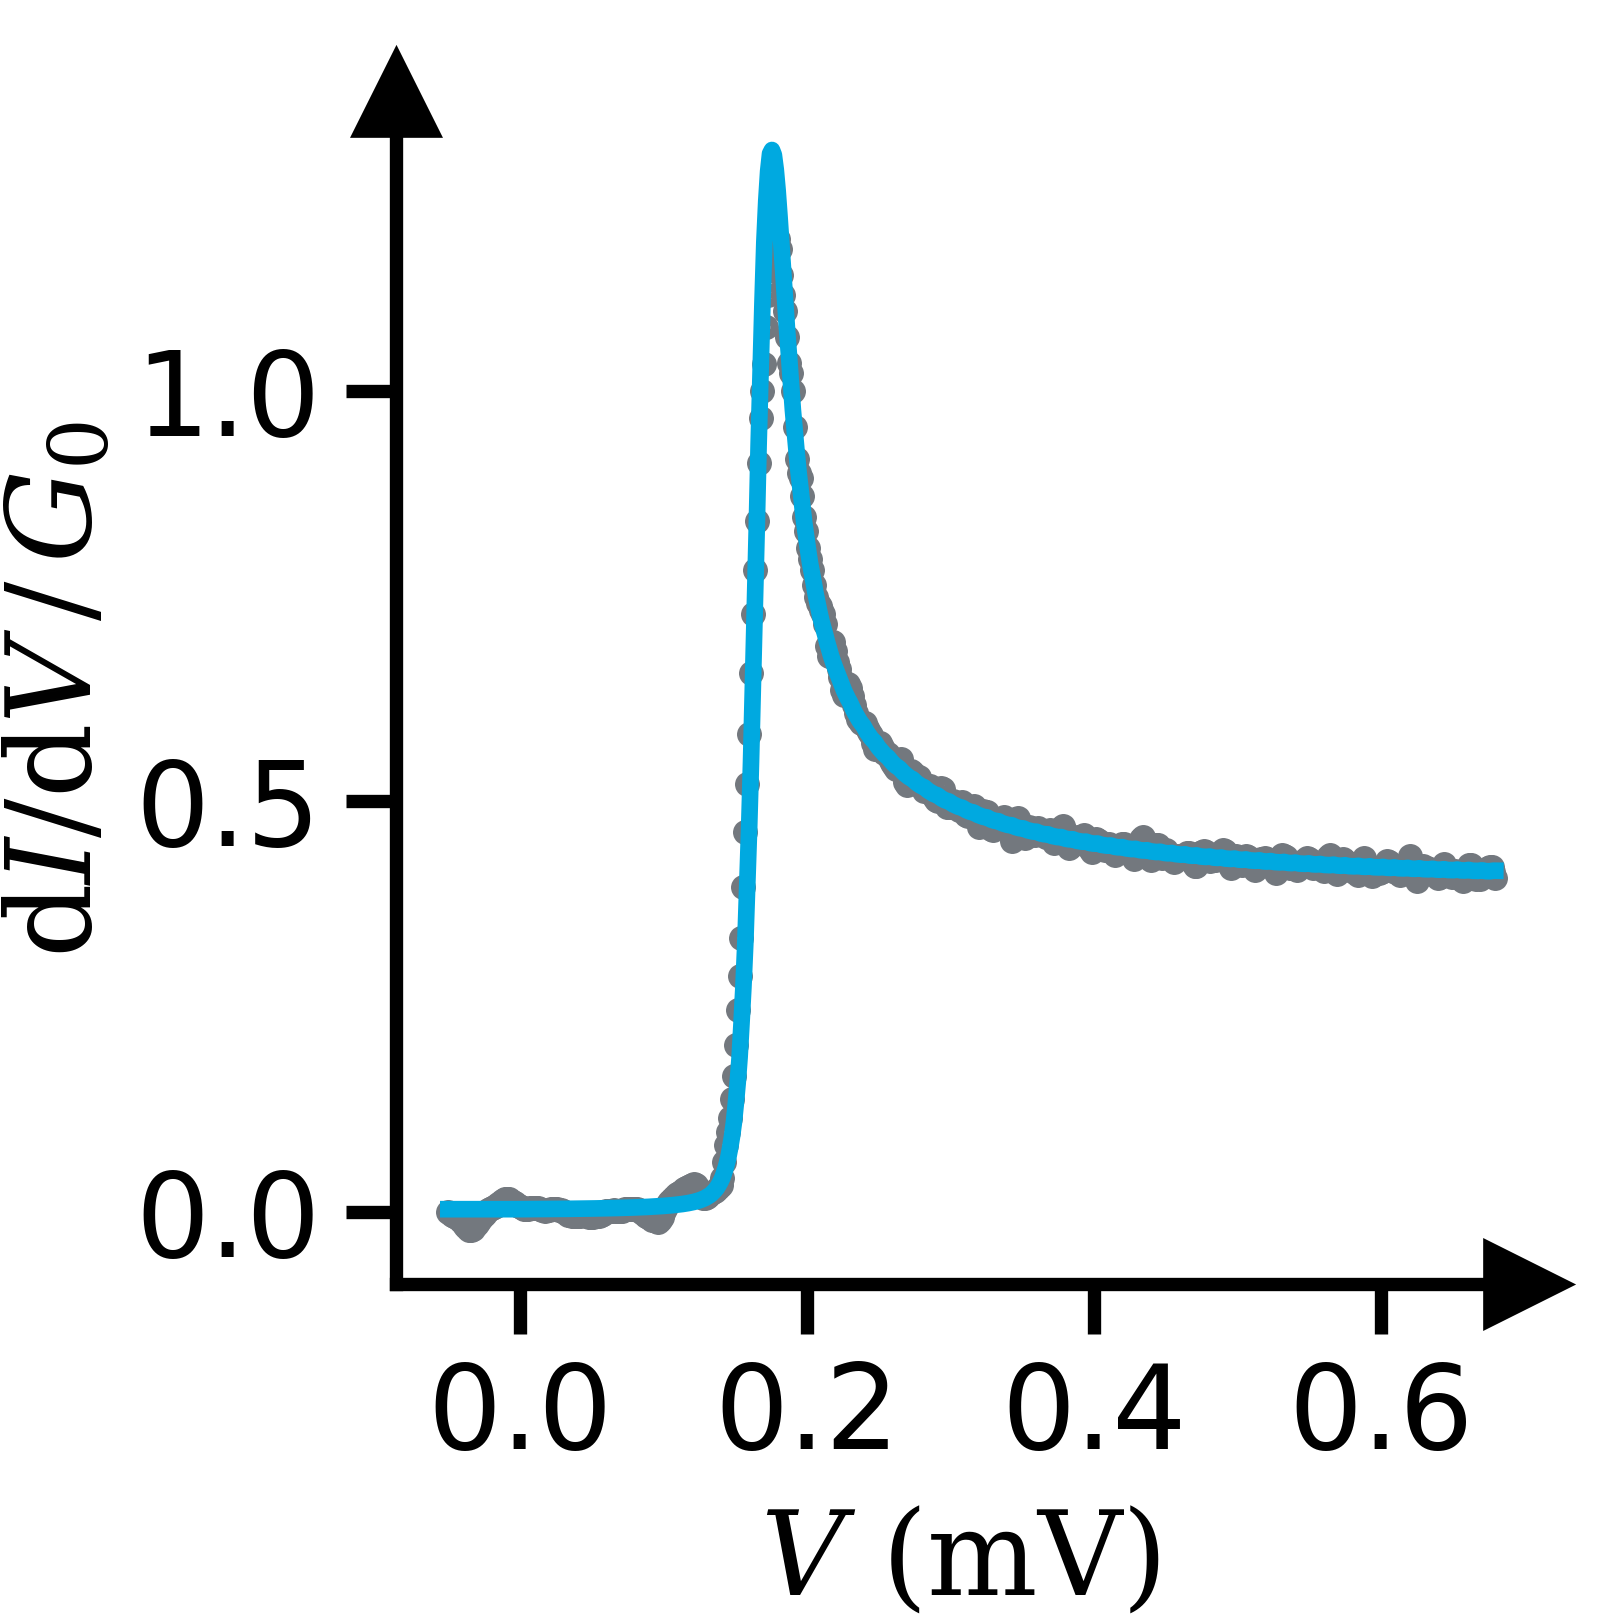

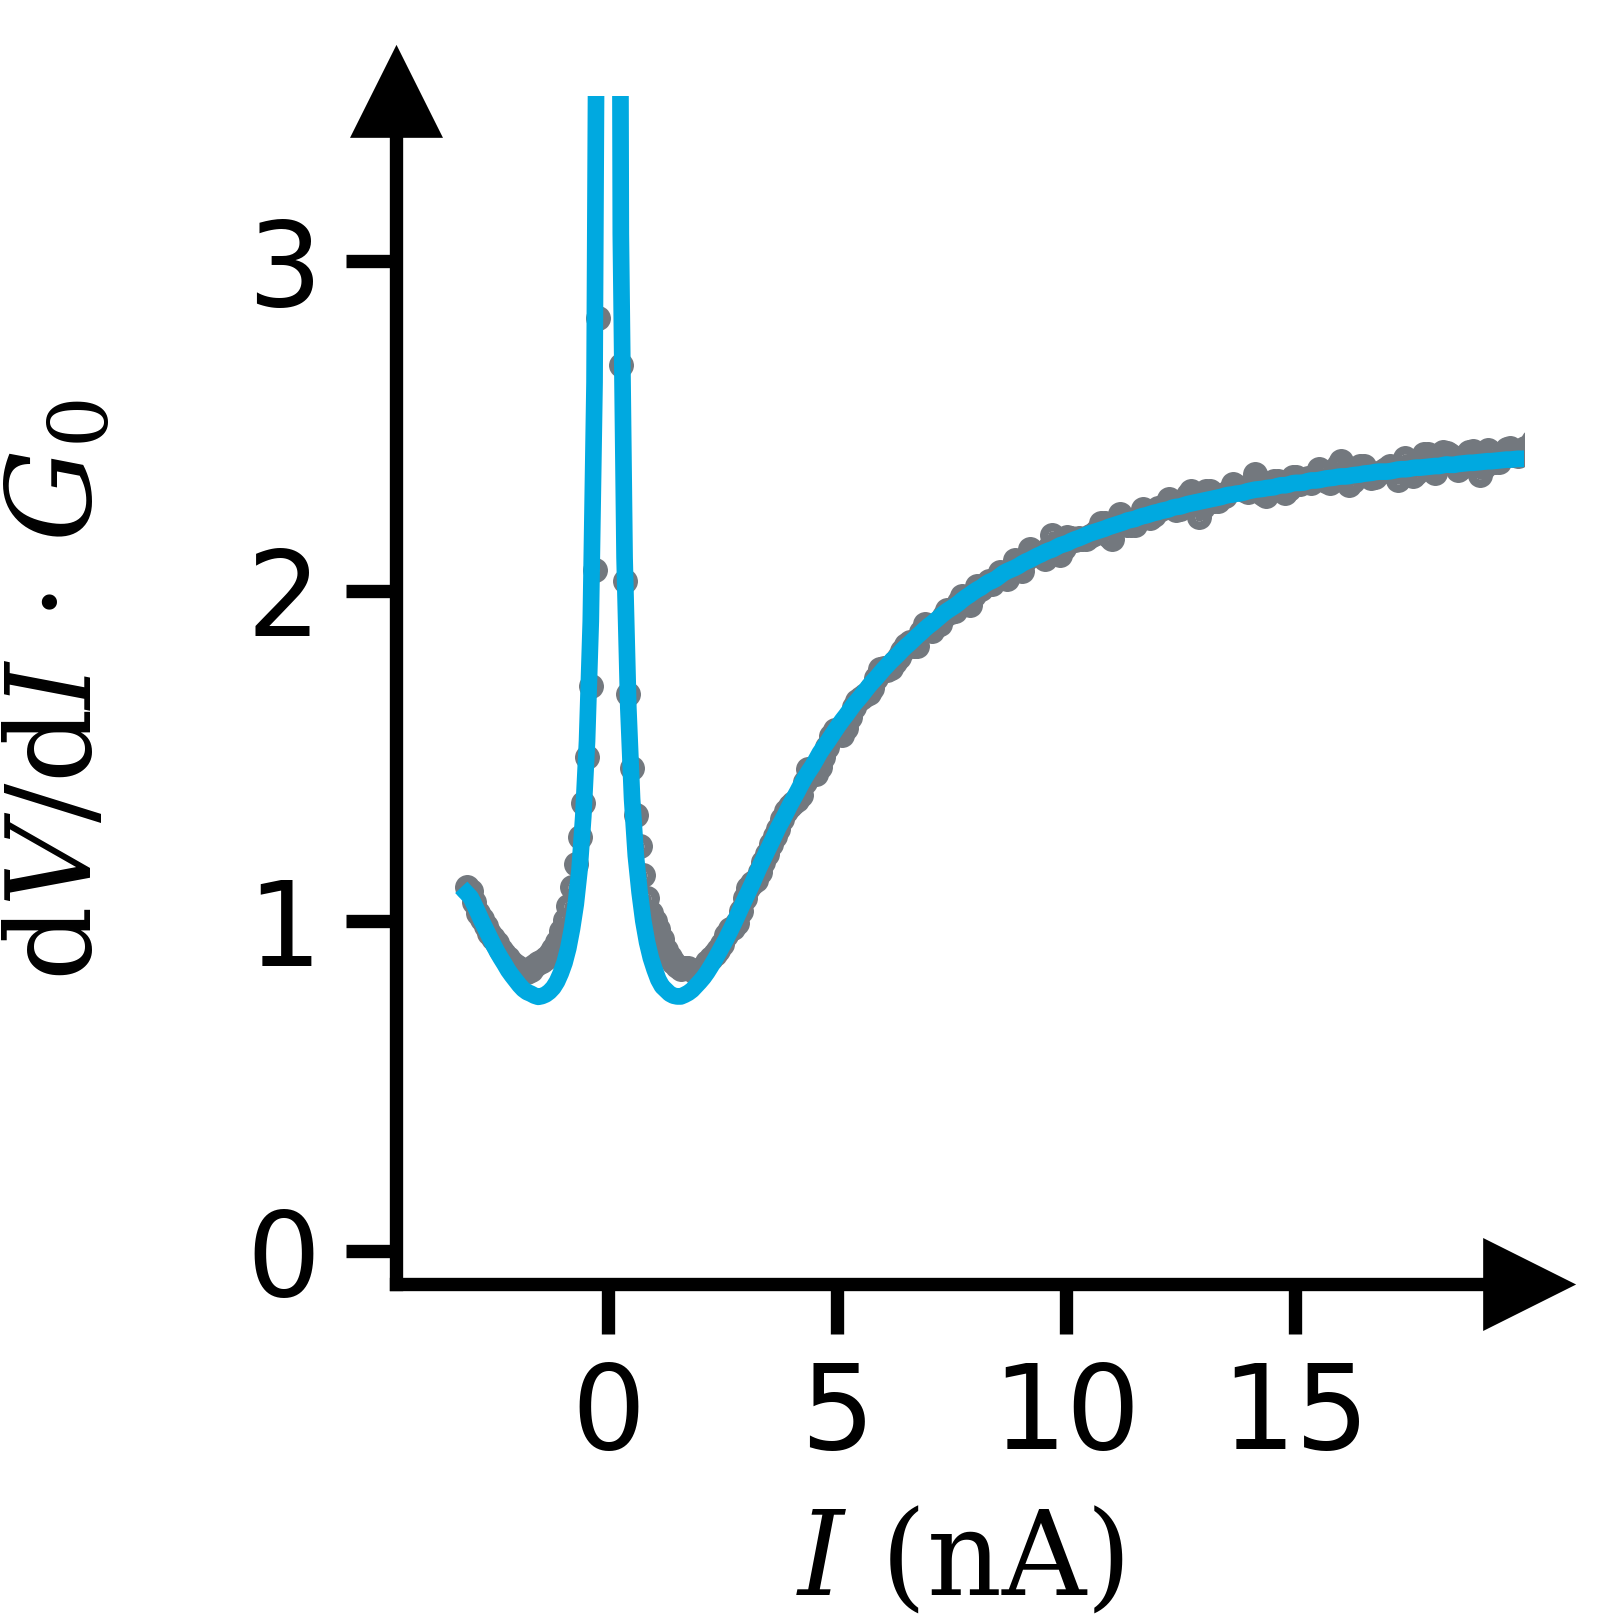

In [164]:
# plot single-iv tb

fig, ax = sc.get_figure(figsize=(1.35, 1.35), padding=(0.25, 0.2))
ax.plot(
    Vbias_mV,
    Iexp_nA,
    ".",
    color=sc.seegrau100,
    ms=1.0,
    label="data",
    zorder=-1,
)
ax.plot(
    Vbias_mV,
    Ifit_nA,
    "-",
    color=sc.seeblau100,
    label="fit",
    zorder=0,
)
# ax.set_yticks([0, 20, 40, 60])
# ax.set_ylim(None, 75)
ax.set_xticks([0, 0.2, 0.4, 0.6])
ax.set_xlim(None, 0.7)

ax.legend(
    # title="$\\alpha_q = $",
    handlelength=1.2,
    loc="upper left",
    frameon=False,
    fontsize=6,
    title_fontsize=6,
    ncols=1,
    columnspacing=0.8,
    borderpad=0.1,  # reduces padding inside the legend box
    labelspacing=0.3,  # reduces vertical spacing between items
    handletextpad=0.8,  # reduces spacing between line and label
    # bbox_to_anchor=(1.1, 1.1),
)
sc.theory_layout(
    fig,
    ax,
    f"ssn-set/ssn2-sin/iv",
    "$V\\ \\mathrm{(mV)}$",
    "$I\\ \\mathrm{(nA)}$",
)
plt.show()

fig, ax = sc.get_figure(figsize=(1.35, 1.35), padding=(0.25, 0.2))
ax.plot(Vbias_mV, dGexp_G0, ".", color=sc.seegrau100, ms=1.0)
ax.plot(Vbias_mV, dGfit_G0, "-", color=sc.seeblau100)
ax.set_xticks([0, 0.2, 0.4, 0.6])
ax.set_xlim(None, 0.7)
sc.theory_layout(
    fig,
    ax,
    f"ssn-set/ssn2-sin/didv",
    "$V\\ \\mathrm{(mV)}$",
    "$\\mathrm{d}I/\\mathrm{d}V\\,/\\,G_0$",
)
plt.show()

fig, ax = sc.get_figure(figsize=(1.35, 1.35), padding=(0.25, 0.2))
ax.plot(
    Ibias_nA,
    dRexp_R0,
    ".",
    color=sc.seegrau100,
    ms=1.0,
)
ax.plot(Ibias_nA, dRfit_R0, "-", color=sc.seeblau100)
ax.set_ylim(-0.1, 3.5)
ax.set_xlim(None, 20)
ax.set_xticks([0, 5, 10, 15])
sc.theory_layout(
    fig,
    ax,
    f"ssn-set/ssn2-sin/dvdi",
    "$I\\ \\mathrm{(nA)}$",
    "$\\mathrm{d}V/\\mathrm{d}I\\,\\cdot\\,G_0$",
)
plt.show()

DCB fit (approximate 1-sigma statistical uncertainties):
R_eff_kOhm = 0.44579 +/- 0.0033
C_eff_fF   = 4.36097 +/- 0.052
T_eff_mK   = 77.3657 +/- 6.1
G_T_uS     = 29.0461 +/- 0.026
G_T_G0     = 0.37488 +/- 0.00034
R_T_kOhm   = 34.428 +/- 0.031
V0_uV      = -0.326593 +/- 0.19
I0_nA      = -0.0845661 +/- 0.005
RMSE_nA    = 0.0127445


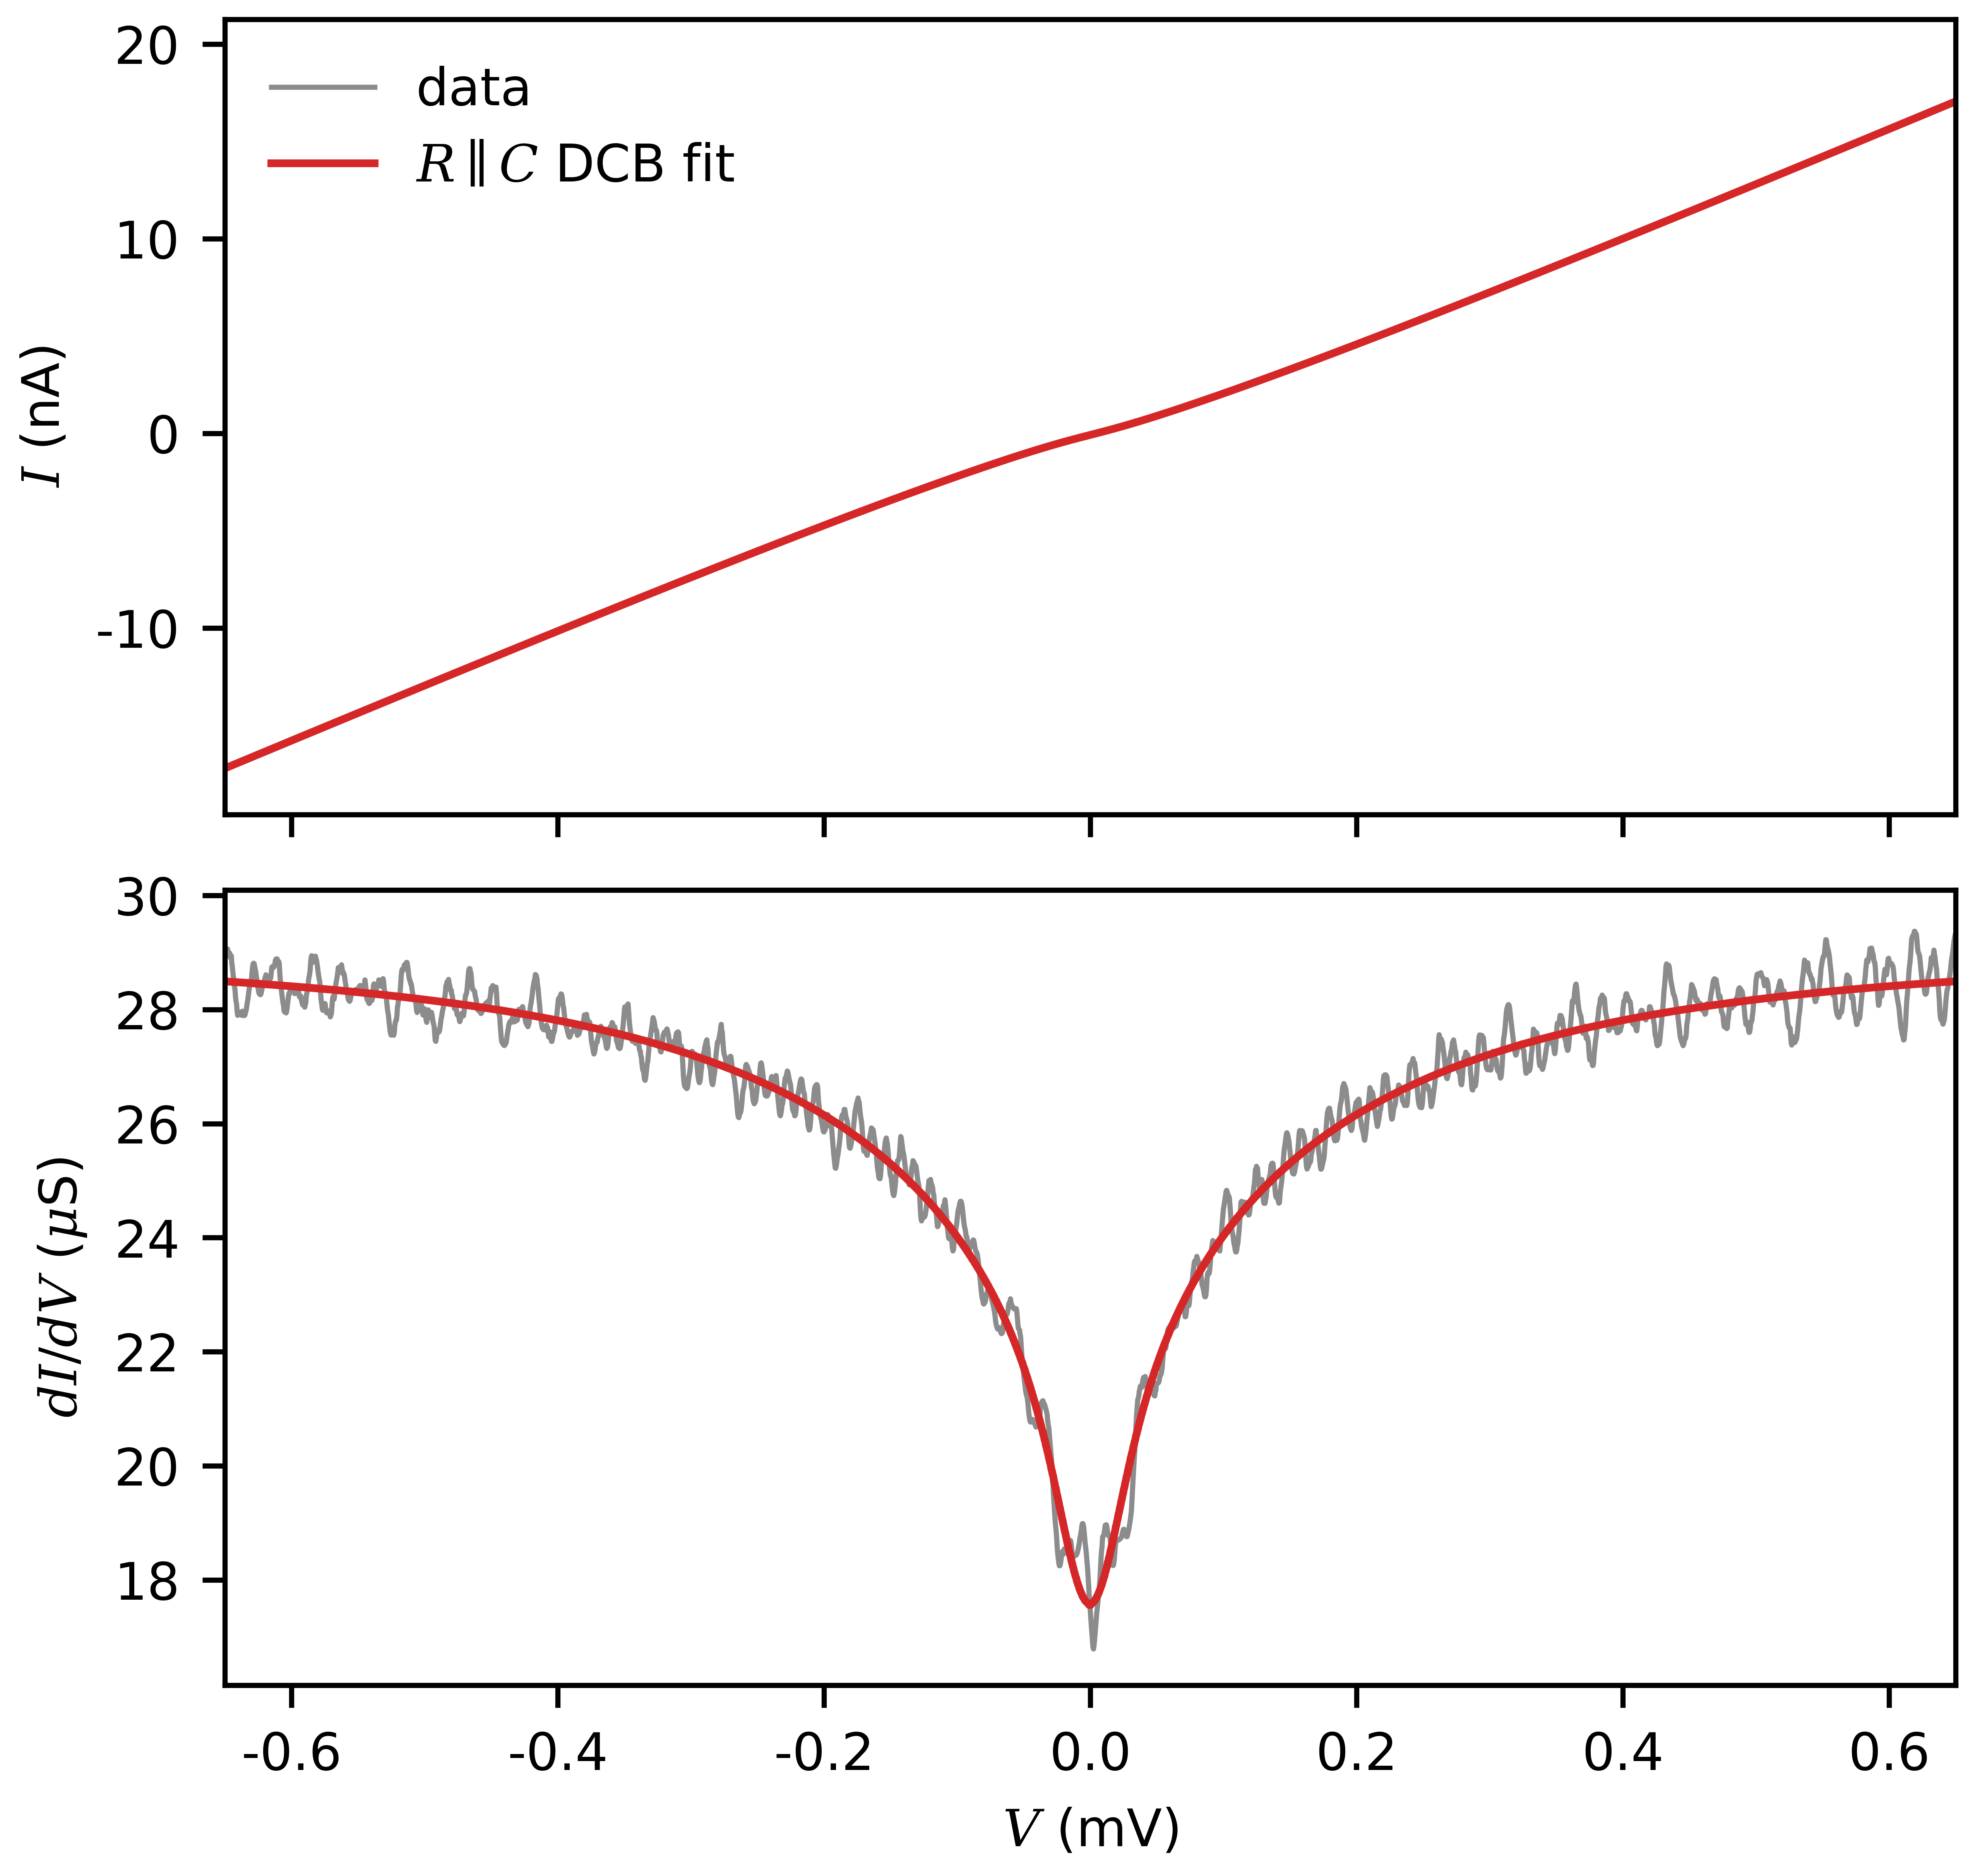

In [165]:
# get data single-iv dcb
file = "/Users/oliver/Documents/measurement data/SSET/22 03 Scheer2/36/NC_map.tdms"
key = "2022-03-30 17:05:31 G4.00mV"
nu_sample_Hz, amp, rref = 5000.0, (2000.0, 500.0), 102000.0
dt_sample_s = 0.00019999999999999998
nu_downsample_Hz = 437.0
dt_downsample_s = 1 / nu_downsample_Hz

sweep = (25_000, 75_000)

Vbias0_mV = np.linspace(-0.7, 0.7, 3501)

with TdmsFile.open(file) as f:
    sample_V = f[key]["Sample"].as_dataframe()
    reference_V = f[key]["Reference"].as_dataframe()
    sample_V = sample_V.values
    reference_V = reference_V.values

sample_V = sample_V[sweep[0] : sweep[1], 0]
reference_V = reference_V[sweep[0] : sweep[1], 0]
time_s = np.arange(len(sample_V)) * dt_sample_s

nu_time_s = np.arange(0, np.max(time_s), dt_downsample_s)
nu_sample_V = sc.bin_y_over_x(sample_V, time_s, nu_time_s)
nu_reference_V = sc.bin_y_over_x(reference_V, time_s, nu_time_s)

v_mV = nu_sample_V * 1e3 / amp[0]
i_nA = nu_reference_V * 1e9 / (amp[1] * rref)
valid = np.logical_and(np.isfinite(v_mV), np.isfinite(i_nA))
i_nA, v_mV = upsample(i_nA[valid]), upsample(v_mV[valid])
Iexp0_nA = sc.bin_y_over_x(i_nA, v_mV, Vbias0_mV) + 5

Vbias0_mV += 0.032
Iexp0_nA -= 0.26

Iexp0_nA = savgol_filter(Iexp0_nA, 50, 1)
from fit_dcb import simulate_dcb_nin_current_nA

Ifit0_nA = simulate_dcb_nin_current_nA(Vbias0_mV)

Vbias_mV = np.linspace(-0.05, 0.65, 551)
Ibias_nA = Vbias_mV * 29.046
Iexp_nA = sc.bin_y_over_x(upsample(Iexp0_nA), upsample(Vbias0_mV), Vbias_mV)
Vexp_mV = sc.bin_y_over_x(upsample(Vbias0_mV), upsample(Iexp0_nA), Ibias_nA)
Ifit_nA = sc.bin_y_over_x(upsample(Ifit0_nA), upsample(Vbias0_mV), Vbias_mV)
Vfit_mV = sc.bin_y_over_x(upsample(Vbias0_mV), upsample(Ifit0_nA), Ibias_nA)

dGexp_G0 = np.gradient(Iexp_nA, Vbias_mV) / sc.G0_muS
dRexp_R0 = np.gradient(Vexp_mV, Ibias_nA) * sc.G0_muS
dGfit_G0 = np.gradient(Ifit_nA, Vbias_mV) / sc.G0_muS
dRfit_R0 = np.gradient(Vfit_mV, Ibias_nA) * sc.G0_muS

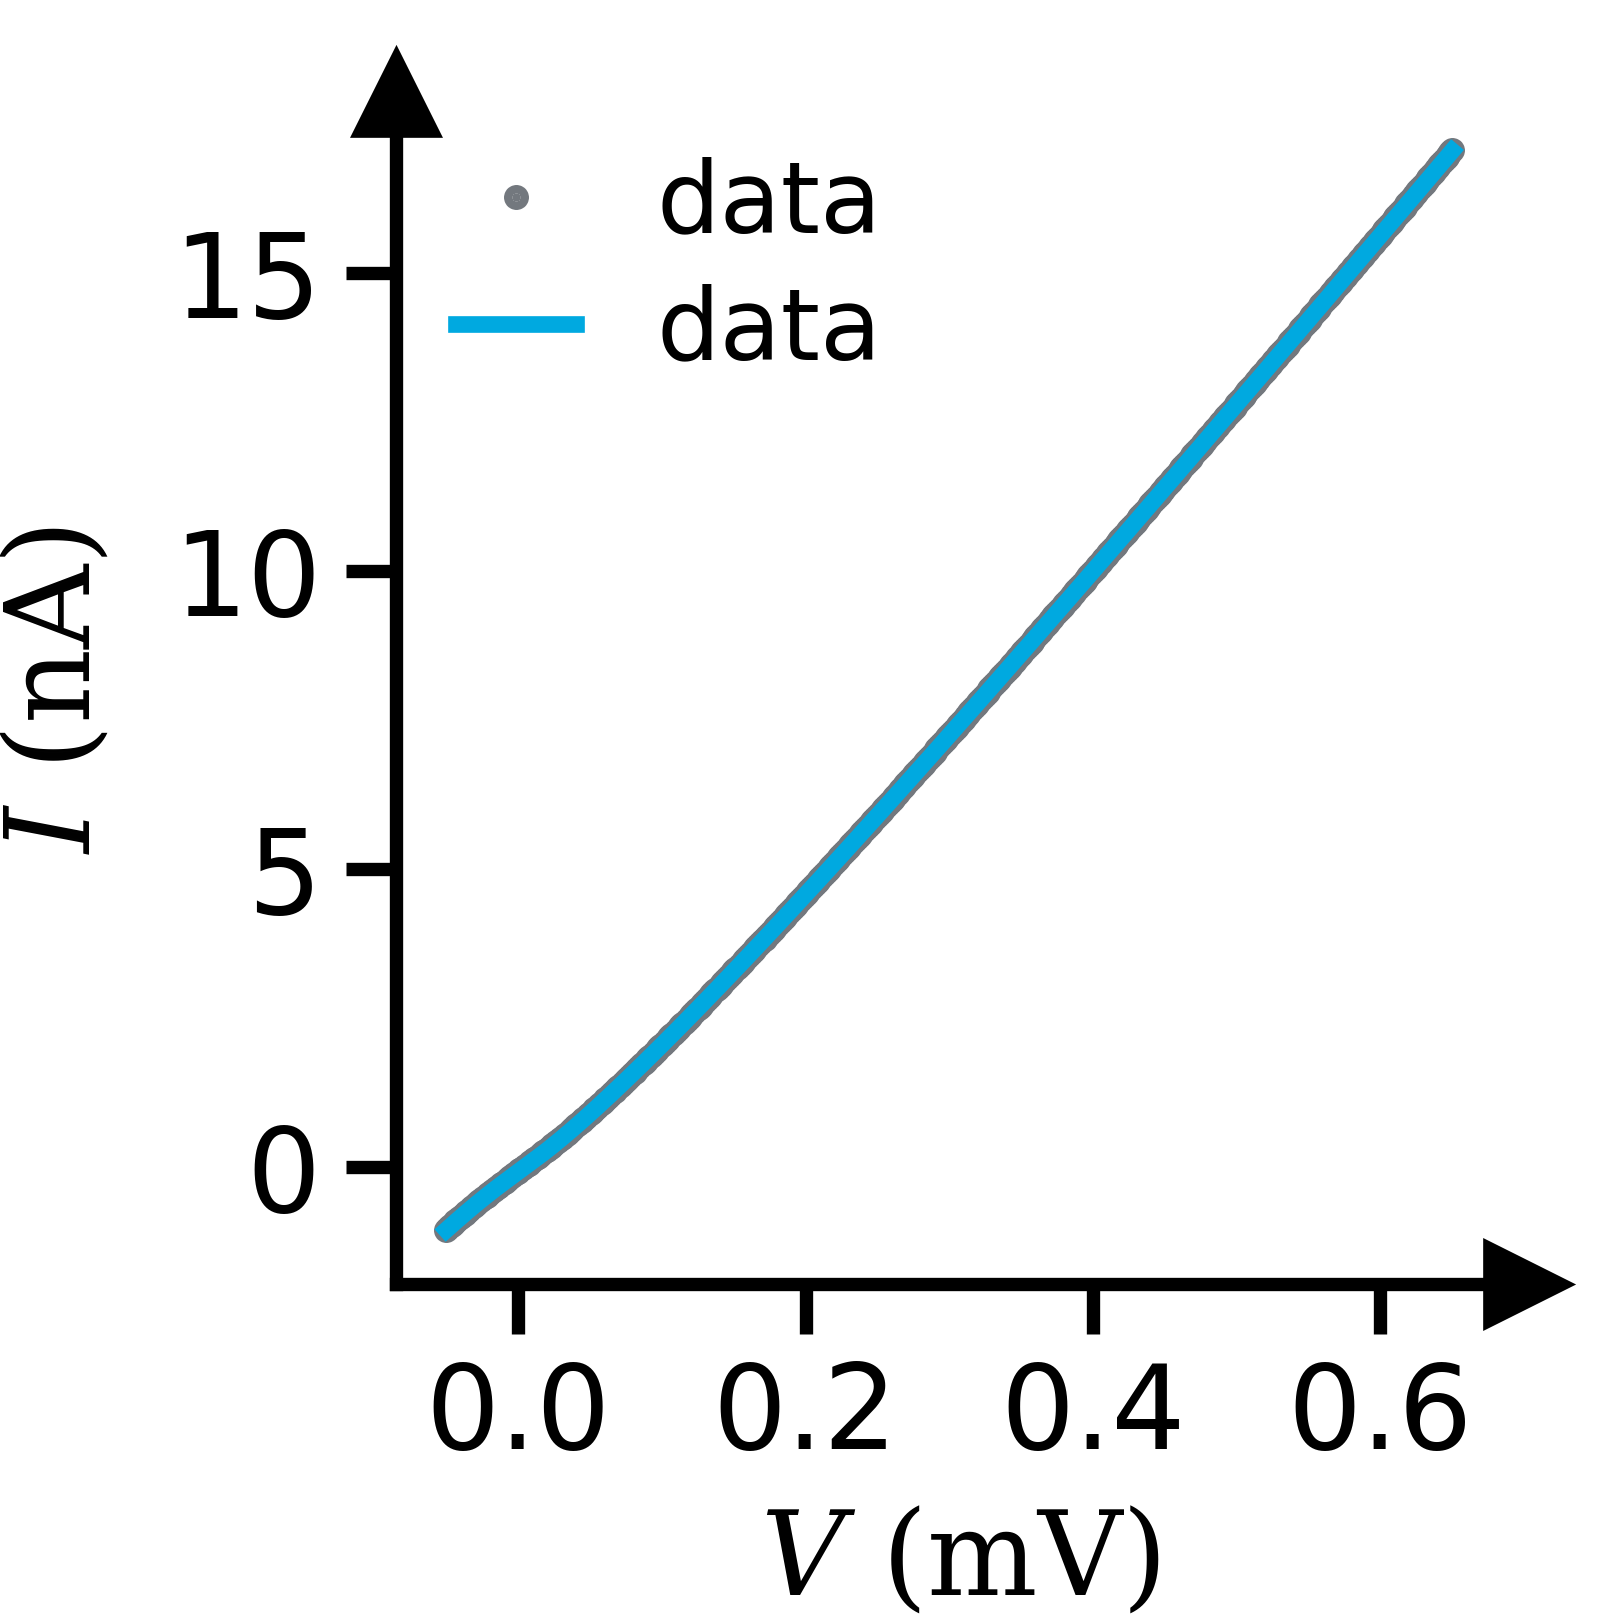

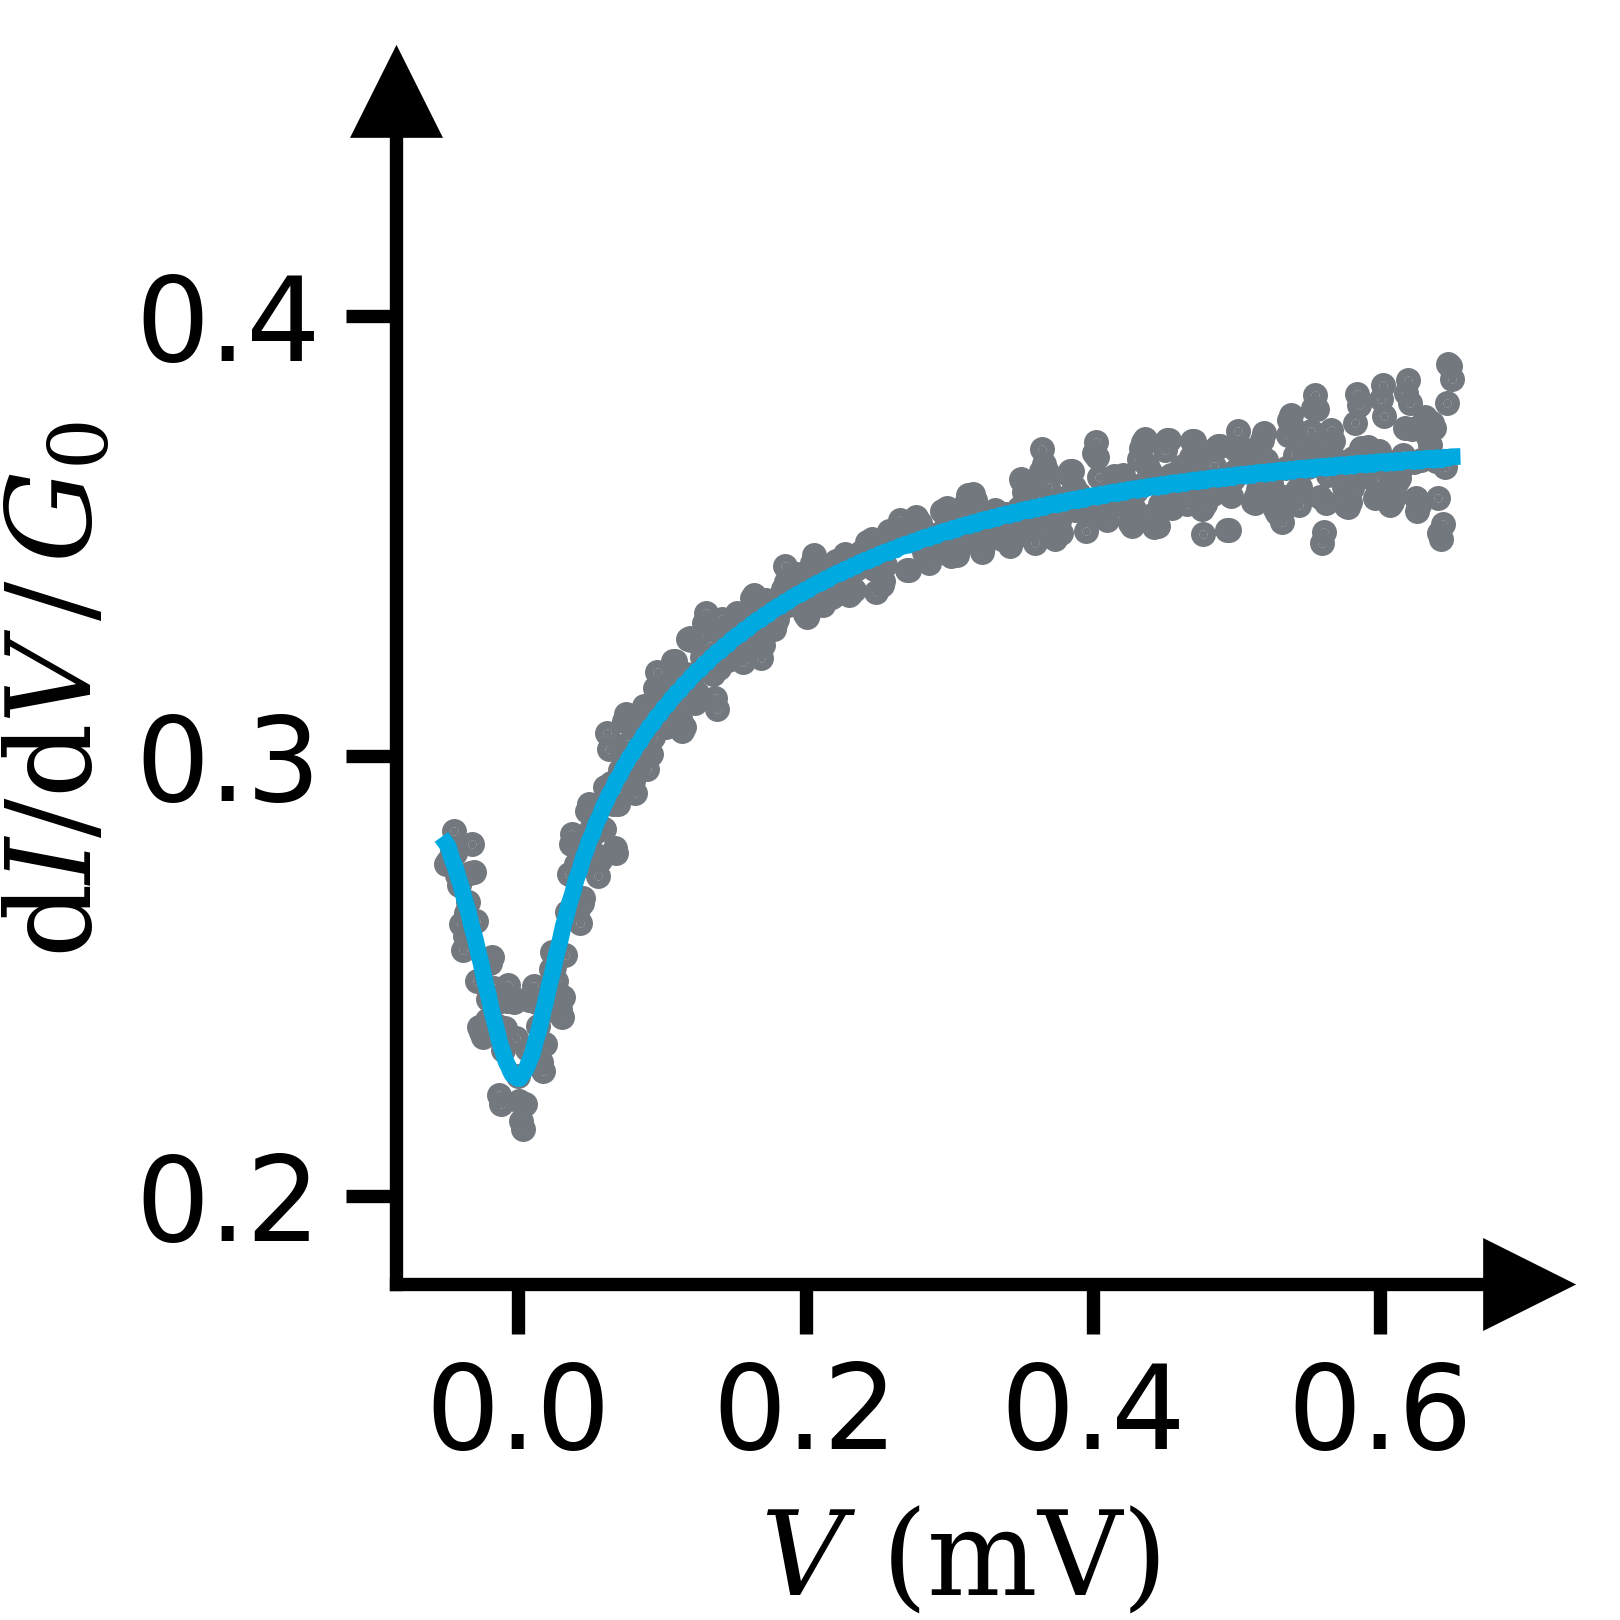

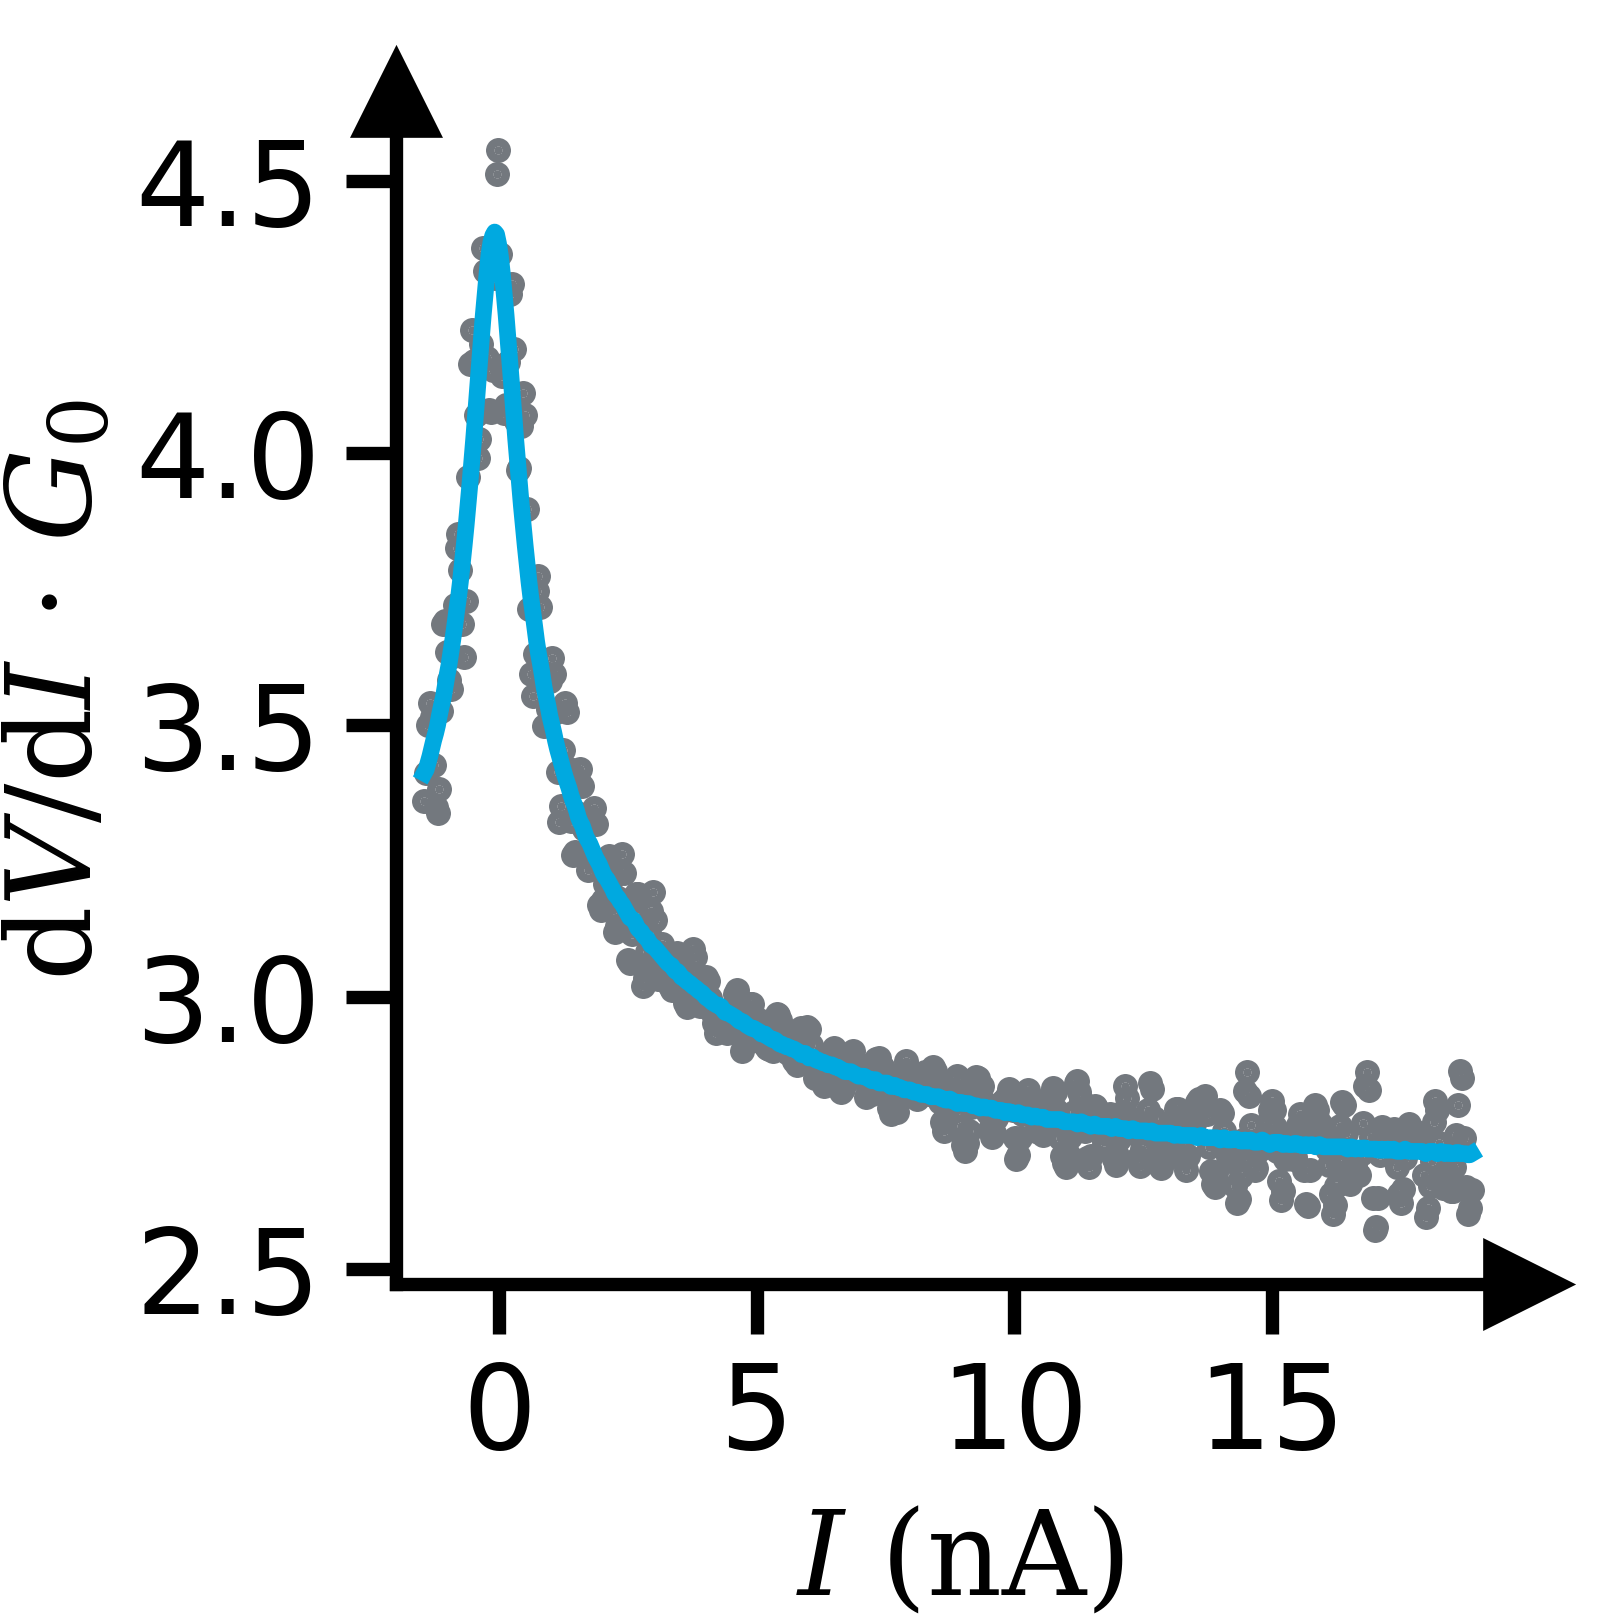

In [166]:
# plot single-iv dcb
fig, ax = sc.get_figure(figsize=(1.35, 1.35), padding=(0.25, 0.2))
ax.plot(
    Vbias_mV,
    Iexp_nA,
    ".",
    color=sc.seegrau100,
    ms=1.0,
    label="data",
    zorder=-1,
)
ax.plot(
    Vbias_mV,
    Ifit_nA,
    "-",
    color=sc.seeblau100,
    ms=1.0,
    label="data",
    zorder=1,
)
# ax.set_yticks([0, 20, 40, 60])
# ax.set_ylim(None, 75)
# ax.set_xticks([0, 0.2, 0.4])
ax.set_xticks([0, 0.2, 0.4, 0.6])
ax.set_xlim(None, 0.7)

ax.legend(
    # title="$\\alpha_q = $",
    handlelength=1.2,
    loc="upper left",
    frameon=False,
    fontsize=6,
    title_fontsize=6,
    ncols=1,
    columnspacing=0.8,
    borderpad=0.1,  # reduces padding inside the legend box
    labelspacing=0.3,  # reduces vertical spacing between items
    handletextpad=0.8,  # reduces spacing between line and label
    # bbox_to_anchor=(1.1, 1.1),
)
sc.theory_layout(
    fig,
    ax,
    f"ssn-set/ssn2-dcb/iv",
    "$V\\ \\mathrm{(mV)}$",
    "$I\\ \\mathrm{(nA)}$",
)
plt.show()

fig, ax = sc.get_figure(figsize=(1.35, 1.35), padding=(0.25, 0.2))
ax.plot(
    Vbias_mV,
    dGexp_G0,
    ".",
    color=sc.seegrau100,
    ms=1.0,
)
ax.plot(
    Vbias_mV,
    dGfit_G0,
    "-",
    color=sc.seeblau100,
    ms=1.0,
    label="data",
    zorder=5,
)
ax.set_xticks([0, 0.2, 0.4, 0.6])
ax.set_xlim(None, 0.7)
ax.set_yticks([0.2, 0.3, 0.4])
ax.set_ylim(0.18, 0.45)
sc.theory_layout(
    fig,
    ax,
    f"ssn-set/ssn2-dcb/didv",
    "$V\\ \\mathrm{(mV)}$",
    "$\\mathrm{d}I/\\mathrm{d}V\\,/\\,G_0$",
)
plt.show()

fig, ax = sc.get_figure(figsize=(1.35, 1.35), padding=(0.25, 0.2))
ax.plot(
    Ibias_nA,
    dRexp_R0,
    ".",
    color=sc.seegrau100,
    ms=1.0,
)
ax.plot(
    Ibias_nA,
    dRfit_R0,
    "-",
    color=sc.seeblau100,
    ms=1.0,
    label="data",
    zorder=3,
)
ax.set_xticks([0, 5, 10, 15])
ax.set_xlim(-2, None)
sc.theory_layout(
    fig,
    ax,
    f"ssn-set/ssn2-dcb/dvdi",
    "$I\\ \\mathrm{(nA)}$",
    "$\\mathrm{d}V/\\mathrm{d}I\\,\\cdot\\,G_0$",
)
plt.show()

In [167]:
# get data single-iv dcb-ssn
file = "/Users/oliver/Documents/measurement data/SSET/22 03 Scheer2/36/SC_map.tdms"
key = "2022-03-31 08:53:52 G-4.00mV"
nu_sample_Hz, amp, rref = 5000.0, (2000.0, 500.0), 102000.0
dt_sample_s = 0.00019999999999999998
nu_downsample_Hz = 437.0
dt_downsample_s = 1 / nu_downsample_Hz

sweep = (25_000, 75_000)

Vbias0_mV = np.linspace(-0.9, 0.9, 3501)

with TdmsFile.open(file) as f:
    sample_V = f[key]["Sample"].as_dataframe()
    reference_V = f[key]["Reference"].as_dataframe()
    sample_V = sample_V.values
    reference_V = reference_V.values

sample_V = sample_V[sweep[0] : sweep[1], 0]
reference_V = reference_V[sweep[0] : sweep[1], 0]
time_s = np.arange(len(sample_V)) * dt_sample_s

nu_time_s = np.arange(0, np.max(time_s), dt_downsample_s)
nu_sample_V = sc.bin_y_over_x(sample_V, time_s, nu_time_s)
nu_reference_V = sc.bin_y_over_x(reference_V, time_s, nu_time_s)

v_mV = nu_sample_V * 1e3 / amp[0] + 0.0245
i_nA = nu_reference_V * 1e9 / (amp[1] * rref) + 4.8
valid = np.logical_and(np.isfinite(v_mV), np.isfinite(i_nA))
i_nA, v_mV = upsample(i_nA[valid]), upsample(v_mV[valid])
Iexp0_nA = sc.bin_y_over_x(i_nA, v_mV, Vbias0_mV)

Ifit0_nA = simulate_sin_current_nA(
    Vbias0_mV,
    G_T_uS=26.0776,
    T_K=0.12163,
    Delta_meV=0.195941,
    gamma_meV=0.000875309,
    V0_uV=-3.28572,
    I0_nA=0.00102436,
)
Isim0_nA = simulate_sin_current_nA(
    Vbias0_mV,
    G_T_uS=31.1261,
    T_K=0.12163,
    Delta_meV=0.195941,
    gamma_meV=0.000875309,
    V0_uV=-3.28572,
    I0_nA=0.00102436,
)

Iexp0_nA = savgol_filter(Iexp0_nA, 50, 1)

valid = np.isfinite(Iexp0_nA)
Vbias_mV = np.linspace(-0.05, 0.65, 701)
Ibias_nA = Vbias_mV * 29.046
Iexp_nA = sc.bin_y_over_x(
    upsample(Iexp0_nA[valid]), upsample(Vbias0_mV[valid]), Vbias_mV
)
Vexp_mV = sc.bin_y_over_x(
    upsample(Vbias0_mV[valid]), upsample(Iexp0_nA[valid]), Ibias_nA
)
Ifit_nA = sc.bin_y_over_x(upsample(Ifit0_nA), upsample(Vbias0_mV), Vbias_mV)
Vfit_mV = sc.bin_y_over_x(upsample(Vbias0_mV), upsample(Ifit0_nA), Ibias_nA)
Isim_nA = sc.bin_y_over_x(upsample(Isim0_nA), upsample(Vbias0_mV), Vbias_mV)
Vsim_mV = sc.bin_y_over_x(upsample(Vbias0_mV), upsample(Isim0_nA), Ibias_nA)

dGexp_G0 = np.gradient(Iexp_nA, Vbias_mV) / sc.G0_muS
dRexp_R0 = np.gradient(Vexp_mV, Ibias_nA) * sc.G0_muS
dGfit_G0 = np.gradient(Ifit_nA, Vbias_mV) / sc.G0_muS
dRfit_R0 = np.gradient(Vfit_mV, Ibias_nA) * sc.G0_muS
dGsim_G0 = np.gradient(Isim_nA, Vbias_mV) / sc.G0_muS
dRsim_R0 = np.gradient(Vsim_mV, Ibias_nA) * sc.G0_muS

In [171]:
# plot single-iv dcb-ssn
%matplotlib qt
fig, ax = sc.get_figure(figsize=(1.35, 1.35), padding=(0.25, 0.2))
ax.plot(
    Vbias_mV,
    Iexp_nA,
    ".",
    color=sc.seegrau100,
    ms=1.0,
    label="data",
    zorder=-1,
)
ax.plot(
    Vbias_mV,
    Ifit_nA,
    "-",
    color=sc.seeblau100,
    label="fit LB",
    zorder=0,
)
ax.plot(
    Vbias_mV,
    Isim_nA,
    "-",
    color=sc.seegrau65,
    label="ref HB",
    zorder=-2,
)
ax.set_xticks([0, 0.2, 0.4, 0.6])
ax.set_xlim(None, 0.7)
ax.set_yticks([0, 5, 10, 15])
# ax.set_yticks([0, 20, 40, 60])
# ax.set_ylim(None, 75)
# ax.set_xticks([0, 0.2, 0.4])
# ax.set_xlim(-0.1, 0.49)

ax.legend(
    # title="$\\alpha_q = $",
    handlelength=1.2,
    loc="upper left",
    frameon=False,
    fontsize=6,
    title_fontsize=6,
    ncols=1,
    columnspacing=0.8,
    borderpad=0.1,  # reduces padding inside the legend box
    labelspacing=0.3,  # reduces vertical spacing between items
    handletextpad=0.8,  # reduces spacing between line and label
    # bbox_to_anchor=(1.1, 1.1),
)
sc.theory_layout(
    fig,
    ax,
    f"ssn-set/ssn2-sin-dcb/iv",
    "$V\\ \\mathrm{(mV)}$",
    "$I\\ \\mathrm{(nA)}$",
)
plt.show()

fig, ax = sc.get_figure(figsize=(1.35, 1.35), padding=(0.25, 0.2))
ax.plot(Vbias_mV, dGsim_G0, "-", color=sc.seegrau65)
ax.plot(Vbias_mV, dGexp_G0, ".", color=sc.seegrau100, ms=1.0)
ax.plot(Vbias_mV, dGfit_G0, "-", color=sc.seeblau100)
# ax.set_xticks([0, 0.2, 0.4])
# ax.set_xlim(-0.1, 0.49)
ax.set_xticks([0, 0.2, 0.4, 0.6])
ax.set_xlim(None, 0.7)
ax.set_ylim(None, 1.3)
sc.theory_layout(
    fig,
    ax,
    f"ssn-set/ssn2-sin-dcb/didv",
    "$V\\ \\mathrm{(mV)}$",
    "$\\mathrm{d}I/\\mathrm{d}V\\,/\\,G_0$",
)
plt.show()

fig, ax = sc.get_figure(figsize=(1.35, 1.35), padding=(0.25, 0.2))
ax.plot(Ibias_nA, dRsim_R0, "-", color=sc.seegrau65)
ax.plot(
    Ibias_nA,
    dRexp_R0,
    ".",
    color=sc.seegrau100,
    ms=1.0,
)
ax.plot(Ibias_nA, dRfit_R0, "-", color=sc.seeblau100)
ax.set_ylim(0.8, 3.8)
ax.set_xticks([0, 5, 10, 15])
sc.theory_layout(
    fig,
    ax,
    f"ssn-set/ssn2-sin-dcb/dvdi",
    "$I\\ \\mathrm{(nA)}$",
    "$\\mathrm{d}V/\\mathrm{d}I\\,\\cdot\\,G_0$",
)
plt.show()

# SSN-SET (1) - CB
### TB

SIN fit (approximate 1-sigma statistical uncertainties):
G_T_uS     = 30.8816 +/- 0.0028
G_T_G0     = 0.39857 +/- 3.6e-05
R_T_kOhm   = 32.3818 +/- 0.0029
T_mK       = 68.1031 +/- 0.53
Delta_ueV  = 196.106 +/- 0.009
gamma_ueV  = 0.861366 +/- 0.028
sigmaV_uV  = 0 (fixed)
V0_uV      = -4.55651 +/- 0.019
I0_nA      = -0.108184 +/- 0.00066
RMSE_nA    = 0.00953912


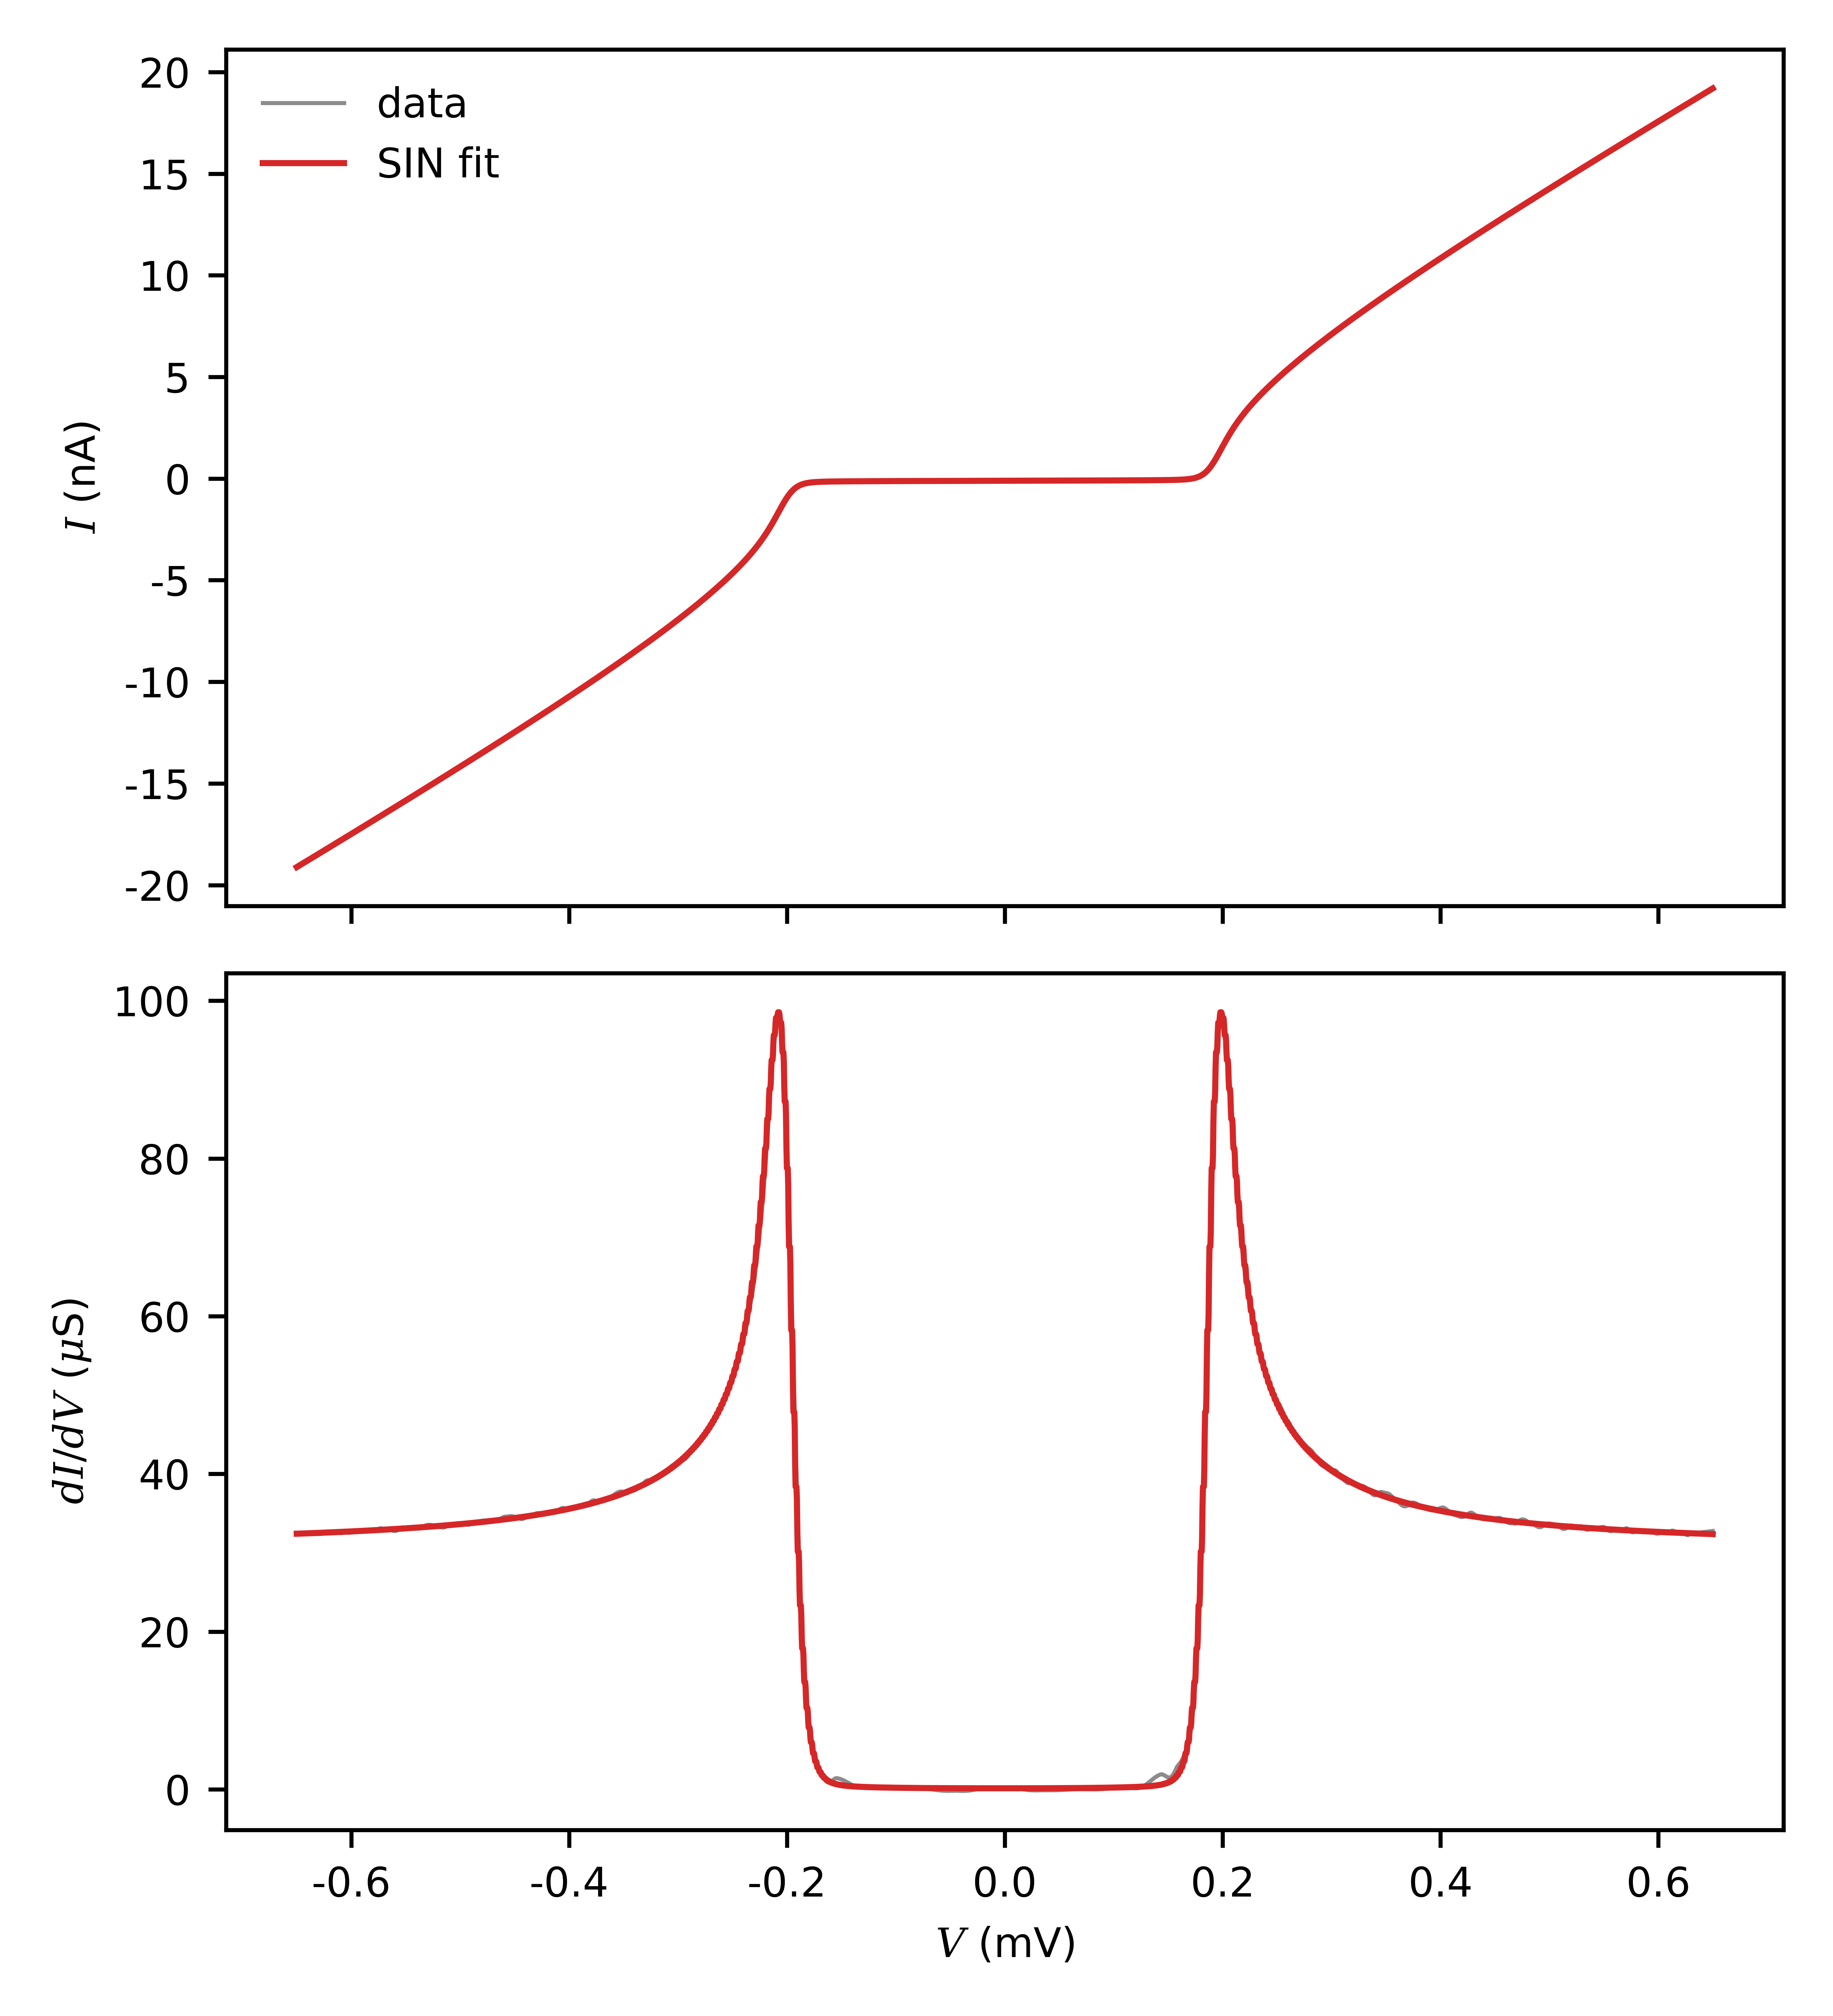

In [2]:
# get data single-iv tb
file = "/Users/oliver/Documents/measurement data/SSET/22 02b Scheer2/36_9 - unbroken/SCGateMap.tdms"
key = "2022-02-17 20:45:50 G3.60mV"
nu_sample_Hz, amp, rref = 5000.0, (2000.0, 1000.0), 102000.0
dt_sample_s = 0.00019999999999999998
nu_downsample_Hz = 43.7
dt_downsample_s = 1 / nu_downsample_Hz

sweep = (25_000, 75_000)

Vbias0_mV = np.linspace(-0.7, 0.7, 3501)

with TdmsFile.open(file) as f:
    sample_V = f[key]["Sample"].as_dataframe()
    reference_V = f[key]["Reference"].as_dataframe()
    sample_V = sample_V.values
    reference_V = reference_V.values

sample_V = sample_V[sweep[0] : sweep[1], 0]
reference_V = reference_V[sweep[0] : sweep[1], 0]
time_s = np.arange(len(sample_V)) * dt_sample_s

nu_time_s = np.arange(0, np.max(time_s), dt_downsample_s)
nu_sample_V = sc.bin_y_over_x(sample_V, time_s, nu_time_s)
nu_reference_V = sc.bin_y_over_x(reference_V, time_s, nu_time_s)

v_mV = nu_sample_V * 1e3 / amp[0]
i_nA = nu_reference_V * 1e9 / (amp[1] * rref)
valid = np.logical_and(np.isfinite(v_mV), np.isfinite(i_nA))
i_nA, v_mV = upsample(i_nA[valid]), upsample(v_mV[valid])
Iexp0_nA = sc.bin_y_over_x(i_nA, v_mV, Vbias0_mV)

from fit_sin import simulate_sin_current_nA

Ifit0_nA = simulate_sin_current_nA(Vbias0_mV)

valid = np.isfinite(Iexp0_nA)
Vbias_mV = np.linspace(-0.05, 0.5, 551)
Ibias_nA = Vbias_mV * 61.7631
Iexp_nA = sc.bin_y_over_x(
    upsample(Iexp0_nA[valid]), upsample(Vbias0_mV[valid]), Vbias_mV
)
Vexp_mV = sc.bin_y_over_x(
    upsample(Vbias0_mV[valid]), upsample(Iexp0_nA[valid]), Ibias_nA
)
Ifit_nA = sc.bin_y_over_x(upsample(Ifit0_nA), upsample(Vbias0_mV), Vbias_mV)
Vfit_mV = sc.bin_y_over_x(upsample(Vbias0_mV), upsample(Ifit0_nA), Ibias_nA)

dGexp_G0 = np.gradient(Iexp_nA, Vbias_mV) / sc.G0_muS
dRexp_R0 = np.gradient(Vexp_mV, Ibias_nA) * sc.G0_muS
dGfit_G0 = np.gradient(Ifit_nA, Vbias_mV) / sc.G0_muS
dRfit_R0 = np.gradient(Vfit_mV, Ibias_nA) * sc.G0_muS

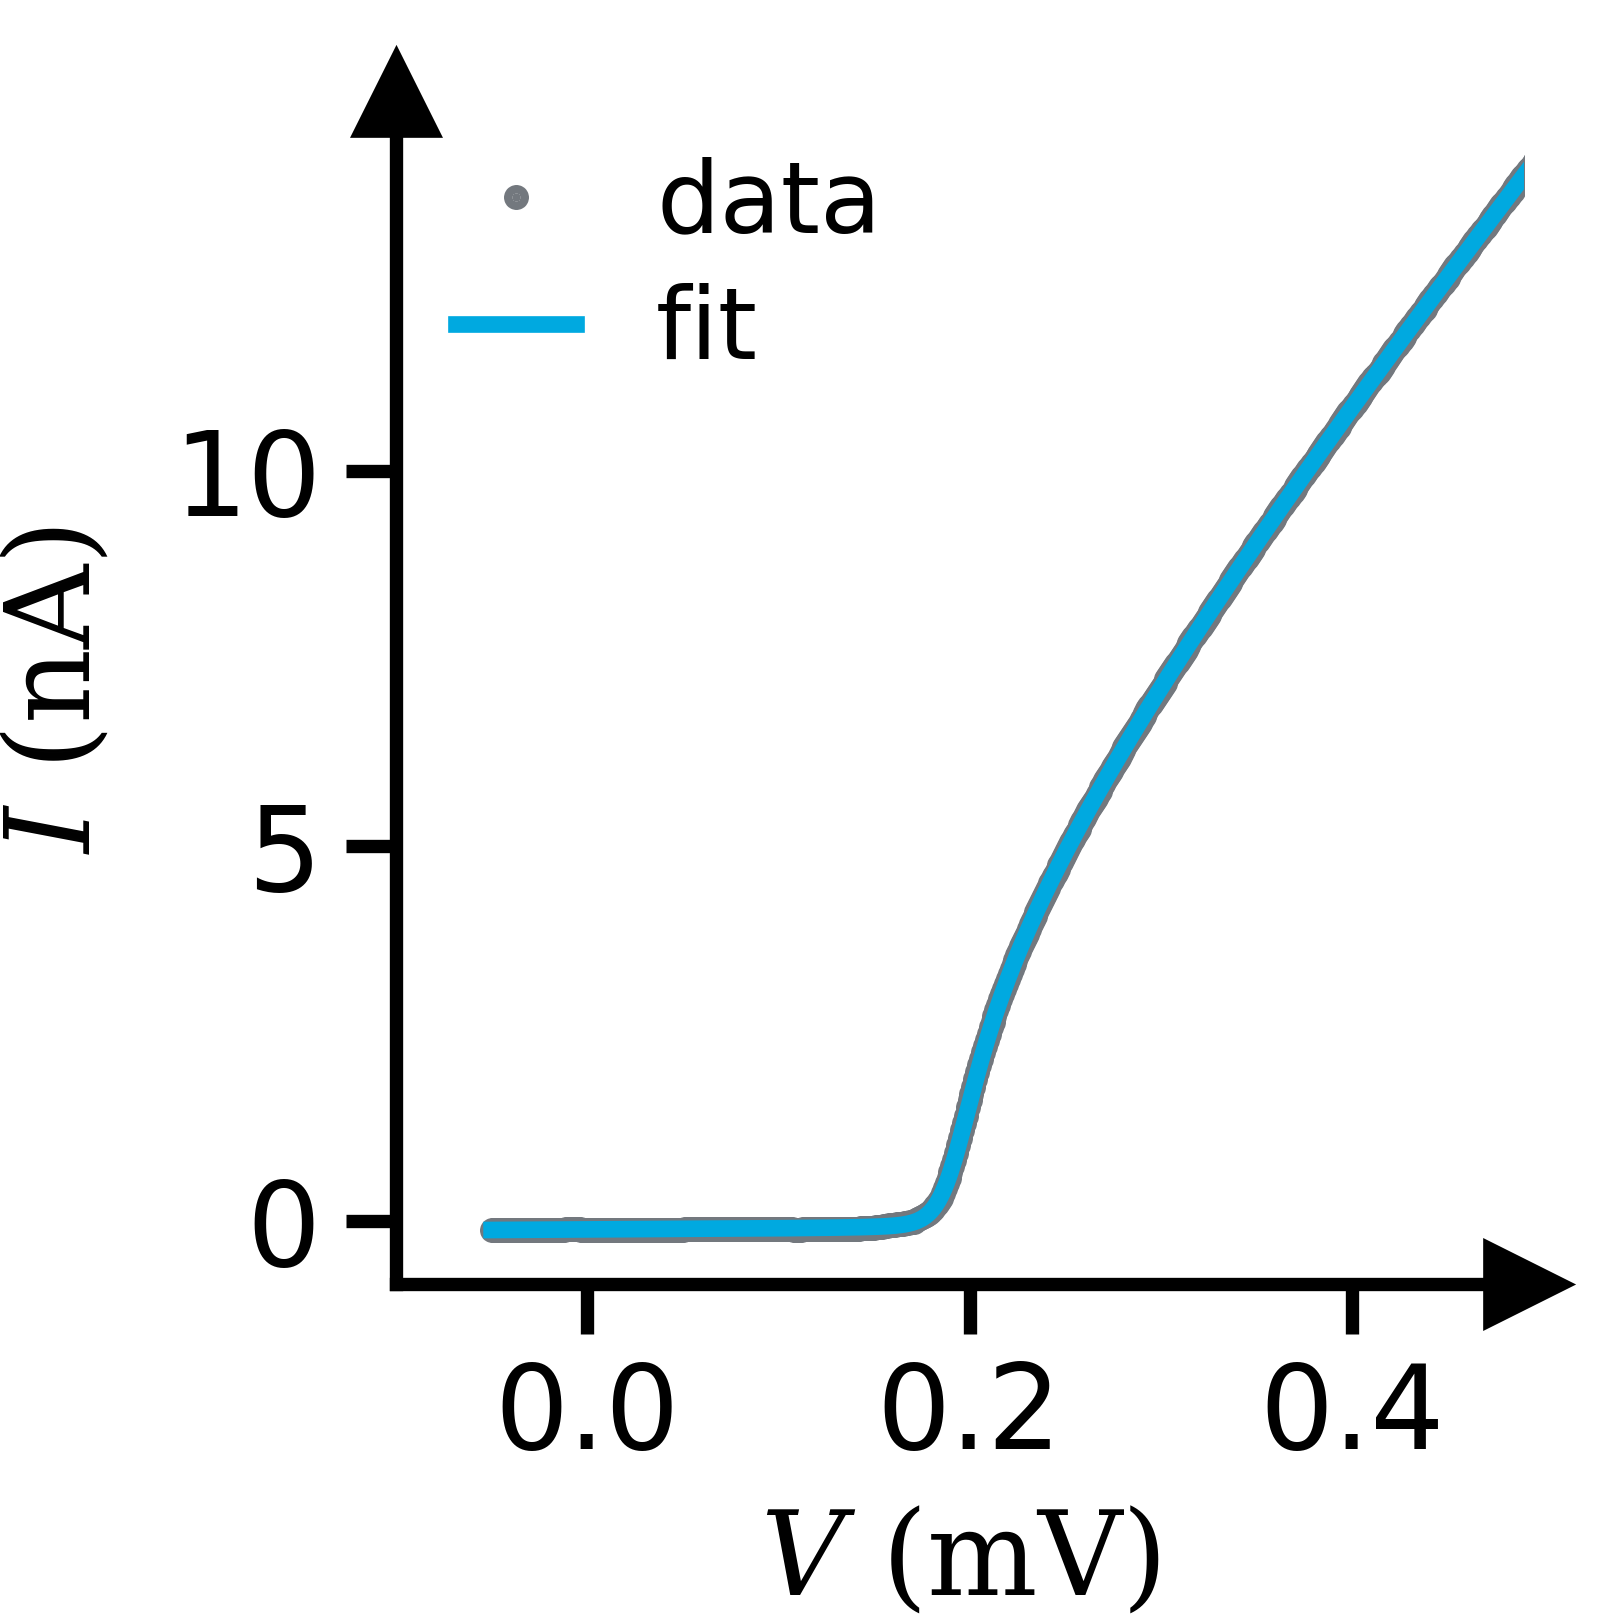

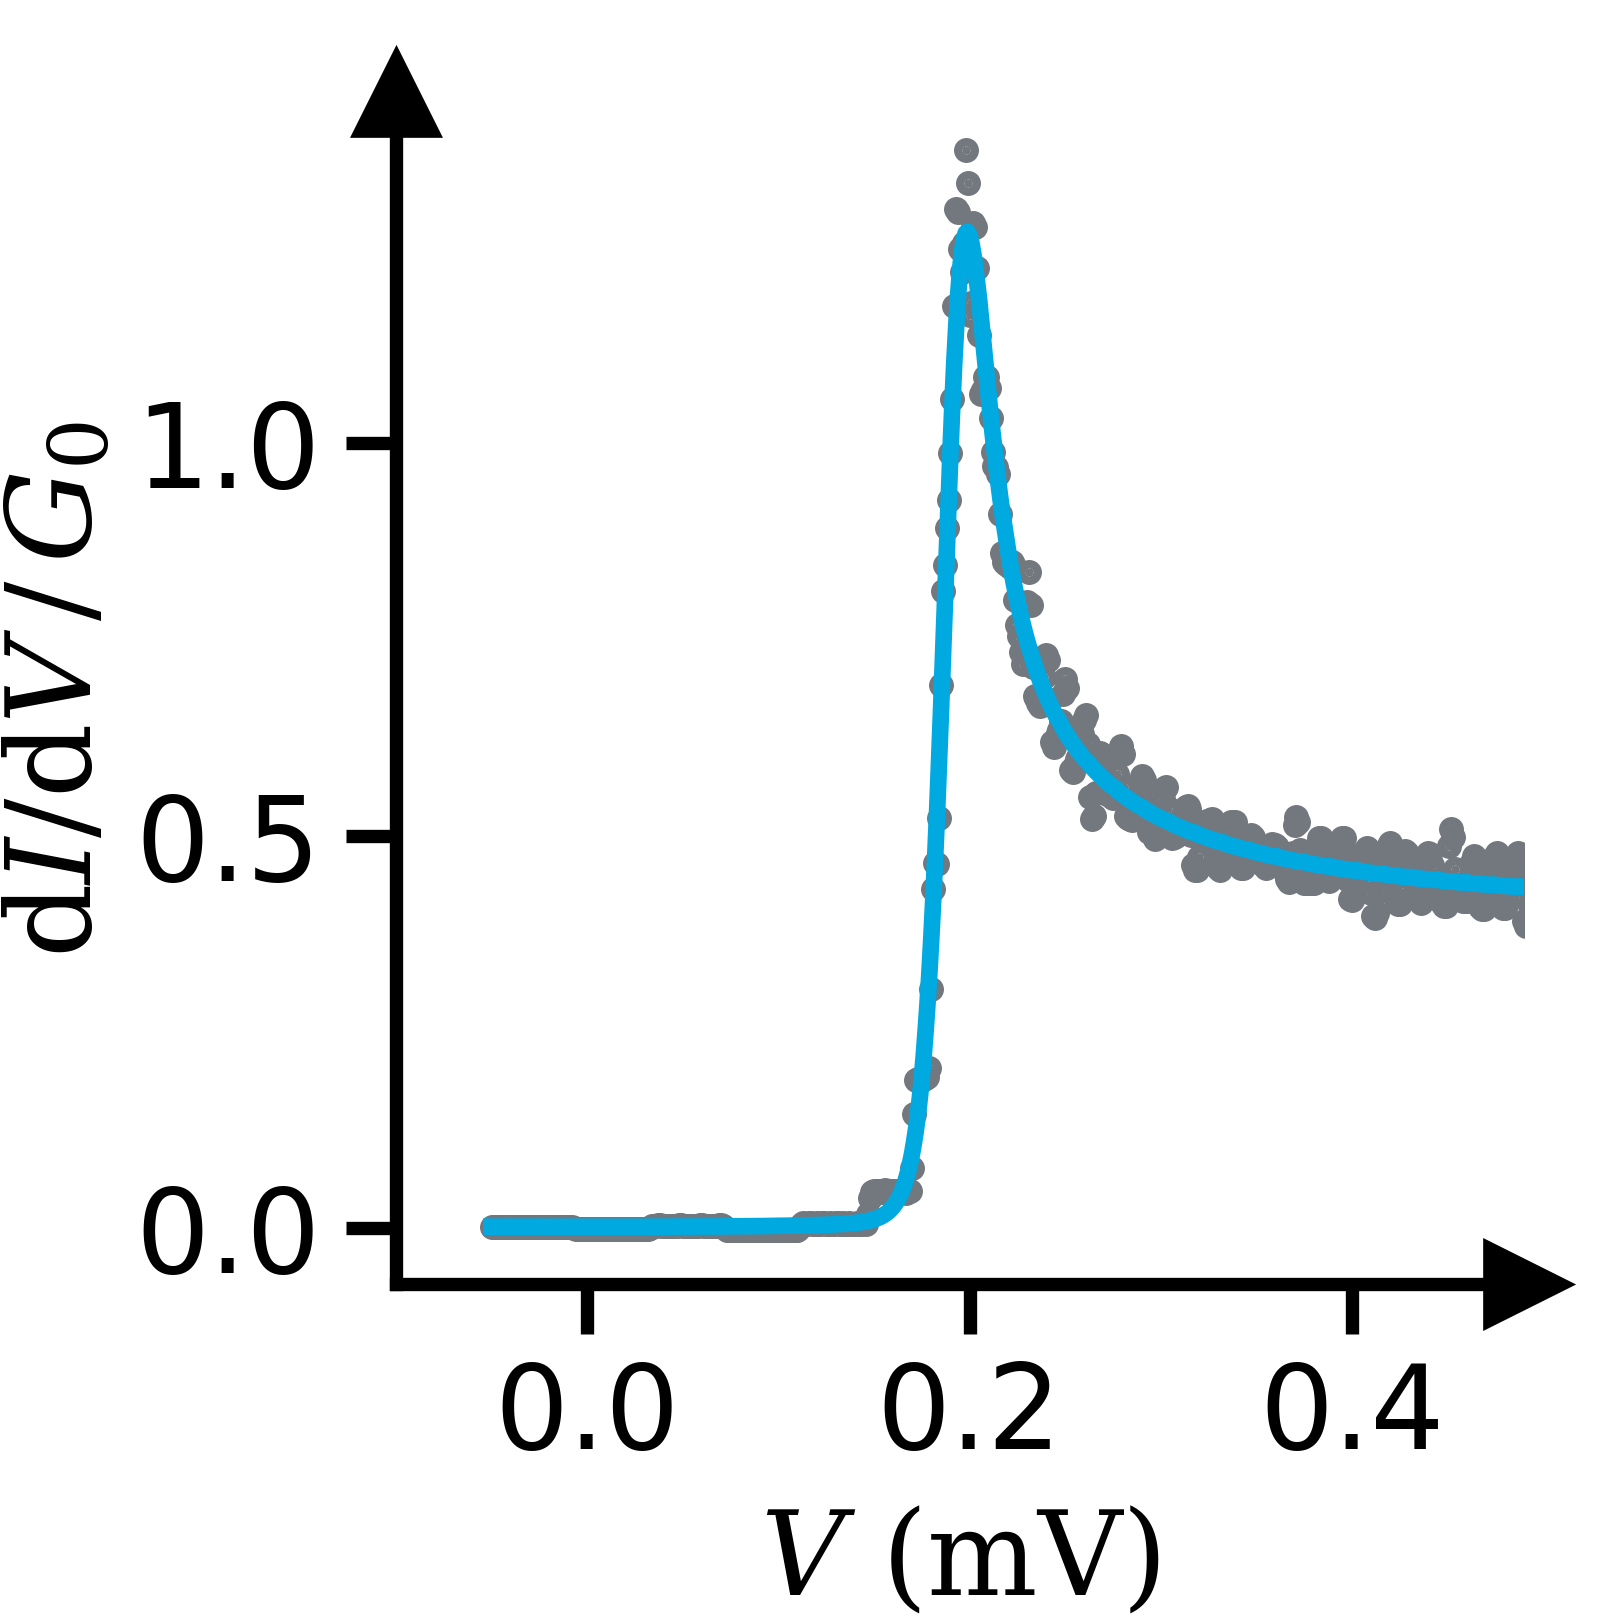

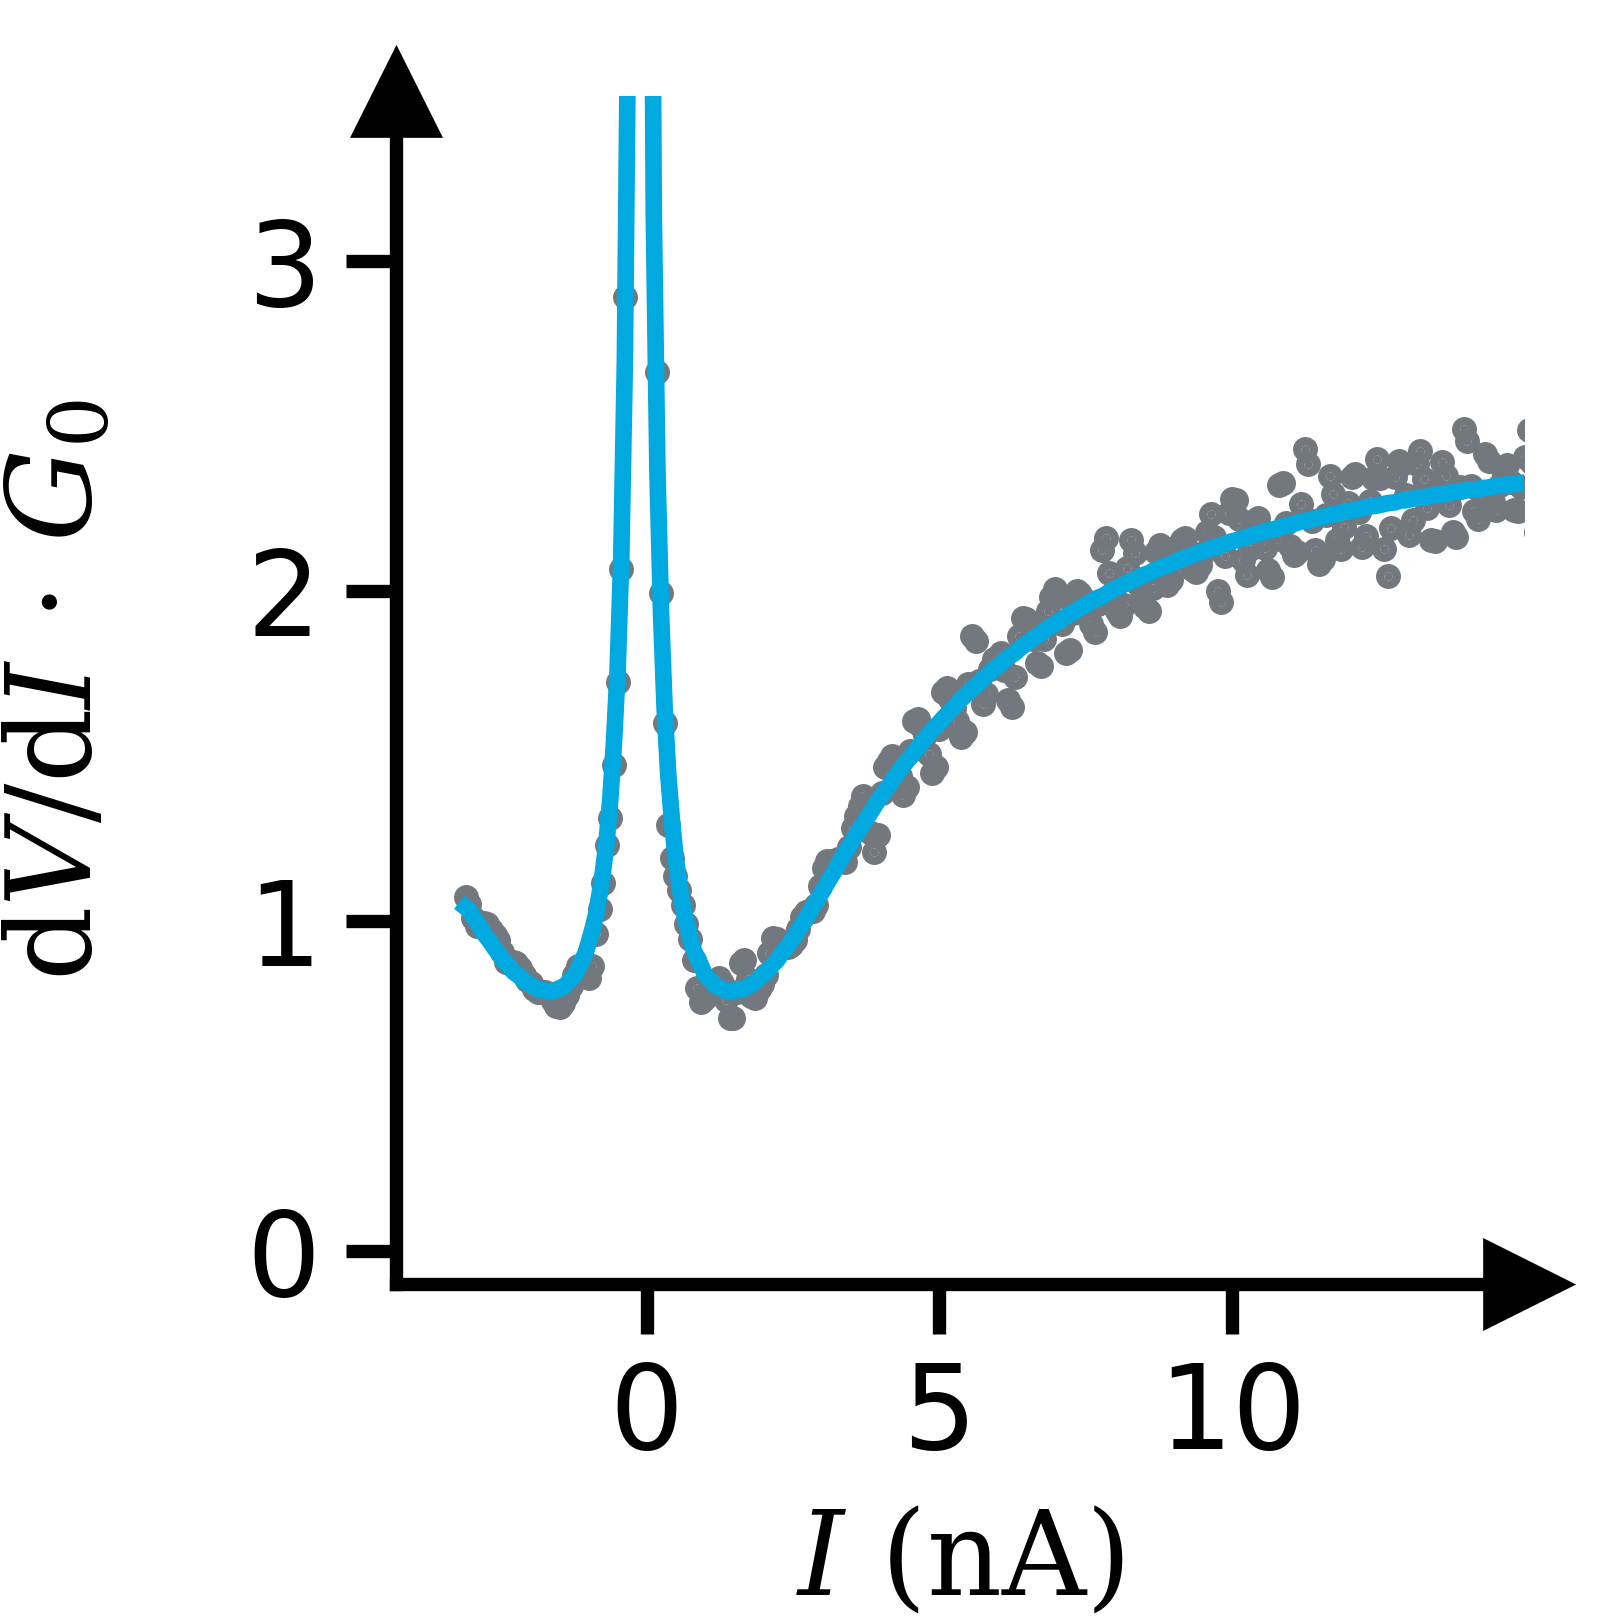

In [3]:
# plot single-iv tb

fig, ax = sc.get_figure(figsize=(1.35, 1.35), padding=(0.25, 0.2))
ax.plot(
    Vbias_mV,
    Iexp_nA,
    ".",
    color=sc.seegrau100,
    ms=1.0,
    label="data",
    zorder=-1,
)
ax.plot(
    Vbias_mV,
    Ifit_nA,
    "-",
    color=sc.seeblau100,
    label="fit",
    zorder=0,
)
# ax.set_yticks([0, 20, 40, 60])
# ax.set_ylim(None, 75)
# ax.set_xticks([0, 0.2, 0.4])
ax.set_xlim(-0.1, 0.49)
ylim = ax.get_ylim()

ax.legend(
    # title="$\\alpha_q = $",
    handlelength=1.2,
    loc="upper left",
    frameon=False,
    fontsize=6,
    title_fontsize=6,
    ncols=1,
    columnspacing=0.8,
    borderpad=0.1,  # reduces padding inside the legend box
    labelspacing=0.3,  # reduces vertical spacing between items
    handletextpad=0.8,  # reduces spacing between line and label
    # bbox_to_anchor=(1.1, 1.1),
)
sc.theory_layout(
    fig,
    ax,
    f"ssn-set/ssn1-sin/iv",
    "$V\\ \\mathrm{(mV)}$",
    "$I\\ \\mathrm{(nA)}$",
)
plt.show()

fig, ax = sc.get_figure(figsize=(1.35, 1.35), padding=(0.25, 0.2))
ax.plot(Vbias_mV, dGexp_G0, ".", color=sc.seegrau100, ms=1.0)
ax.plot(Vbias_mV, dGfit_G0, "-", color=sc.seeblau100)
ax.set_xticks([0, 0.2, 0.4])
ax.set_xlim(-0.1, 0.49)
sc.theory_layout(
    fig,
    ax,
    f"ssn-set/ssn1-sin/didv",
    "$V\\ \\mathrm{(mV)}$",
    "$\\mathrm{d}I/\\mathrm{d}V\\,/\\,G_0$",
)
plt.show()

fig, ax = sc.get_figure(figsize=(1.35, 1.35), padding=(0.25, 0.2))
ax.plot(
    Ibias_nA,
    dRexp_R0,
    ".",
    color=sc.seegrau100,
    ms=1.0,
)
ax.plot(Ibias_nA, dRfit_R0, "-", color=sc.seeblau100)
ax.set_ylim(-0.1, 3.5)
ax.set_xlim(None, ylim[1])
ax.set_xticks((0, 5, 10))
sc.theory_layout(
    fig,
    ax,
    f"ssn-set/ssn1-sin/dvdi",
    "$I\\ \\mathrm{(nA)}$",
    "$\\mathrm{d}V/\\mathrm{d}I\\,\\cdot\\,G_0$",
)
plt.show()

### N-SET

In [152]:
from fit_nset import fitted_orthodox_map_nA, Vgate_mV

Vbias_mV, Iexp_nA, Ifit_nA = fitted_orthodox_map_nA()

Ibias_nA = np.linspace(-10, 10, 601)
Vexp_mV = sc.bin_y_over_x(upsample(Vbias_mV), upsample(Iexp_nA), Ibias_nA, axis=-1)
Vfit_mV = sc.bin_y_over_x(upsample(Vbias_mV), upsample(Ifit_nA), Ibias_nA, axis=-1)

dGexp_G0 = np.gradient(Iexp_nA, Vbias_mV, axis=-1) / sc.G0_muS
dRexp_R0 = np.gradient(Vexp_mV, Ibias_nA, axis=-1) * sc.G0_muS
dGfit_G0 = np.gradient(Ifit_nA, Vbias_mV, axis=-1) / sc.G0_muS
dRfit_R0 = np.gradient(Vfit_mV, Ibias_nA, axis=-1) * sc.G0_muS

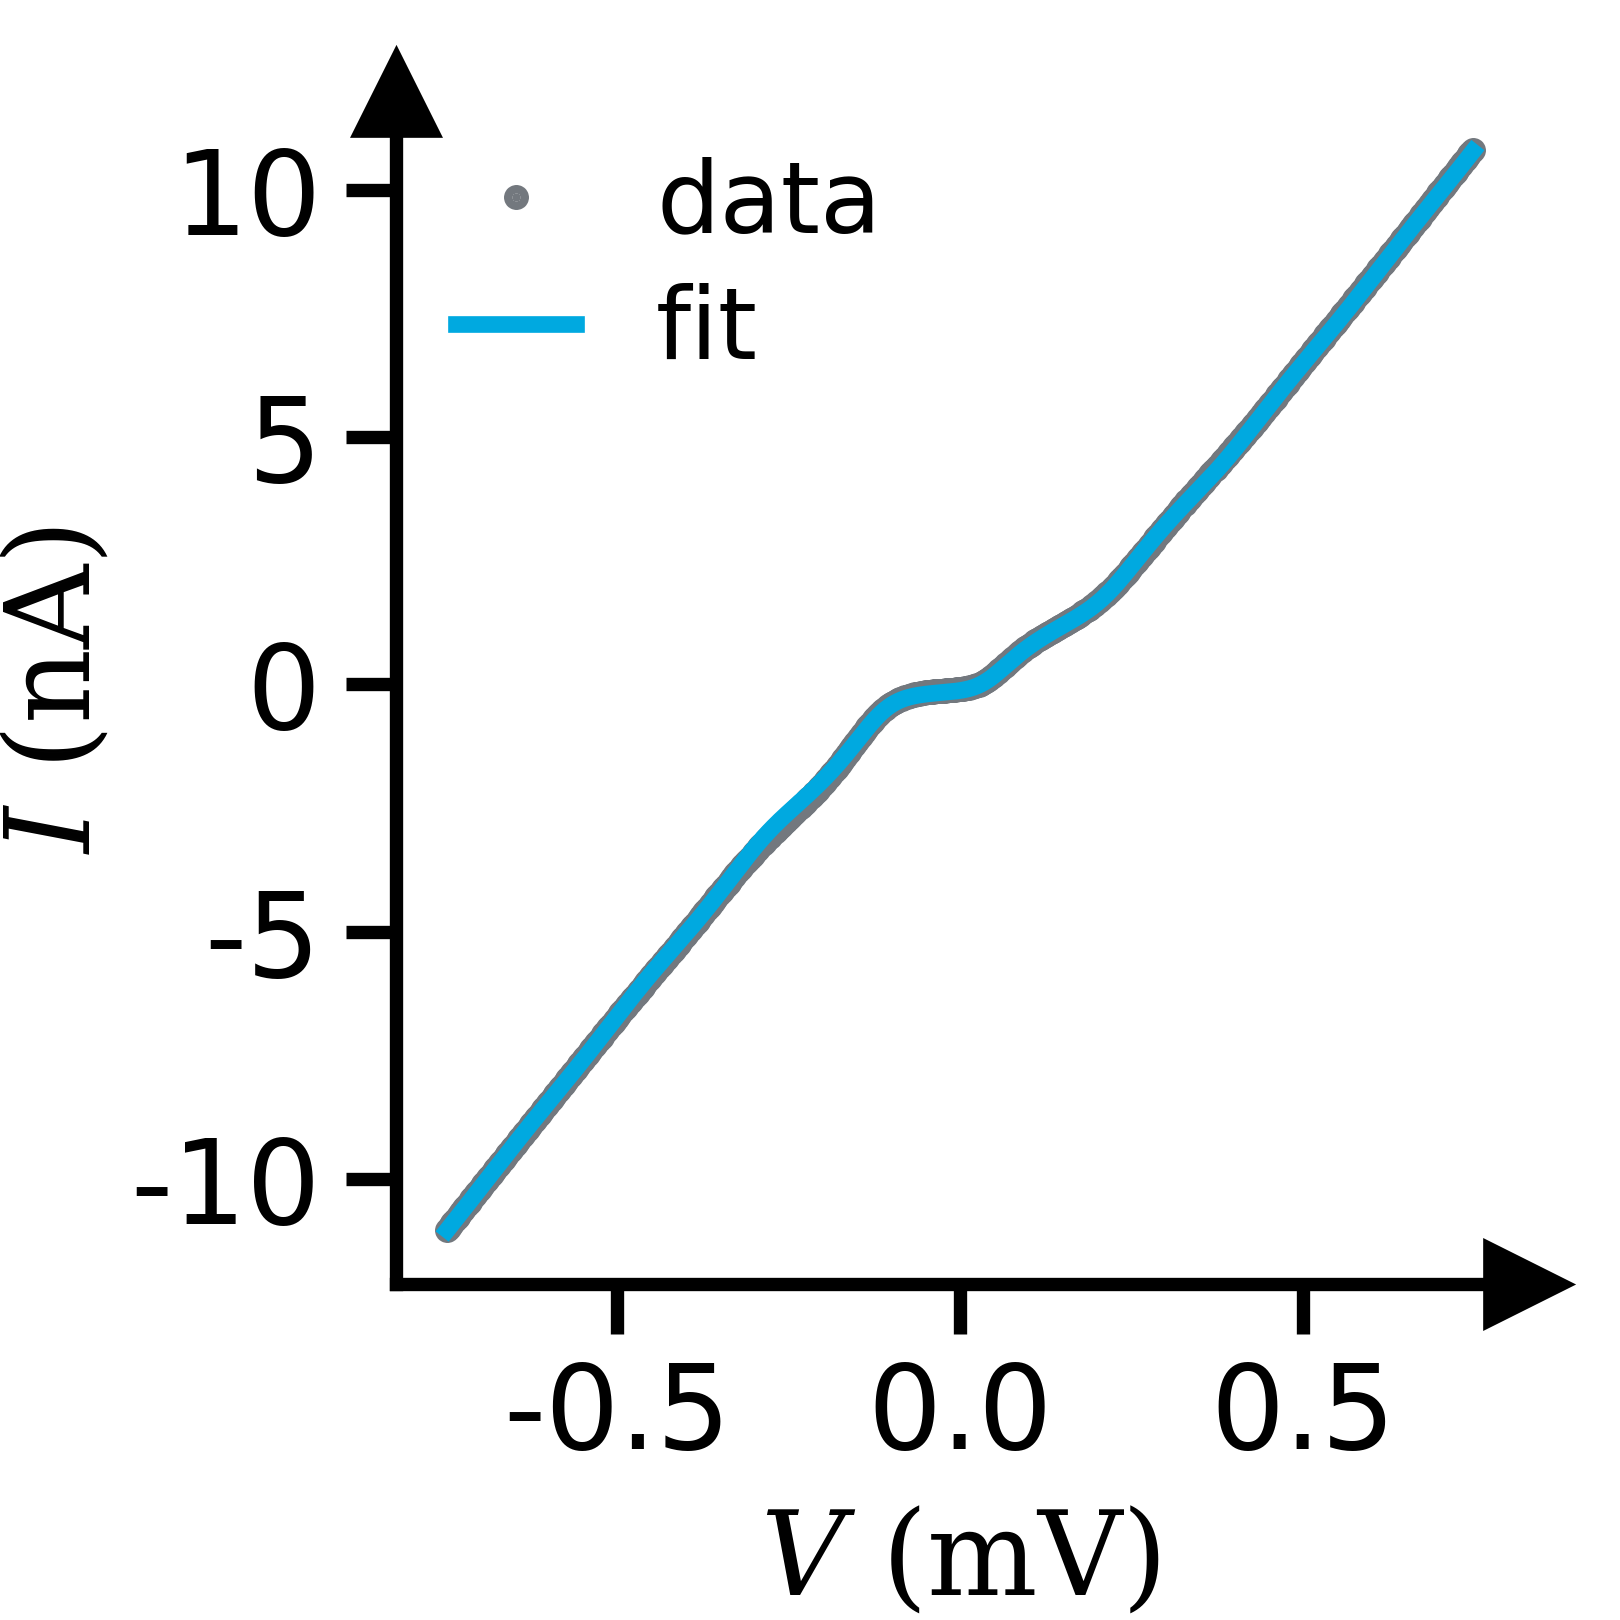

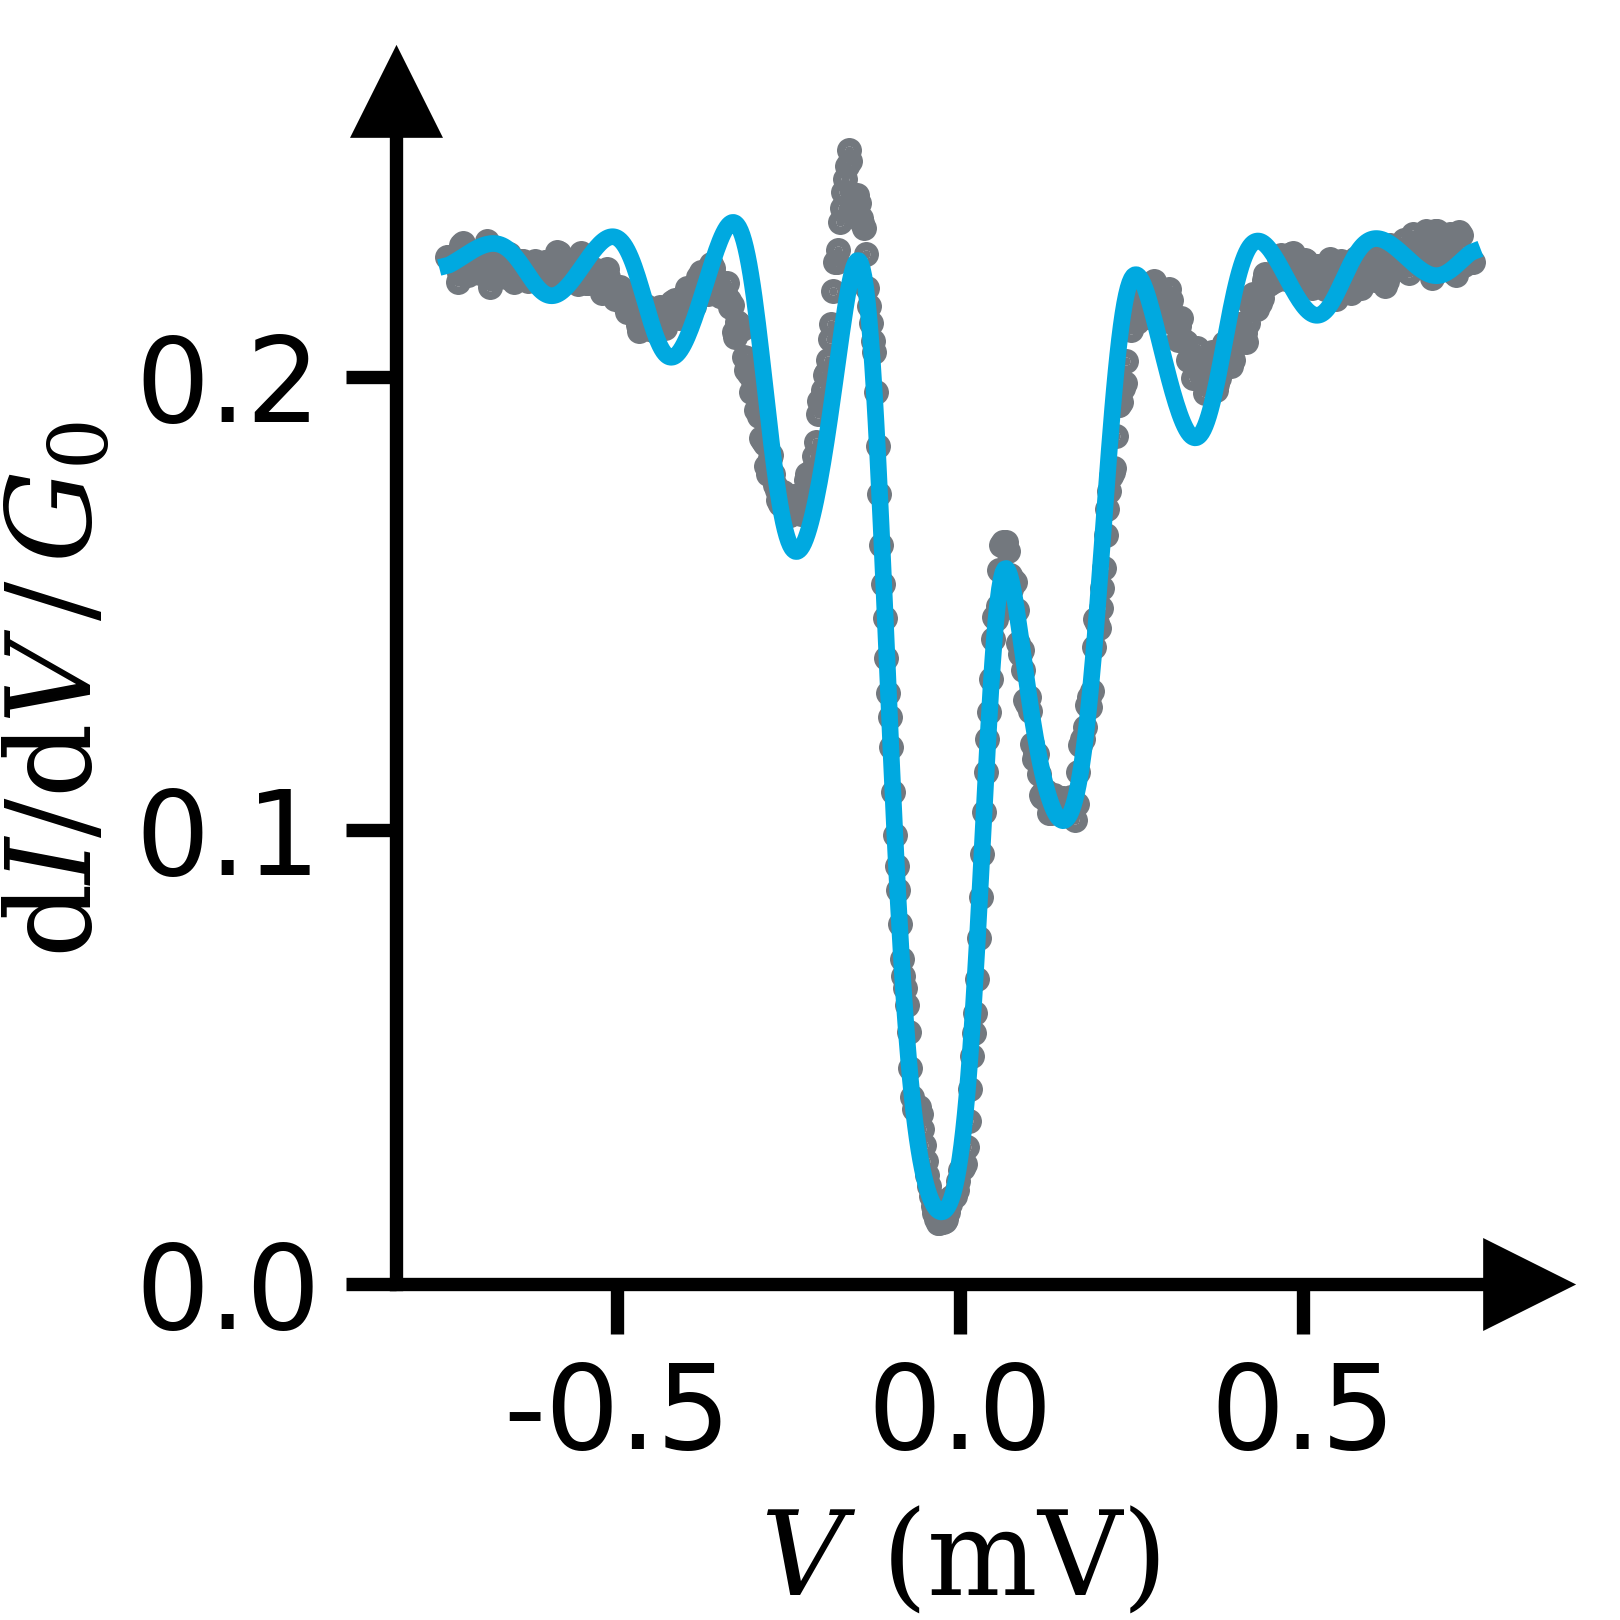

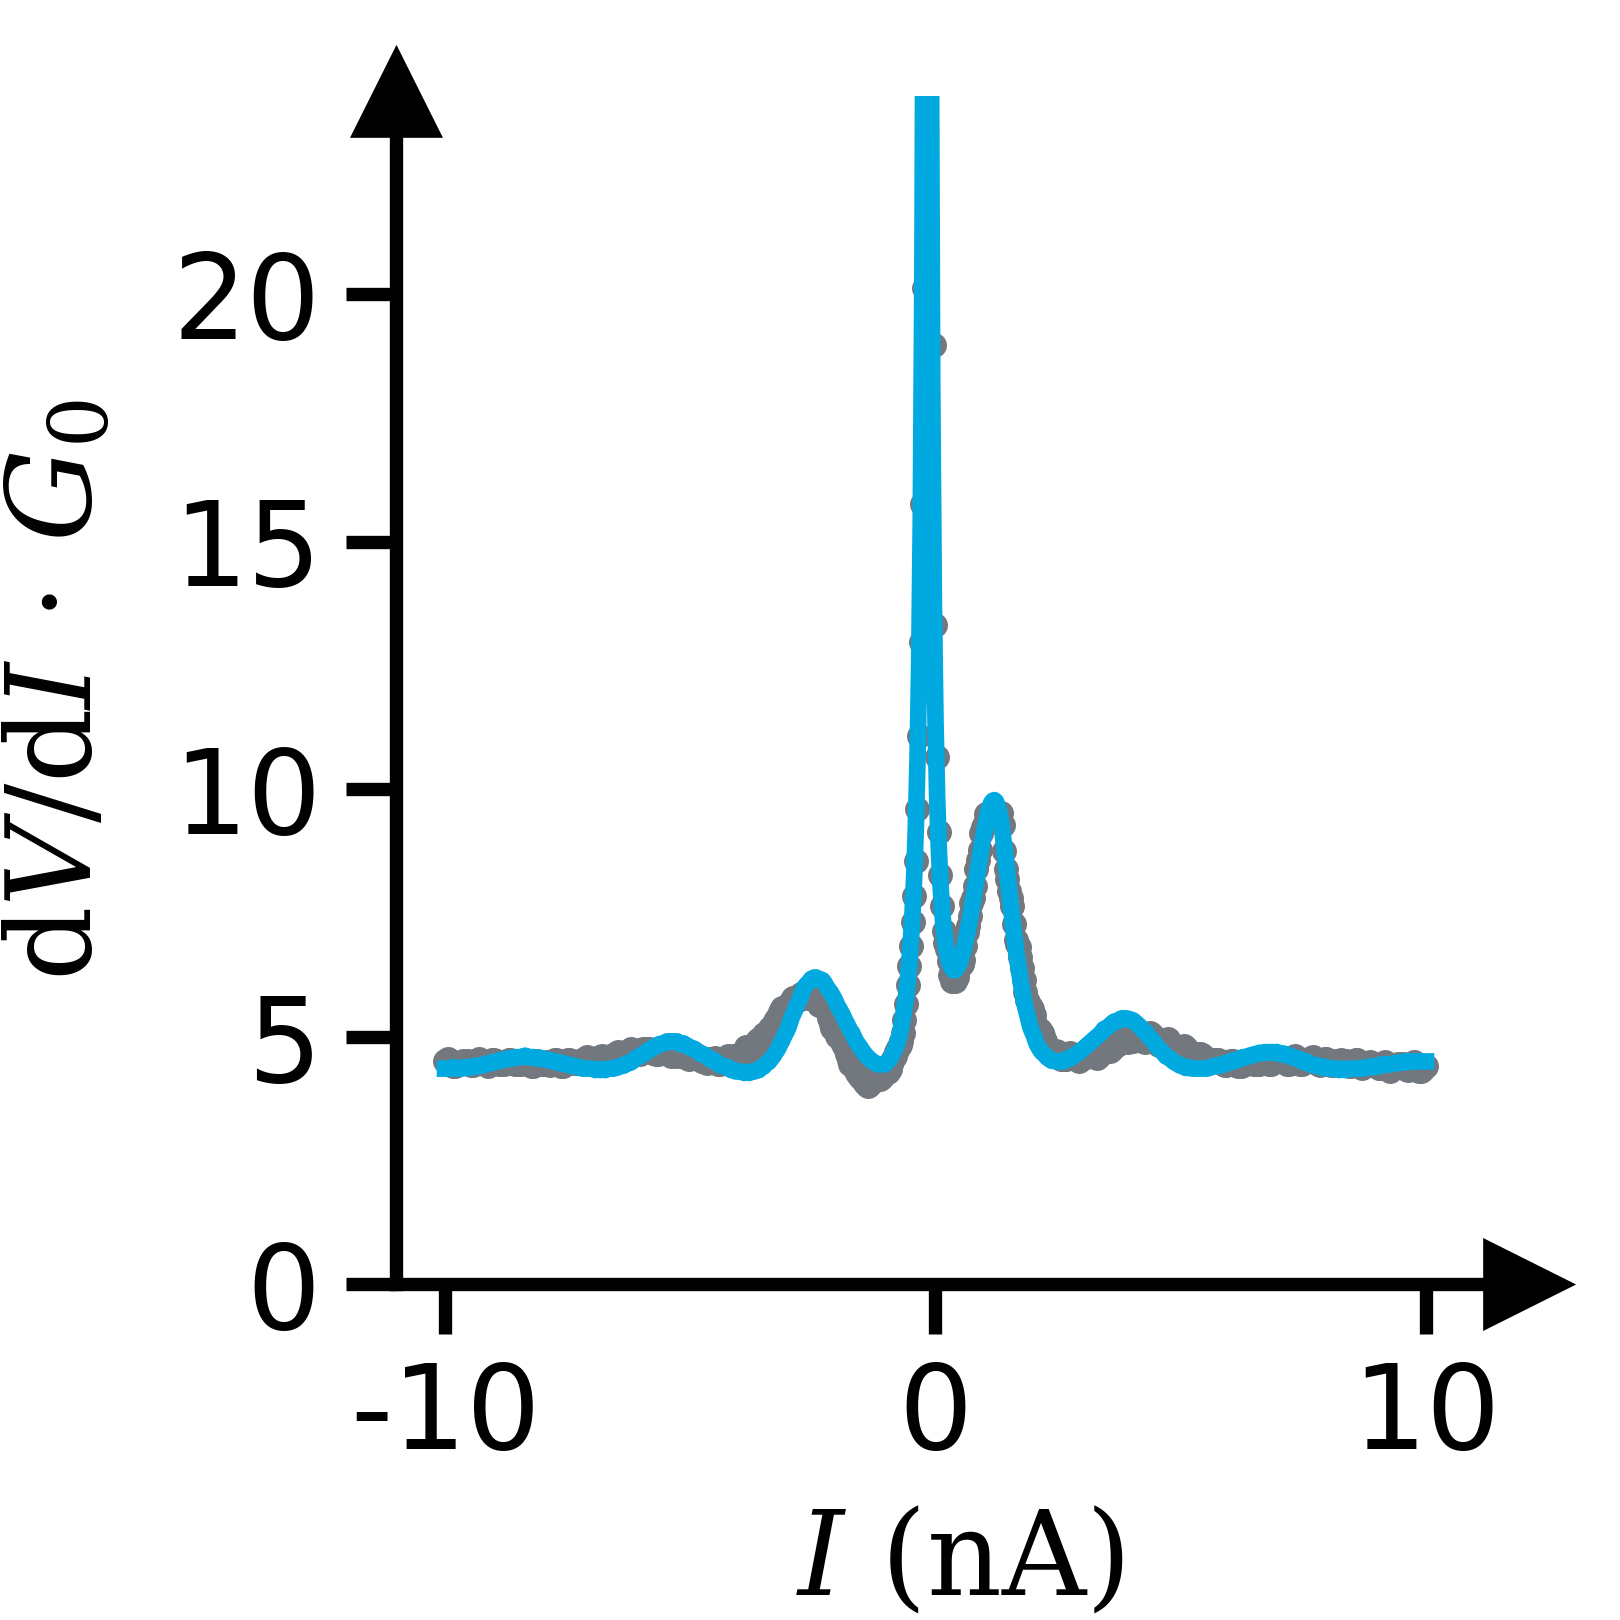

In [158]:
# plot single-iv tb
index = np.argmin(np.abs(Vgate_mV))
base = "ssn1-nset-iv0"

fig, ax = sc.get_figure(figsize=(1.35, 1.35), padding=(0.25, 0.2))
ax.plot(
    Vbias_mV,
    Iexp_nA[index, :],
    ".",
    color=sc.seegrau100,
    ms=1.0,
    label="data",
    zorder=-1,
)
ax.plot(
    Vbias_mV,
    Ifit_nA[index, :],
    "-",
    color=sc.seeblau100,
    label="fit",
    zorder=0,
)
# ax.set_yticks([0, 20, 40, 60])
# ax.set_ylim(None, 75)
# ax.set_xticks([0, 0.2, 0.4, 0.6])
# ax.set_xlim(None, 0.7)

ax.legend(
    # title="$\\alpha_q = $",
    handlelength=1.2,
    loc="upper left",
    frameon=False,
    fontsize=6,
    title_fontsize=6,
    ncols=1,
    columnspacing=0.8,
    borderpad=0.1,  # reduces padding inside the legend box
    labelspacing=0.3,  # reduces vertical spacing between items
    handletextpad=0.8,  # reduces spacing between line and label
    # bbox_to_anchor=(1.1, 1.1),
)
sc.theory_layout(
    fig,
    ax,
    f"ssn-set/{base}/iv",
    "$V\\ \\mathrm{(mV)}$",
    "$I\\ \\mathrm{(nA)}$",
)
plt.show()

fig, ax = sc.get_figure(figsize=(1.35, 1.35), padding=(0.25, 0.2))
ax.plot(Vbias_mV, dGexp_G0[index, :], ".", color=sc.seegrau100, ms=1.0)
ax.plot(Vbias_mV, dGfit_G0[index, :], "-", color=sc.seeblau100)
# ax.set_xticks([0, 0.2, 0.4, 0.6])
# ax.set_xlim(None, 0.7)
ax.set_ylim(0, None)
sc.theory_layout(
    fig,
    ax,
    f"ssn-set/{base}/didv",
    "$V\\ \\mathrm{(mV)}$",
    "$\\mathrm{d}I/\\mathrm{d}V\\,/\\,G_0$",
)
plt.show()

fig, ax = sc.get_figure(figsize=(1.35, 1.35), padding=(0.25, 0.2))
ax.plot(
    Ibias_nA,
    dRexp_R0[index, :],
    ".",
    color=sc.seegrau100,
    ms=1.0,
)
ax.plot(Ibias_nA, dRfit_R0[index, :], "-", color=sc.seeblau100)
ax.set_xlim(-11, 12)
ax.set_ylim(0, 24)
# ax.set_xticks([0, 5, 10, 15])
sc.theory_layout(
    fig,
    ax,
    f"ssn-set/{base}/dvdi",
    "$I\\ \\mathrm{(nA)}$",
    "$\\mathrm{d}V/\\mathrm{d}I\\,\\cdot\\,G_0$",
)
plt.show()

In [149]:
Ctotal_fF = 1.2083
Cgate_fF = 0.03732
nG0 = 0.2130
e_per_fF_mV = 6.241509
Ec_meV = 0.0801088 / Ctotal_fF
dVgate = Vgate_mV * Cgate_fF * e_per_fF_mV

GN_G0 = 0.2283

Vbias = Vbias_mV / Ec_meV
Vgate = dVgate - nG0
dGexp = dGexp_G0 / GN_G0
dRexp = dRexp_R0 * GN_G0
dGfit = dGfit_G0 / GN_G0
dRfit = dRfit_R0 * GN_G0

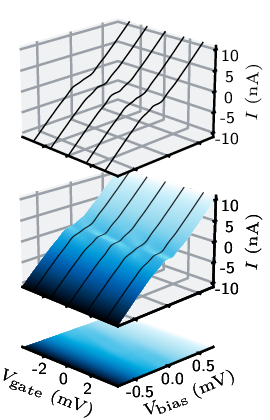

/Users/oliver/Documents/cryolab/dissertation-figures/ssn-set/ssn1-set/exp_iv/main.png

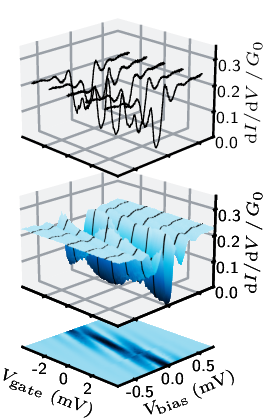

/Users/oliver/Documents/cryolab/dissertation-figures/ssn-set/ssn1-set/exp_didv/main.png

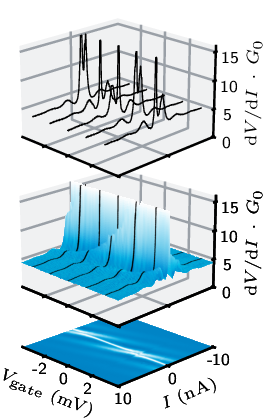

/Users/oliver/Documents/cryolab/dissertation-figures/ssn-set/ssn1-set/exp_dvdi/main.png

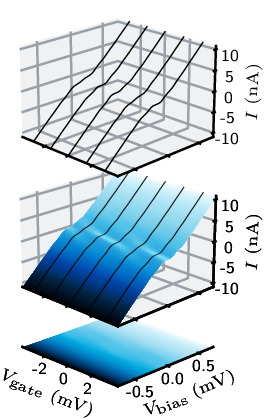

/Users/oliver/Documents/cryolab/dissertation-figures/ssn-set/ssn1-set/fit_iv/main.png

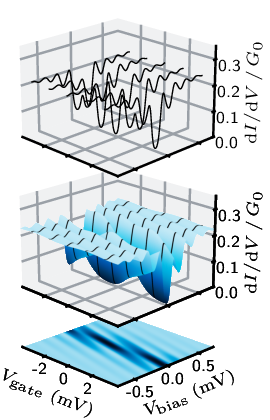

/Users/oliver/Documents/cryolab/dissertation-figures/ssn-set/ssn1-set/fit_didv/main.png

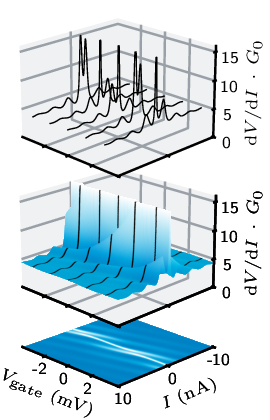

/Users/oliver/Documents/cryolab/dissertation-figures/ssn-set/ssn1-set/fit_dvdi/main.png

In [150]:
# ssn-set

from superconductivity.visuals.landscape import export_landscape_thesis

exports = export_landscape_thesis(
    Vbias=Vbias_mV,
    Abias=Vgate_mV,
    Ibias=Ibias_nA,
    Iexp=Iexp_nA,
    dGexp=dGexp_G0,
    dRexp=dRexp_R0,
    waterfall_traces=[-3, -1.5, 0, 1.5, 3],
    name="exp",
    sub_dir=f"ssn-set/ssn1-set/",
    surface_points=(300, 100),
    Vlabel="$V_\\mathrm{bias}\\ (\\mathrm{mV})$",
    Ilabel="$I\\ (\\mathrm{nA})$",
    Alabel="$V_\\mathrm{gate}\\ (\\mathrm{mV})$",
    dRlabel="$\\mathrm{d}V/\\mathrm{d}I\\,\\cdot\\,G_0$",
    dGlabel="$\\mathrm{d}I/\\mathrm{d}V\\,/\\,G_0$",
    Abiasticks=(-2, 0, 2),
    dRlim=(0, 16),
    dGlim=(0, 0.35),
)
exports = export_landscape_thesis(
    Vbias=Vbias_mV,
    Abias=Vgate_mV,
    Ibias=Ibias_nA,
    Iexp=Ifit_nA,
    dGexp=dGfit_G0,
    dRexp=dRfit_R0,
    waterfall_traces=[-3, -1.5, 0, 1.5, 3],
    name="fit",
    sub_dir=f"ssn-set/ssn1-set/",
    surface_points=(300, 100),
    Vlabel="$V_\\mathrm{bias}\\ (\\mathrm{mV})$",
    Ilabel="$I\\ (\\mathrm{nA})$",
    Alabel="$V_\\mathrm{gate}\\ (\\mathrm{mV})$",
    dRlabel="$\\mathrm{d}V/\\mathrm{d}I\\,\\cdot\\,G_0$",
    dGlabel="$\\mathrm{d}I/\\mathrm{d}V\\,/\\,G_0$",
    Abiasticks=(-2, 0, 2),
    dRlim=(0, 16),
    dGlim=(0, 0.35),
)

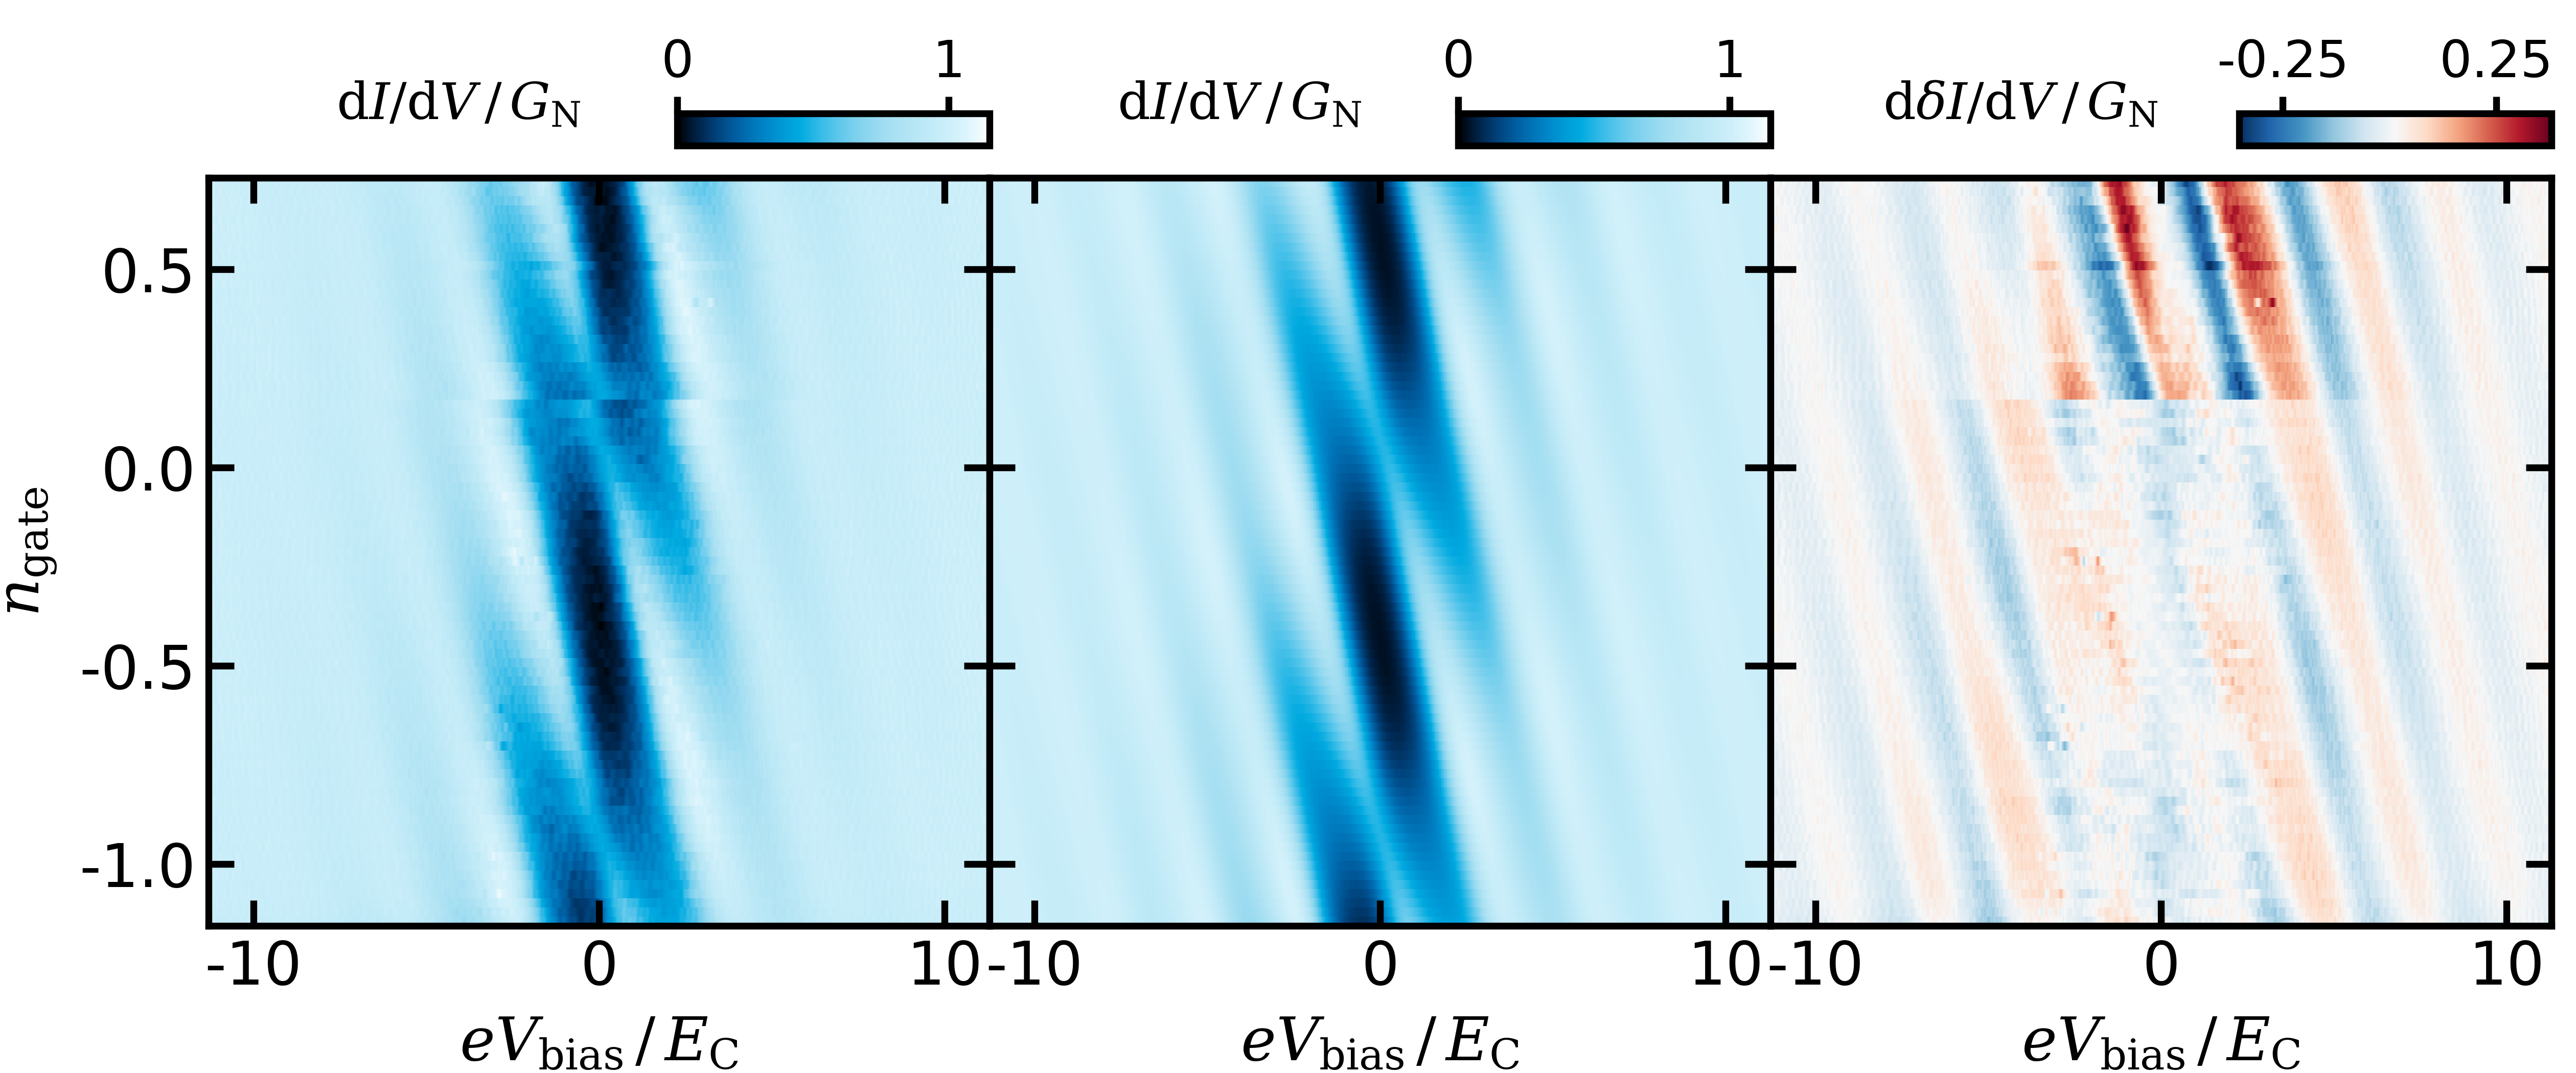

In [151]:
# region dIdV difference
fig, axes = sc.get_figures(
    figsize=(4.2, 1.75), padding=(0.3, 0.2, 0.0, 0.25), nrows=1, ncols=3
)

img0 = axes[0].pcolormesh(
    Vbias,
    Vgate,
    dGexp,
    # cmap="RdBu_r",
    cmap=sc.get_cmap(),
    clim=(0, 1.15),
    rasterized=True,
)
img1 = axes[1].pcolormesh(
    Vbias,
    Vgate,
    dGfit,
    # cmap="RdBu_r",
    cmap=sc.get_cmap(),
    clim=(0, 1.15),
    rasterized=True,
)
img2 = axes[2].pcolormesh(
    Vbias,
    Vgate,
    dGexp - dGfit,
    cmap="RdBu_r",
    # cmap=sc.get_cmap(inverse=True),
    # clim=(-0.06, 0.06),
    rasterized=True,
)
# for i, ax in enumerate(axes):
#     ax.set_ylim(np.min(Vgate_mV), np.max(Vgate_mV))
#     ax.set_xlim(-4, 4)

sc.daumenkino_layout(
    fig,
    axes,
    ylabel=r"$n_\mathrm{gate}$",
    xlabel=r"$eV_\mathrm{bias}\,/\,E_\mathrm{C}$",
    # yticks=[-3, 0, 3],
)

imgs = [img0, img1, img2]
caxs = []
cbars = []
clabels = [
    "$\\mathrm{d}I/\\mathrm{d}V\\,/\\,G_\\mathrm{N}$",
    "$\\mathrm{d}I/\\mathrm{d}V\\,/\\,G_\\mathrm{N}$",
    "$\\mathrm{d}\\delta I/\\mathrm{d}V\\,/\\,G_\\mathrm{N}$",
]
cticks = [None, None, (-0.25, 0.25)]
for i, ax in enumerate(axes):
    upper_edge = ax.get_position().y1
    left = ax.get_position().x0
    right = ax.get_position().x1

    width = right - left
    shrink = 0.4
    new_width = width * shrink
    new_left = left + 0.5 * (width - new_width)
    new_left = left + (width - new_width)

    cax = fig.add_axes([new_left, upper_edge + 0.03, new_width, 0.03])
    cax.text(
        -0.7,
        0.5,
        clabels[i],
        transform=cax.transAxes,
        ha="center",
        va="bottom",
        size=6,
    )
    caxs.append(cax)

    cbar = fig.colorbar(
        imgs[i],
        cax=cax,
        orientation="horizontal",
        ticks=cticks[i],
    )
    cbar.ax.tick_params(
        labelsize=6,
        length=2,
        labelrotation=0,
        top=True,
        bottom=False,
        labeltop=True,
        labelbottom=False,
        pad=1,
    )
    cbars.append(cbar)

save_figure(fig, title=f"ssn-set/ssn1-nset/dGdiff")
# # endregion

### SSN-SET

In [159]:
# get data single-iv ssn set

file = "/Users/oliver/Documents/measurement data/SSET/22 02b Scheer2/65_6/SCMap.tdms"
# file = "/Users/oliver/Documents/measurement data/SSET/22 02b Scheer2/65_6/NCMap.tdms"
# file = "/Users/oliver/Documents/measurement data/SSET/22 03 Scheer2/36/SC_map.tdms"

nu_downsample_Hz = 137
sweep_up = (75_000, 125_000)
sweep_down = (24000, 70000)

keys = []
values = []

with TdmsFile.open(file) as f:
    mkeys = f.groups()
    for mkey in mkeys:
        name = mkey.name
        if name not in ["ZeroOffsetAdjust", "Thermometry", "Mapped"]:
            keys.append(name)
            value = name.split("G")[1].split("V")[0]
            if value[-1] == "m":
                value = float(value[:-1]) * 1e-3
            elif value[-1] == "u":
                value = float(value[:-1]) * 1e-6
            else:
                value = 0
            value = np.round(value, 6)
            values.append(value)

with TdmsFile.open(file) as f:
    amp = (
        f.properties["s_ampl_sample_effective_gain"],
        f.properties["s_ampl_reference_effective_gain"],
    )
    rref = f.properties["s_ampl_resistor"]
    nu_source_Hz = f.properties["s_source_f"]
    dt_sample_s = f[keys[0]].properties["s_dt"]
    nu_sample_Hz = 1 / dt_sample_s

Sample_up_V = []
Reference_up_V = []
Sample_down_V = []
Reference_down_V = []

dt_downsample_s = 1 / nu_downsample_Hz

with TdmsFile.open(file) as f:
    for i, key in enumerate(tqdm(keys)):
        if True:
            sample_V = f[key]["Sample"].as_dataframe()
            reference_V = f[key]["Reference"].as_dataframe()
            sample_V = sample_V.values
            reference_V = reference_V.values / 2
            sweep = sweep_up
            sample_V = sample_V[sweep[0] : sweep[1], 0]
            reference_V = reference_V[sweep[0] : sweep[1], 0]
            time_s = np.arange(len(sample_V)) * dt_sample_s
            nu_time_s = np.arange(0, np.max(time_s), dt_downsample_s)
            nu_sample_V = sc.bin_y_over_x((sample_V), (time_s), nu_time_s)
            nu_reference_V = sc.bin_y_over_x((reference_V), (time_s), nu_time_s)

            Sample_up_V.append(nu_sample_V)
            Reference_up_V.append(nu_reference_V)

            sample_V = f[key]["Sample"].as_dataframe()
            reference_V = f[key]["Reference"].as_dataframe()
            sample_V = sample_V.values
            reference_V = reference_V.values / 2

            sweep = sweep_down
            sample_V = sample_V[sweep[0] : sweep[1], 0]
            reference_V = reference_V[sweep[0] : sweep[1], 0]
            time_s = np.arange(len(sample_V)) * dt_sample_s
            nu_time_s = np.arange(0, np.max(time_s), dt_downsample_s)
            nu_sample_V = sc.bin_y_over_x((sample_V), (time_s), nu_time_s)
            nu_reference_V = sc.bin_y_over_x((reference_V), (time_s), nu_time_s)

            Sample_down_V.append(nu_sample_V)
            Reference_down_V.append(nu_reference_V)

Vbias_mV = np.linspace(-1.2, 1.2, 601)
Ibias_nA = np.linspace(-18, 18, 601)
Vgate_mV = -np.array(values, dtype=np.float64) * 1e3

Iup_nA = np.zeros((Vgate_mV.shape[0], Vbias_mV.shape[0]))
Vup_mV = np.zeros((Vgate_mV.shape[0], Ibias_nA.shape[0]))
Idown_nA = np.zeros((Vgate_mV.shape[0], Vbias_mV.shape[0]))
Vdown_mV = np.zeros((Vgate_mV.shape[0], Ibias_nA.shape[0]))

for i, key in enumerate(tqdm(keys)):
    vup_mV = Sample_up_V[i] * 1e3 / amp[0]
    iup_nA = Reference_up_V[i] * 1e9 / (amp[1] * rref)
    vdown_mV = Sample_down_V[i] * 1e3 / amp[0]
    idown_nA = Reference_down_V[i] * 1e9 / (amp[1] * rref)

    valid = np.logical_and(np.isfinite(vup_mV), np.isfinite(iup_nA))
    iup_nA, vup_mV = upsample(iup_nA[valid]), upsample(vup_mV[valid])
    # iup_nA, vup_mV = (iup_nA[valid]), (vup_mV[valid])
    Iup_nA[i, :] = sc.bin_y_over_x(iup_nA, vup_mV, Vbias_mV)
    Vup_mV[i, :] = sc.bin_y_over_x(vup_mV, iup_nA, Ibias_nA)

    valid = np.logical_and(np.isfinite(vdown_mV), np.isfinite(idown_nA))
    idown_nA, vdown_mV = upsample(idown_nA[valid]), upsample(vdown_mV[valid])
    # idown_nA, vdown_mV = (idown_nA[valid]), (vdown_mV[valid])
    Idown_nA[i, :] = sc.bin_y_over_x(idown_nA, vdown_mV, Vbias_mV)
    Vdown_mV[i, :] = sc.bin_y_over_x(vdown_mV, idown_nA, Ibias_nA)

100%|██████████| 81/81 [00:04<00:00, 19.32it/s]


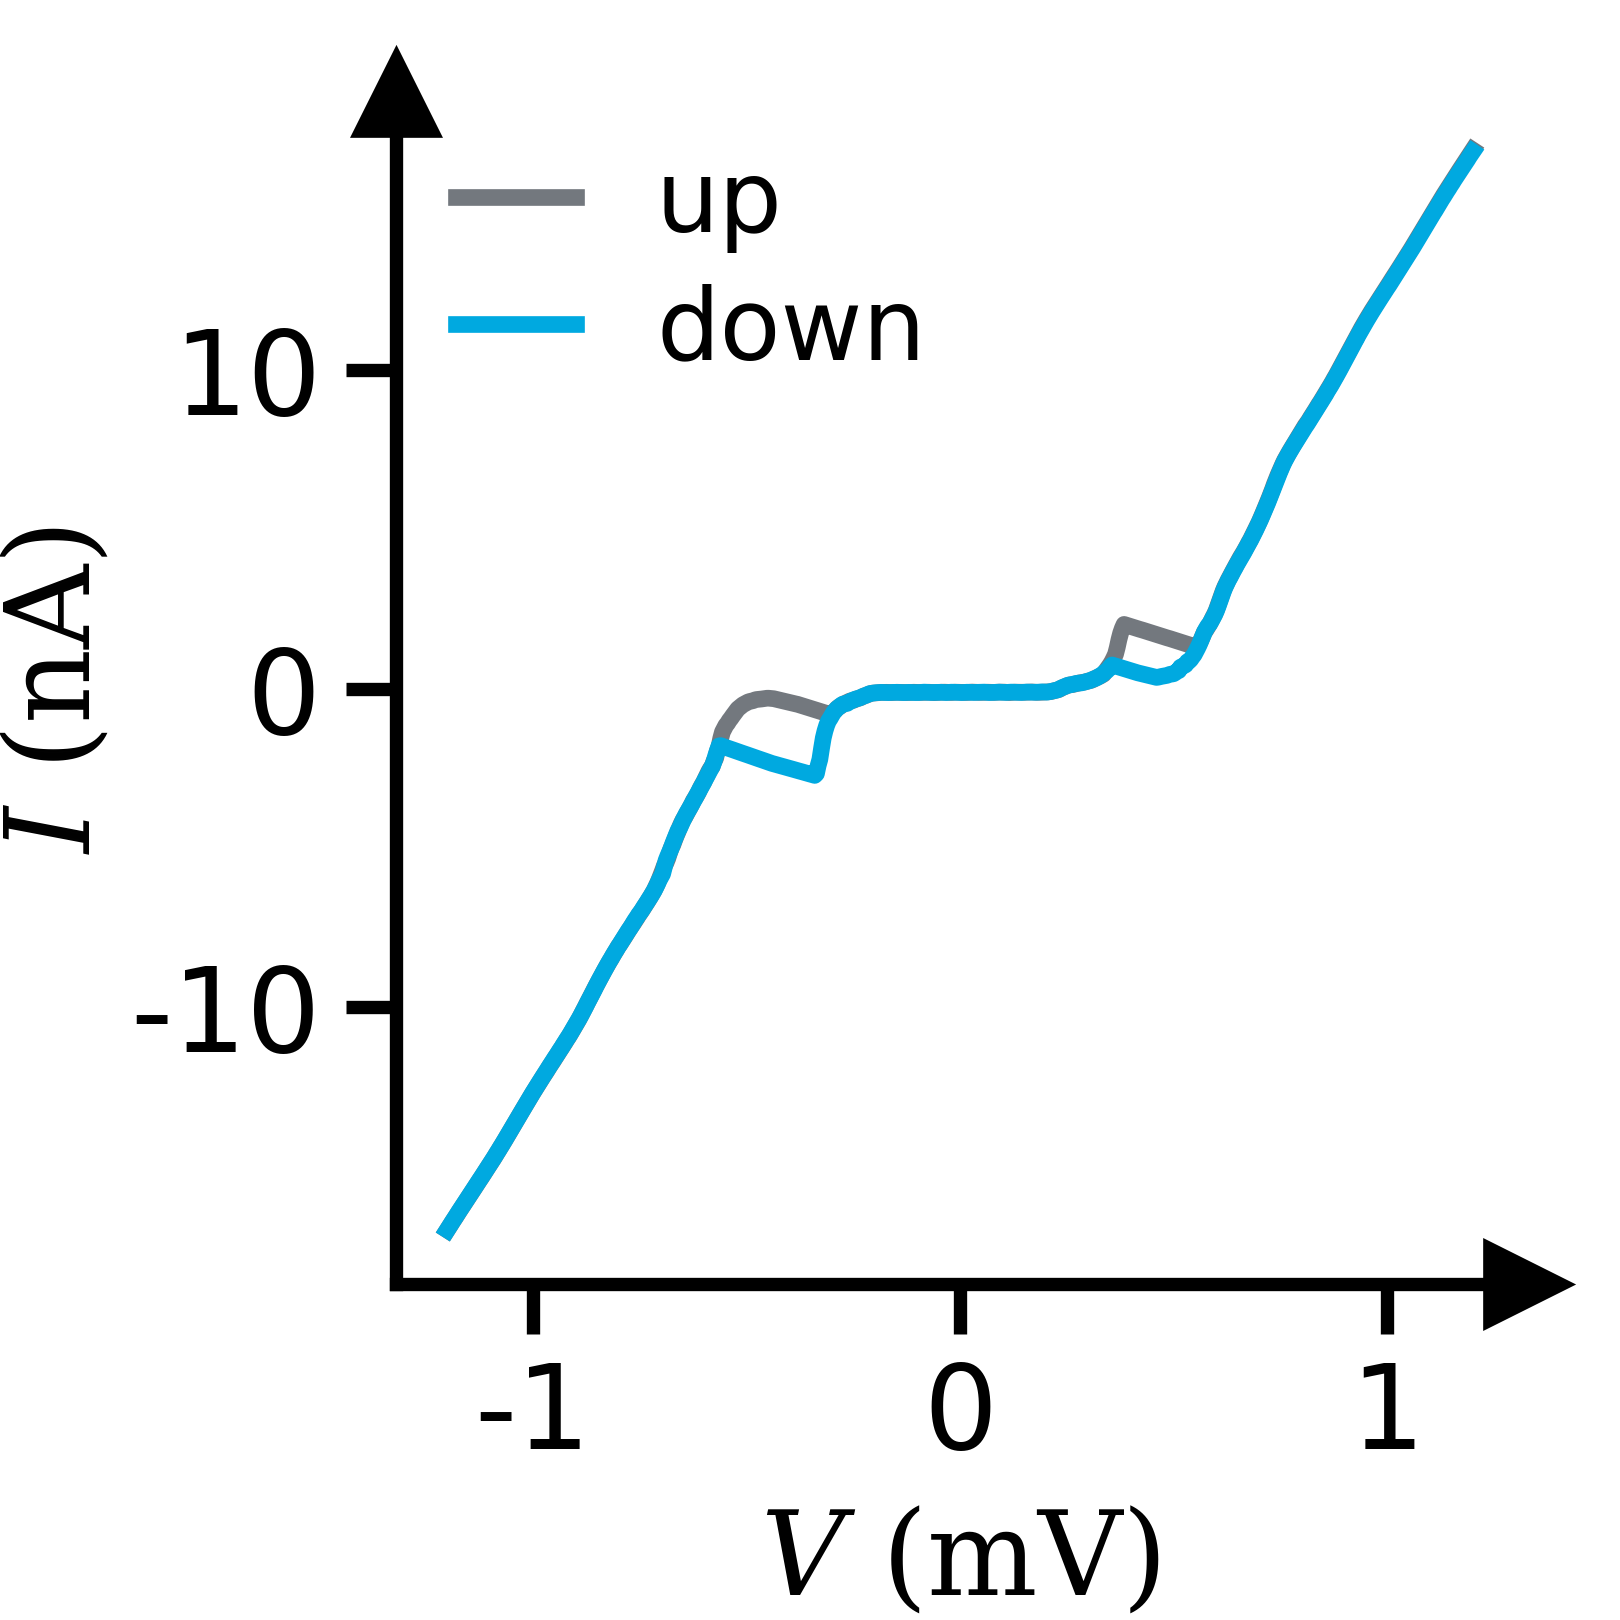

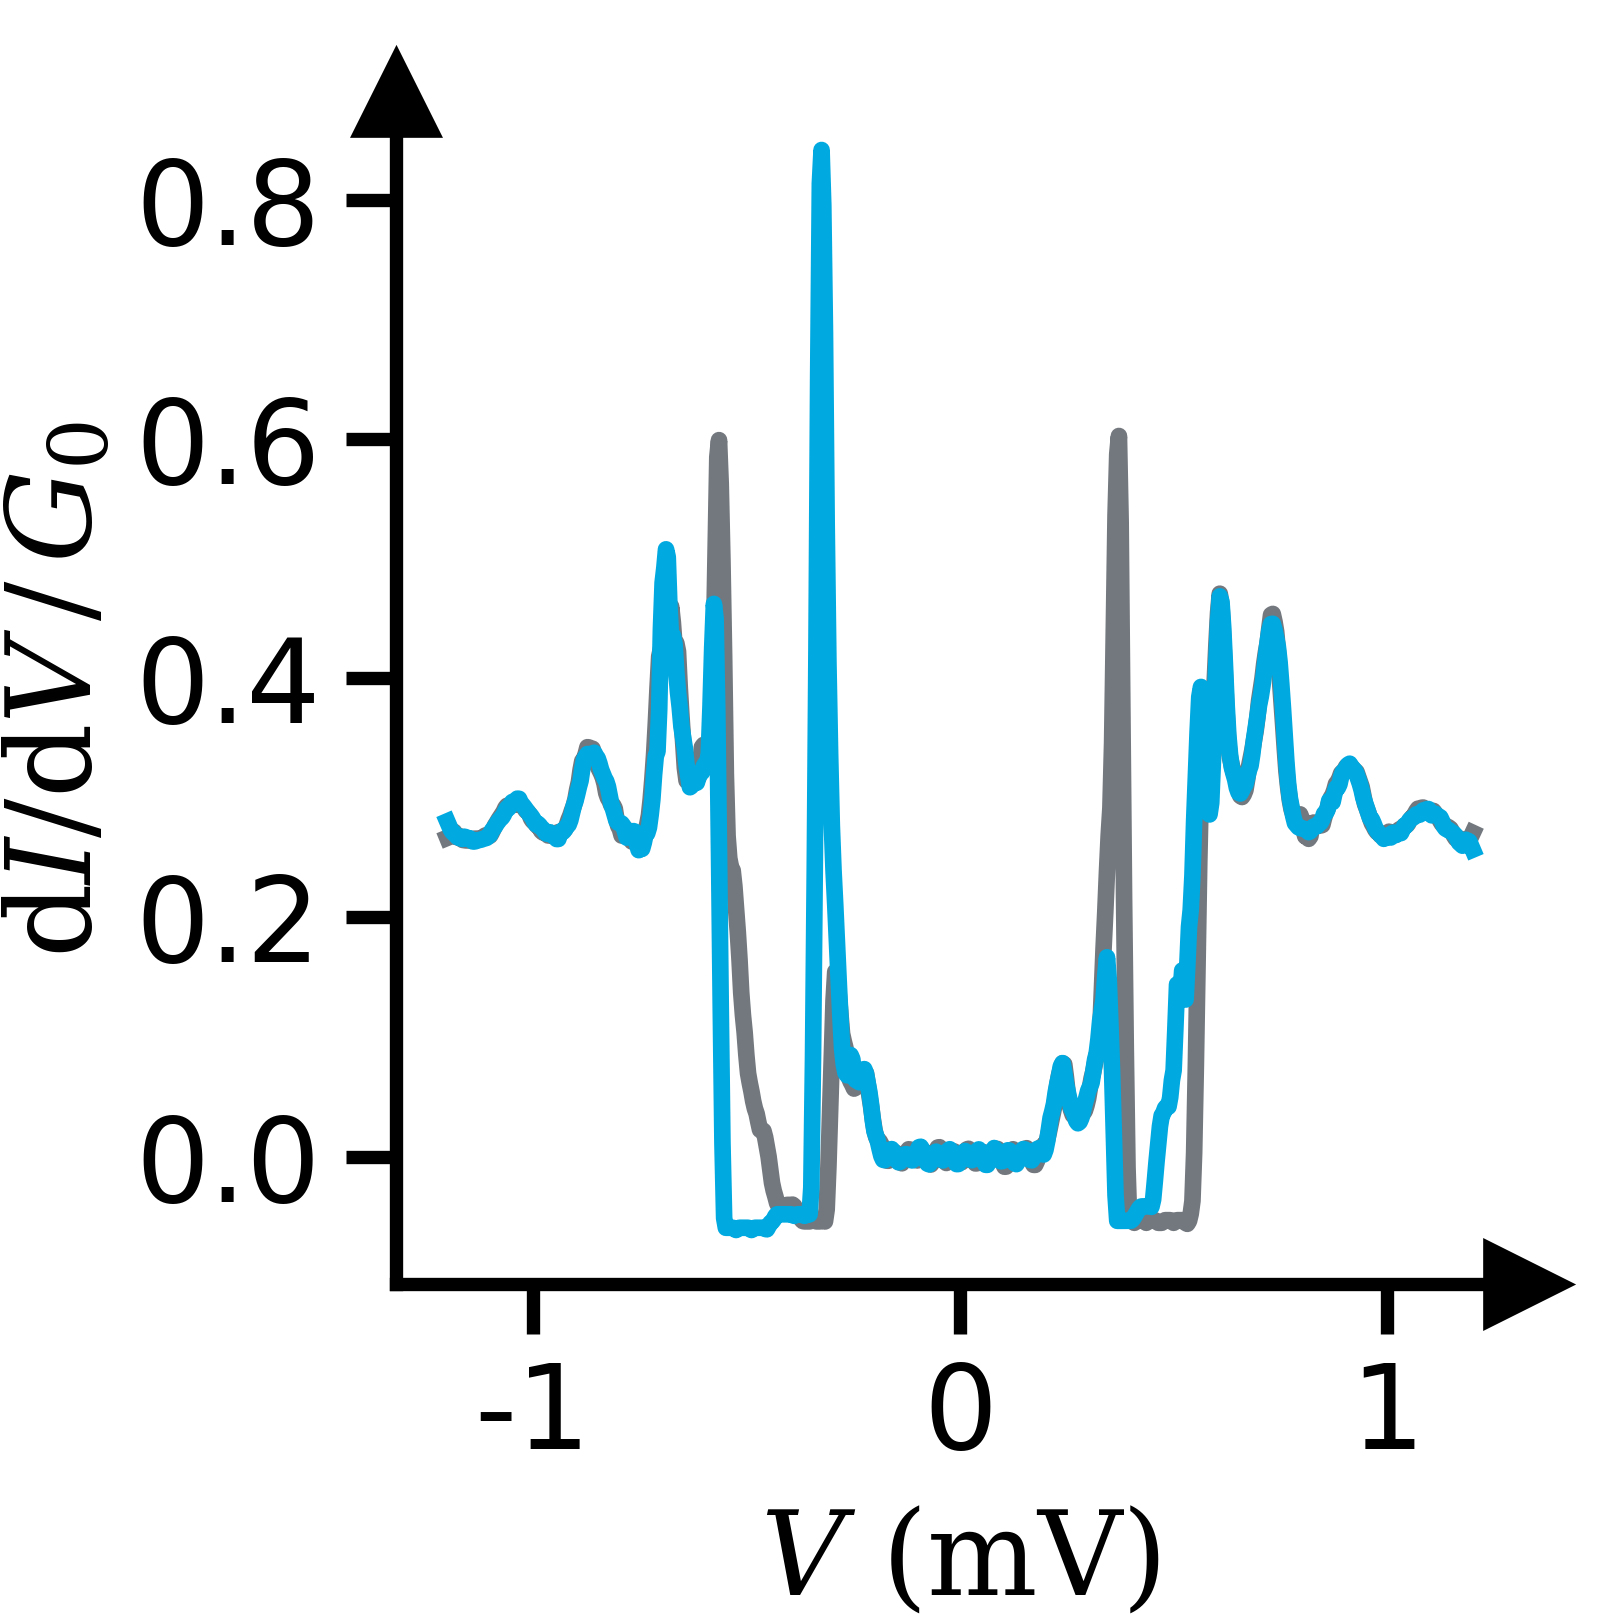

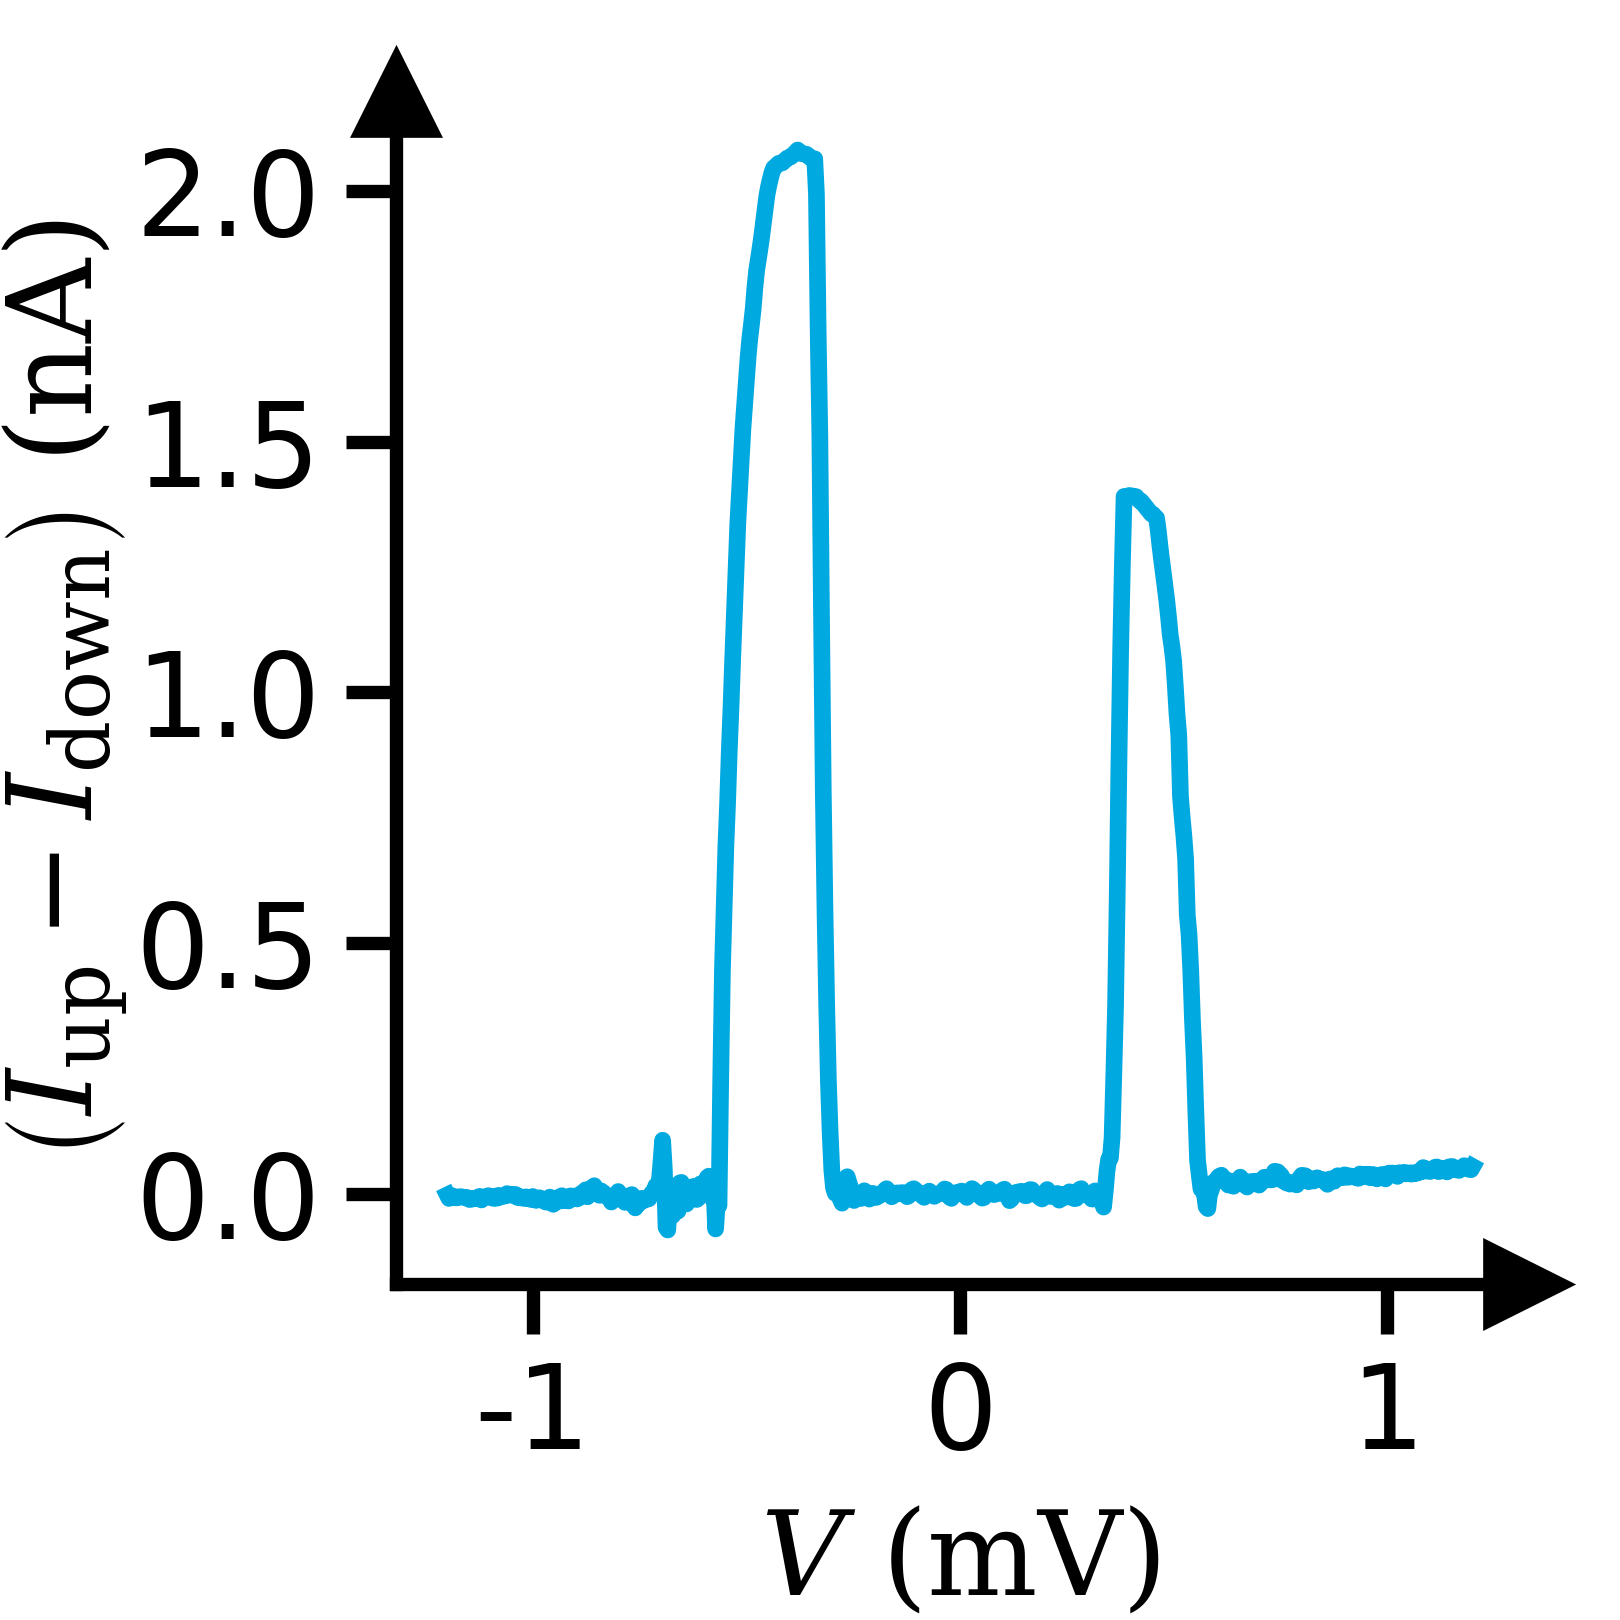

In [134]:
# plot single-iv cs
index = 21
fig, ax = sc.get_figure(figsize=(1.35, 1.35), padding=(0.25, 0.2))
ax.plot(
    # Sample_up_V[index] * 1e3 / amp[0],
    # Reference_up_V[index] * 1e9 / (amp[1] * rref),
    Vbias_mV,
    Iup_nA[index, :],
    "-",
    color=sc.seegrau100,
    ms=1.0,
    label="up",
    zorder=-1,
)
ax.plot(
    # Sample_down_V[index] * 1e3 / amp[0],
    # Reference_down_V[index] * 1e9 / (amp[1] * rref),
    Vbias_mV,
    Idown_nA[index, :],
    "-",
    color=sc.seeblau100,
    label="down",
    zorder=0,
)
# ax.set_yticks([0, 20, 40, 60])
# ax.set_ylim(-33, 33)
# ax.set_xticks([0, 0.2, 0.4])
# ax.set_xlim(-1.1, 1.1)

ax.legend(
    # title="$\\alpha_q = $",
    handlelength=1.2,
    loc="upper left",
    frameon=False,
    fontsize=6,
    title_fontsize=6,
    ncols=1,
    columnspacing=0.8,
    borderpad=0.1,  # reduces padding inside the legend box
    labelspacing=0.3,  # reduces vertical spacing between items
    handletextpad=0.8,  # reduces spacing between line and label
    # bbox_to_anchor=(1.1, 1.1),
)
sc.theory_layout(
    fig,
    ax,
    f"ssn-set/ssn1-sisin/iv",
    "$V\\ \\mathrm{(mV)}$",
    "$I\\ \\mathrm{(nA)}$",
)
plt.show()

fig, ax = sc.get_figure(figsize=(1.35, 1.35), padding=(0.25, 0.2))
ax.plot(
    Vbias_mV,
    savgol_filter(np.gradient(Iup_nA[index, :], Vbias_mV) / sc.G0_muS, 5, 1),
    "-",
    color=sc.seegrau100,
    ms=1.0,
)
ax.plot(
    Vbias_mV,
    savgol_filter(np.gradient(Idown_nA[index, :], Vbias_mV) / sc.G0_muS, 5, 1),
    "-",
    color=sc.seeblau100,
    ms=1.0,
)
# ax.set_ylim(-0.2, 1.7)
# ax.set_xlim(-1.1, 1.1)
sc.theory_layout(
    fig,
    ax,
    f"ssn-set/ssn1-sisin/didv",
    "$V\\ \\mathrm{(mV)}$",
    "$\\mathrm{d}I/\\mathrm{d}V\\,/\\,G_0$",
)
plt.show()

fig, ax = sc.get_figure(figsize=(1.35, 1.35), padding=(0.25, 0.2))
ax.plot(
    Vbias_mV,
    Iup_nA[index, :] - Idown_nA[index, :],
    "-",
    color=sc.seeblau100,
    ms=1.0,
)
# ax.set_ylim(-1, 30)
# ax.set_xlim(-1.1, 1.1)
sc.theory_layout(
    fig,
    ax,
    f"ssn-set/ssn1-sisin/dvdi",
    "$V\\ \\mathrm{(mV)}$",
    "$\\left(I_\\mathrm{up}-I_\\mathrm{down}\\right)\\ \\mathrm{(nA)}$",
)
plt.show()

In [160]:
# get midres data
Vbias_mV = np.linspace(-1.2, 1.2, 1201)
Ibias_nA = np.linspace(-18, 18, 1801)
Vgate_mV = -np.array(values, dtype=np.float64) * 1e3

Iup_nA = np.zeros((Vgate_mV.shape[0], Vbias_mV.shape[0]))
Vup_mV = np.zeros((Vgate_mV.shape[0], Ibias_nA.shape[0]))
Idown_nA = np.zeros((Vgate_mV.shape[0], Vbias_mV.shape[0]))
Vdown_mV = np.zeros((Vgate_mV.shape[0], Ibias_nA.shape[0]))

for i, key in enumerate(tqdm(keys)):
    vup_mV = Sample_up_V[i] * 1e3 / amp[0]
    iup_nA = Reference_up_V[i] * 1e9 / (amp[1] * rref)
    vdown_mV = Sample_down_V[i] * 1e3 / amp[0]
    idown_nA = Reference_down_V[i] * 1e9 / (amp[1] * rref)

    valid = np.logical_and(np.isfinite(vup_mV), np.isfinite(iup_nA))
    iup_nA, vup_mV = upsample(iup_nA[valid]), upsample(vup_mV[valid])
    # iup_nA, vup_mV = (iup_nA[valid]), (vup_mV[valid])
    Iup_nA[i, :] = sc.bin_y_over_x(iup_nA, vup_mV, Vbias_mV)
    Vup_mV[i, :] = sc.bin_y_over_x(vup_mV, iup_nA, Ibias_nA)

    valid = np.logical_and(np.isfinite(vdown_mV), np.isfinite(idown_nA))
    idown_nA, vdown_mV = upsample(idown_nA[valid]), upsample(vdown_mV[valid])
    # idown_nA, vdown_mV = (idown_nA[valid]), (vdown_mV[valid])
    Idown_nA[i, :] = sc.bin_y_over_x(idown_nA, vdown_mV, Vbias_mV)
    Vdown_mV[i, :] = sc.bin_y_over_x(vdown_mV, idown_nA, Ibias_nA)

Idown_nA /= 2
Iup_nA /= 2

100%|██████████| 81/81 [00:05<00:00, 16.16it/s]


In [161]:
Delta_meV = 0.196106
Ctotal_fF = 1.2083
Cgate_fF = 0.03732
nG0 = 0.2130
e_per_fF_mV = 6.241509
Ec_meV = 0.0801088 / Ctotal_fF
dVgate = Vgate_mV * Cgate_fF * e_per_fF_mV

GN_G0 = 0.2283

Vbias = Vbias_mV / Delta_meV
Vgate = dVgate - nG0

Iup = Iup_nA / (Delta_meV * GN_G0 * sc.G0_muS)
Idown = Idown_nA / (Delta_meV * GN_G0 * sc.G0_muS)

dGup = np.gradient(Iup, Vbias, axis=-1)
dGdown = np.gradient(Idown, Vbias, axis=-1)

In [162]:
# dI = (Iup - Idown) * np.sign(Vbias)
test_up = dGup / Vbias**2
test_down = dGdown / Vbias**2
index_up = 700 + np.nanargmax(test_up[:, 700:], axis=1) + 1
index_down = np.nanargmax(test_down[:, :501], axis=1) - 1

Vsw_pos = np.zeros_like(Vgate)
Isw_pos = np.zeros_like(Vgate)
Vsw_neg = np.zeros_like(Vgate)
Isw_neg = np.zeros_like(Vgate)
for i, ind in enumerate(index_up):
    Vsw_pos[i] = Vbias[index_up[i]]
    Isw_pos[i] = Iup[i, index_up[i]]
    Vsw_neg[i] = Vbias[index_down[i]]
    Isw_neg[i] = Idown[i, index_down[i]]
Vsw_pos[35] = np.nan
Isw_pos[35] = np.nan

# plt.pcolormesh(Vbias, Vgate, dGdiff)
# plt.plot(Vsw_pos, Vgate, "r.")
# plt.plot(Vsw_neg, Vgate, "r.")
# plt.plot(Vgate, Isw_pos, "r.")
# plt.plot(Vgate, Isw_neg, "r.")

/var/folders/kc/8fnzl3f94vxgl8w4wm3wfvk80000gn/T/ipykernel_58214/2633378790.py:2: RuntimeWarning: divide by zero encountered in divide
  test_up = dGup / Vbias**2
/var/folders/kc/8fnzl3f94vxgl8w4wm3wfvk80000gn/T/ipykernel_58214/2633378790.py:3: RuntimeWarning: divide by zero encountered in divide
  test_down = dGdown / Vbias**2


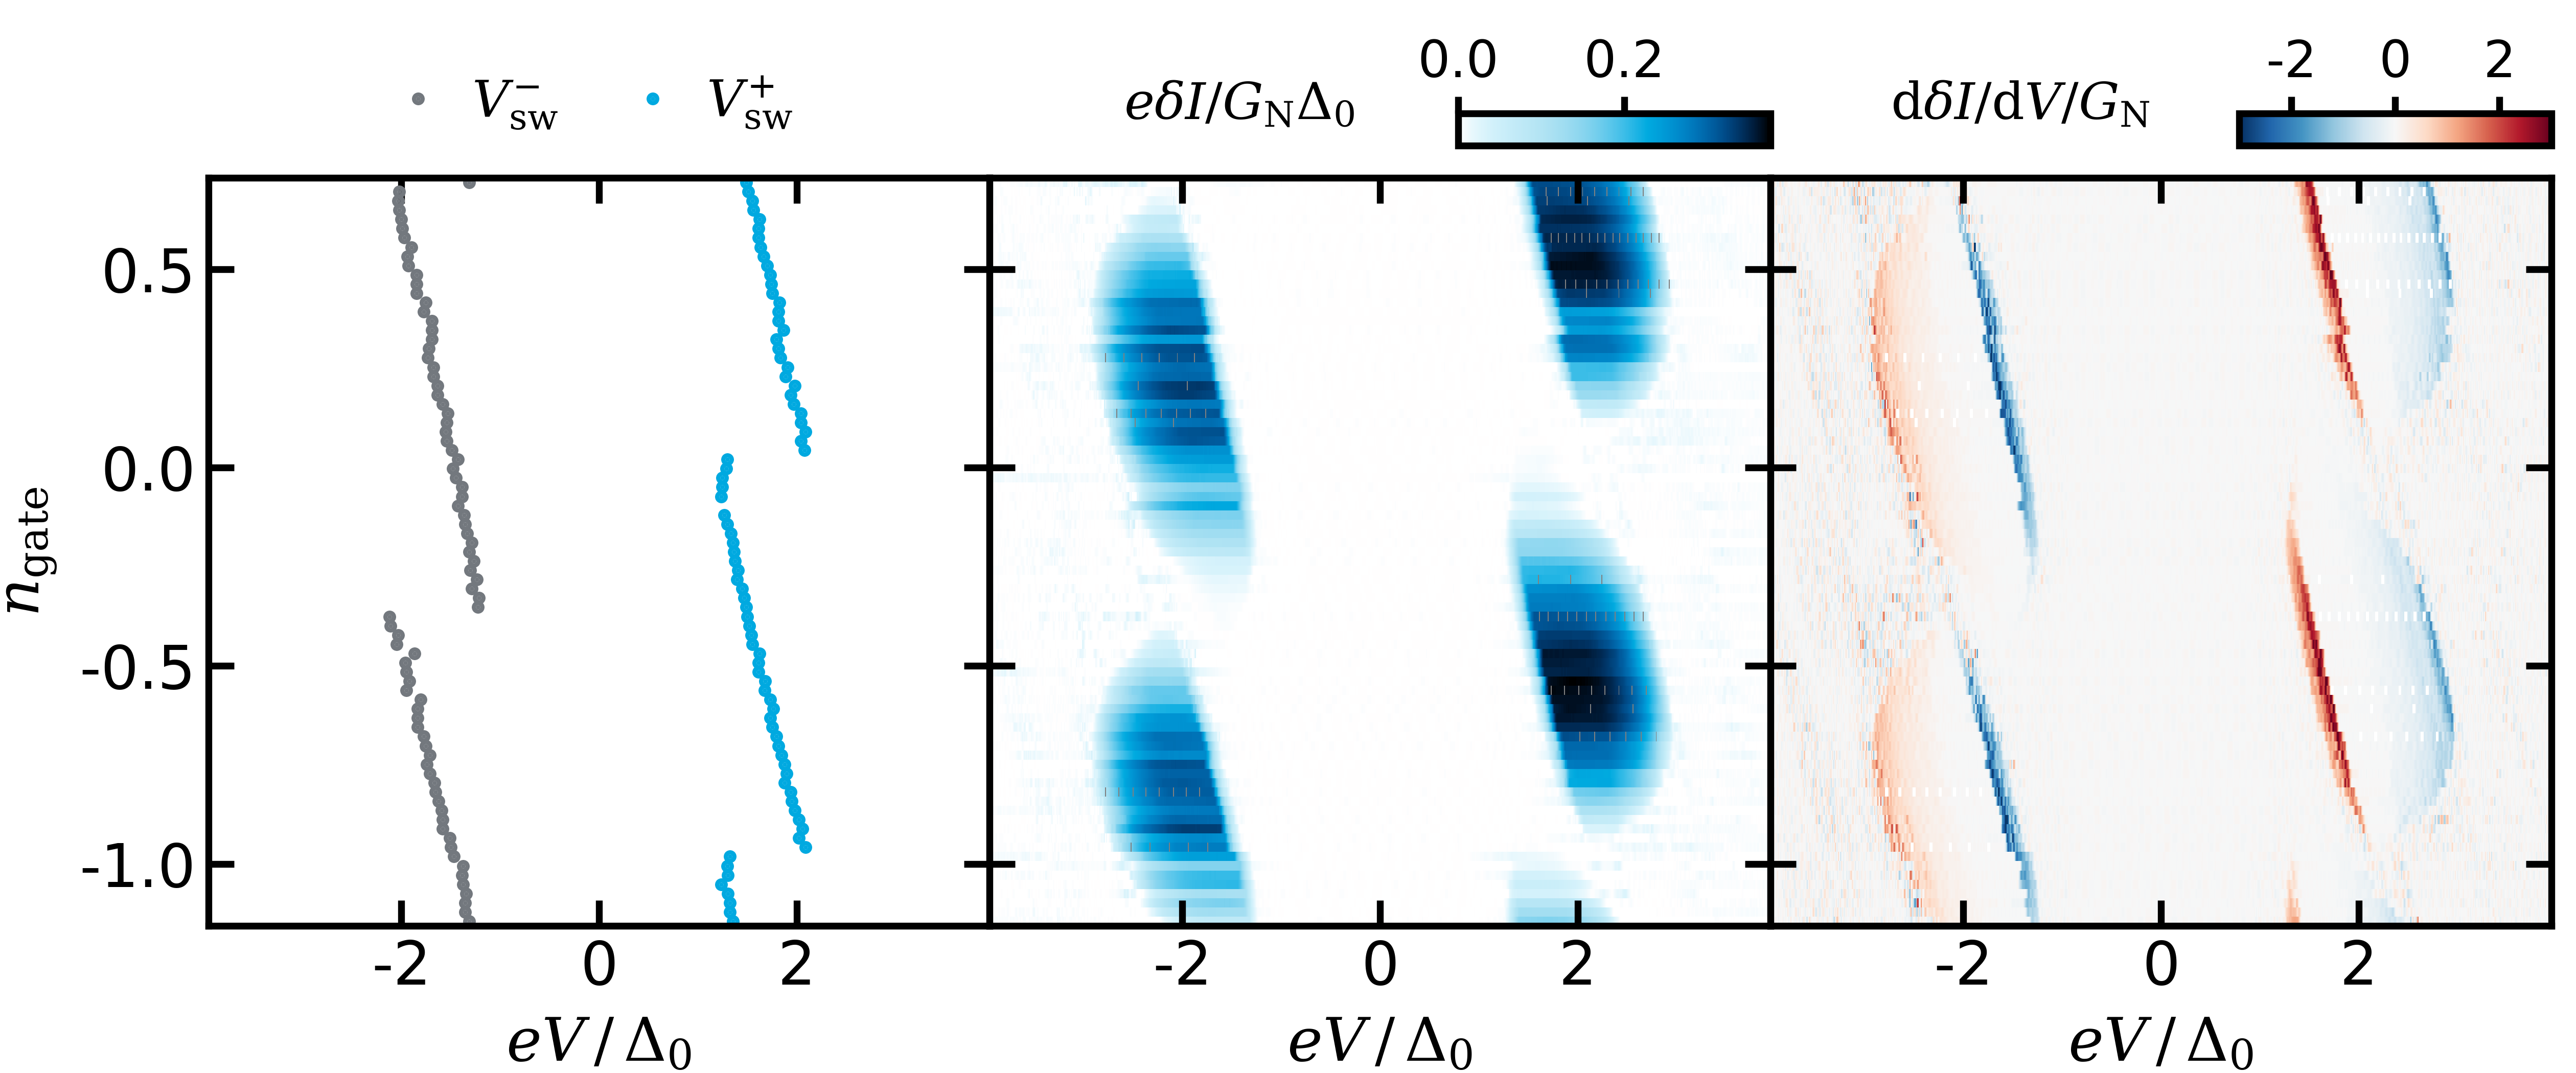

In [138]:
# region dIdV difference
fig, axes = sc.get_figures(
    figsize=(4.2, 1.75), padding=(0.3, 0.2, 0.0, 0.25), nrows=1, ncols=3
)

axes[0].plot(Vsw_neg, Vgate, ".", color=sc.seegrau100, label="$V_{\\mathrm{sw}}^{-}$")
axes[0].plot(Vsw_pos, Vgate, ".", color=sc.seeblau100, label="$V_{\\mathrm{sw}}^{+}$")
img1 = axes[1].pcolormesh(
    Vbias,
    Vgate,
    Iup - Idown,
    # cmap="RdBu_r",
    cmap=sc.get_cmap(inverse=True, bad="grey"),
    clim=(0, None),
    rasterized=True,
)
img2 = axes[2].pcolormesh(
    Vbias,
    Vgate,
    np.gradient(Iup - Idown, Vbias, axis=-1),
    cmap="RdBu_r",
    # cmap=sc.get_cmap(inverse=True),
    clim=(-3, 3),
    rasterized=True,
)
xlim = axes[2].get_xlim()
ylim = axes[2].get_ylim()
for i, ax in enumerate(axes):
    ax.set_ylim(ylim)
    ax.set_xlim(-3.95, 3.95)

axes[0].legend(
    # title="$eA\\,/\\,h\\nu$",
    handlelength=0.5,
    loc="center",
    frameon=False,
    fontsize=6,
    title_fontsize=6,
    ncols=2,
    columnspacing=1.6,
    borderpad=0.1,  # reduces padding inside the legend box
    labelspacing=0.3,  # reduces vertical spacing between items
    handletextpad=0.8,  # reduces spacing between line and label
    bbox_to_anchor=(0.5, 1.1),
)

sc.daumenkino_layout(
    fig,
    axes,
    ylabel="$n_\\mathrm{gate}$",
    xlabel="$eV\\,/\\,\\Delta_0$",
    xticks=[-2, 0, 2],
)

upper_edge = axes[1].get_position().y1
left = axes[1].get_position().x0
right = axes[1].get_position().x1

width = right - left
shrink = 0.4
new_width = width * shrink
new_left = left + 0.5 * (width - new_width)
new_left = left + (width - new_width)

cax1 = fig.add_axes([new_left, upper_edge + 0.03, new_width, 0.03])
cax1.text(
    -0.7,
    0.5,
    "$e\\delta I/G_\\mathrm{N}\\Delta_0$",
    transform=cax1.transAxes,
    ha="center",
    va="bottom",
    size=6,
)

cbar1 = fig.colorbar(
    img1,
    cax=cax1,
    orientation="horizontal",
    # ticks=[-1, 0, 2],
)
cbar1.ax.tick_params(
    labelsize=6,
    length=2,
    labelrotation=0,
    top=True,
    bottom=False,
    labeltop=True,
    labelbottom=False,
    pad=1,
)
upper_edge = axes[2].get_position().y1
left = axes[2].get_position().x0
right = axes[2].get_position().x1

width = right - left
shrink = 0.4
new_width = width * shrink
new_left = left + 0.5 * (width - new_width)
new_left = left + (width - new_width)

cax2 = fig.add_axes([new_left, upper_edge + 0.03, new_width, 0.03])
cax2.text(
    -0.7,
    0.5,
    "$\\mathrm{d}\\delta I/\\mathrm{d}V/G_\\mathrm{N}$",
    transform=cax2.transAxes,
    ha="center",
    va="bottom",
    size=6,
)

cbar2 = fig.colorbar(
    img2,
    cax=cax2,
    orientation="horizontal",
    ticks=[-2, 0, 2],
)
cbar2.ax.tick_params(
    labelsize=6,
    length=2,
    labelrotation=0,
    top=True,
    bottom=False,
    labeltop=True,
    labelbottom=False,
    pad=1,
)
save_figure(fig, title=f"ssn-set/ssn1-sset-Ic/dGdiff")
# endregion

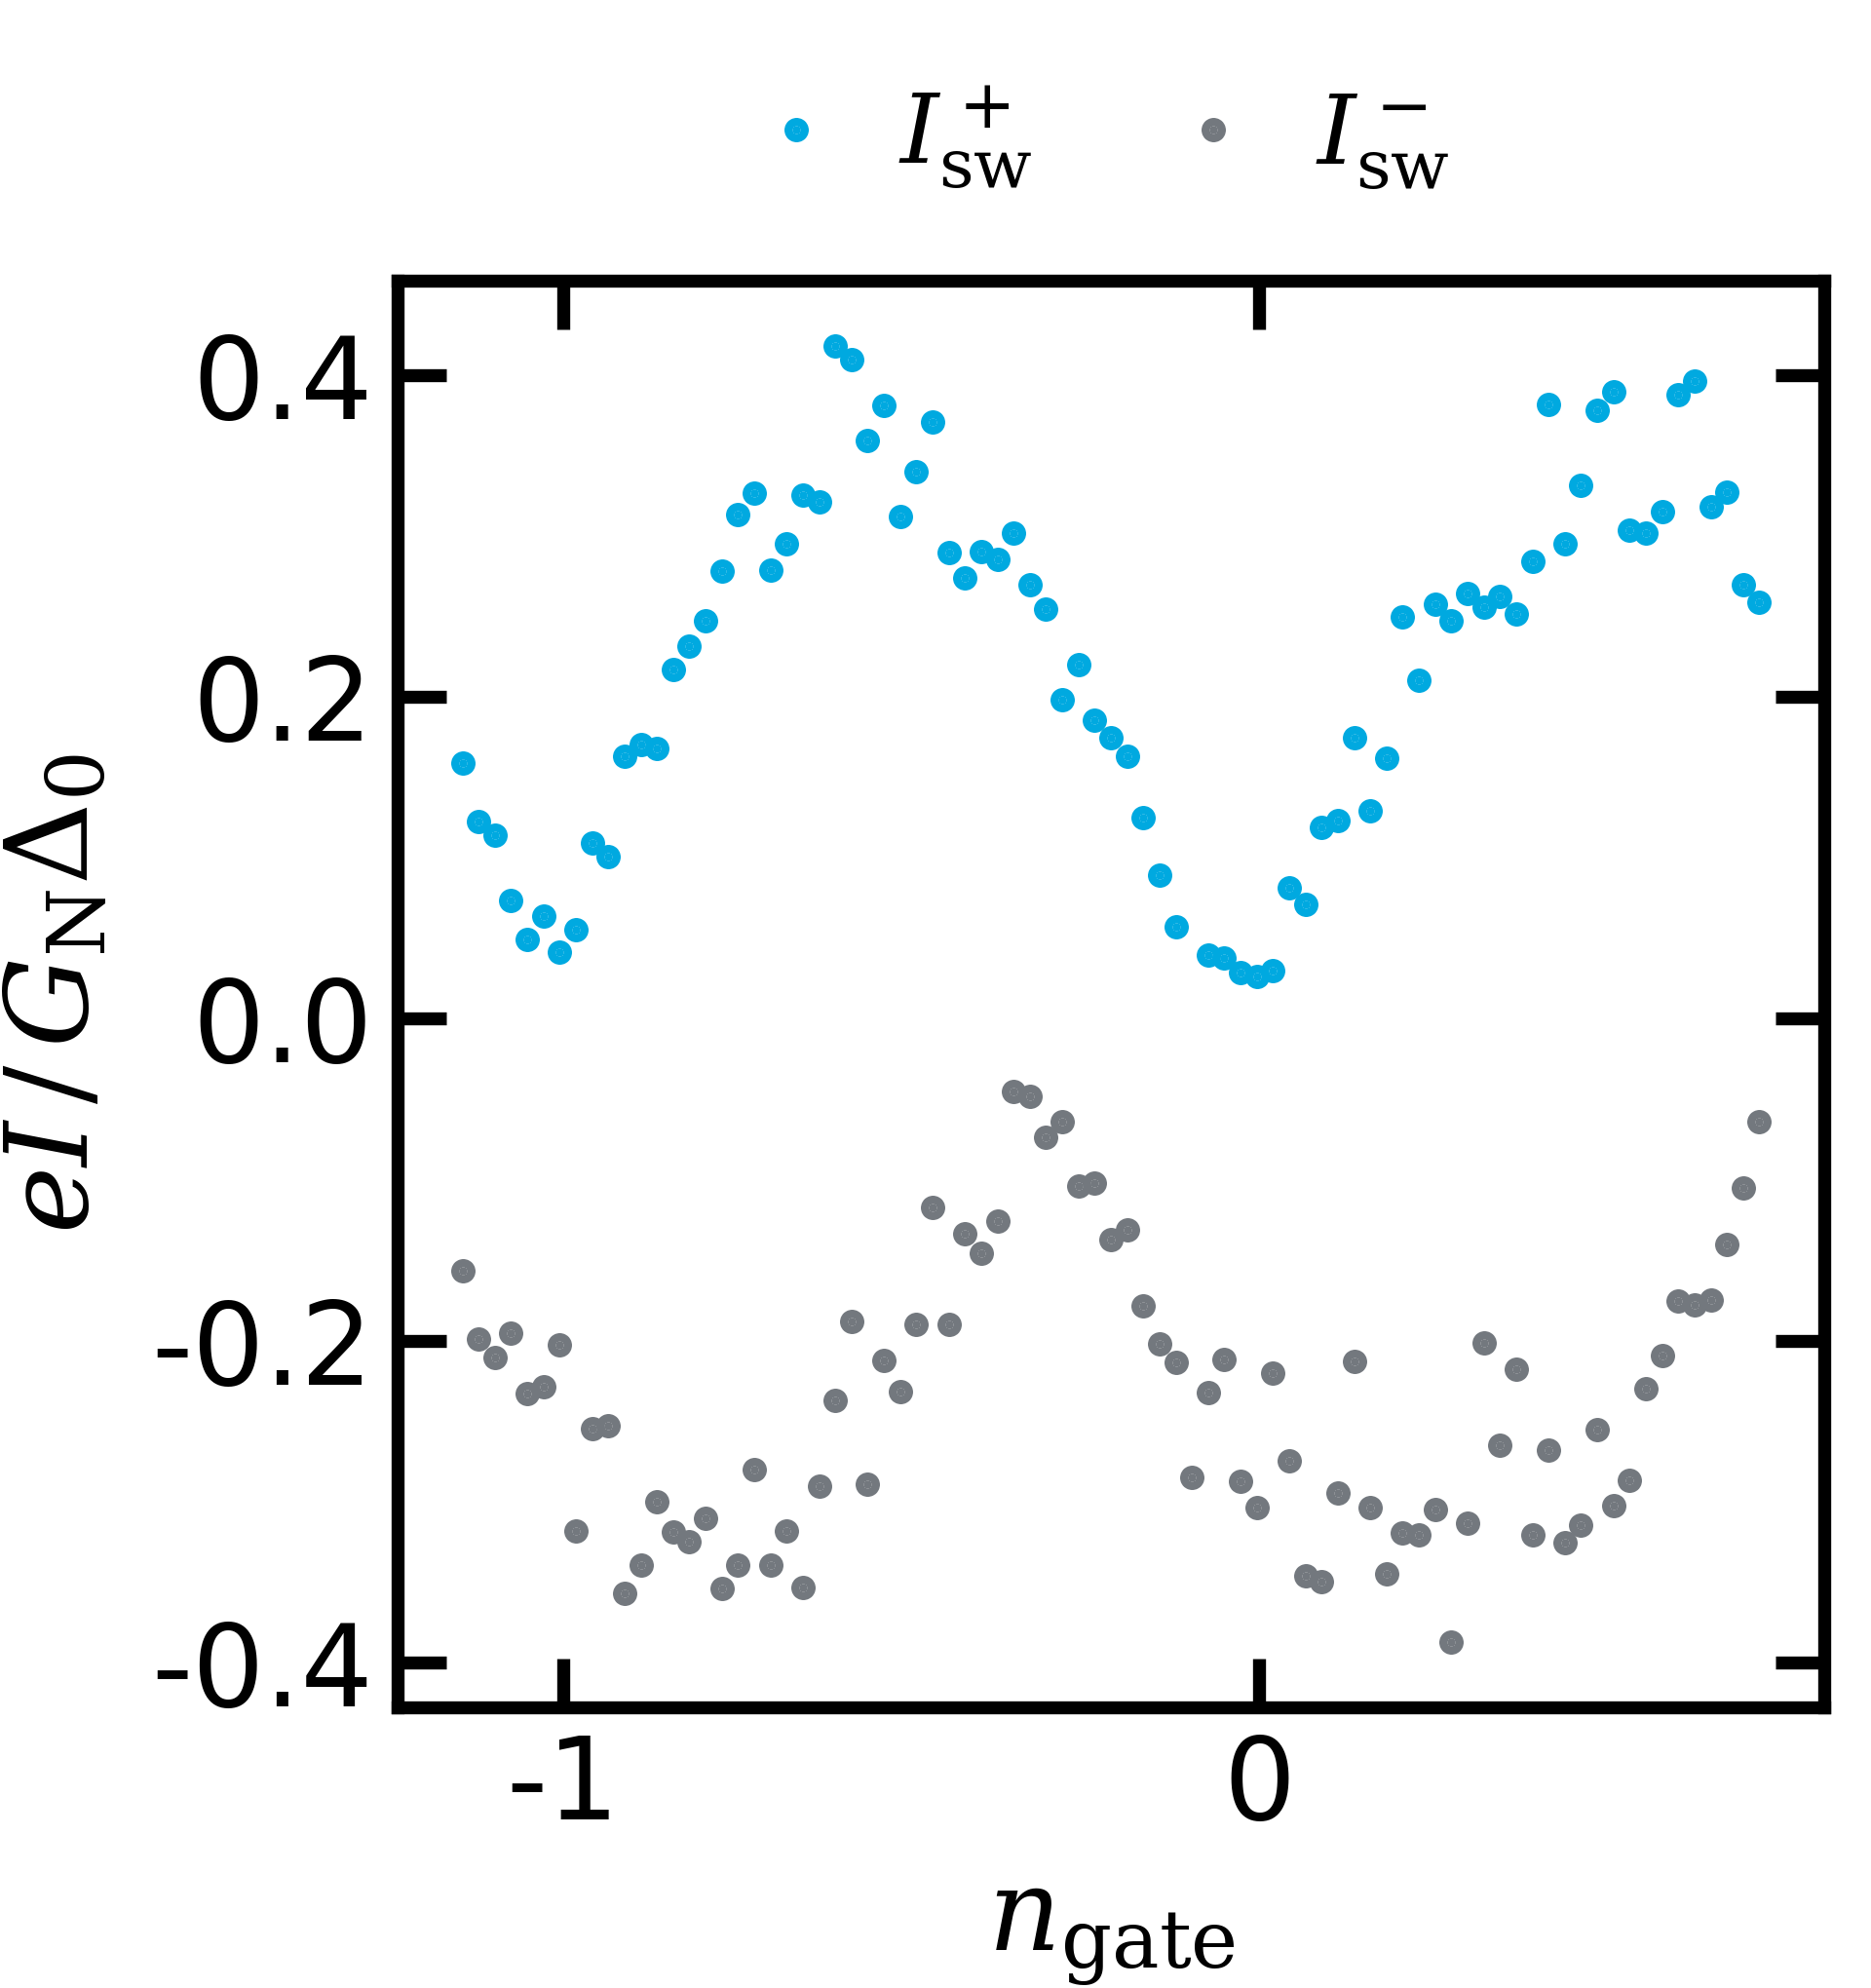

In [139]:
# region dIdV difference
fig, axes = sc.get_figures(
    figsize=(1.6, 1.7), padding=(0.3, 0.2, 0.0, 0.2), nrows=1, ncols=1
)

axes[0].plot(
    Vgate, Isw_pos, ".", color=sc.seeblau100, label="$I_{\\mathrm{sw}}^+$", zorder=0
)
axes[0].plot(
    Vgate, Isw_neg, ".", color=sc.seegrau100, label="$I_{\\mathrm{sw}}^-$", zorder=0
)
# for i, ax in enumerate(axes):
#     ax.set_xlim(None, None)
#     ax.set_ylim(-0.7, 0.7)

axes[0].legend(
    handlelength=0.5,
    loc="center",
    frameon=False,
    fontsize=6,
    title_fontsize=6,
    ncols=2,
    columnspacing=1.6,
    borderpad=0.1,  # reduces padding inside the legend box
    labelspacing=0.3,  # reduces vertical spacing between items
    handletextpad=0.8,  # reduces spacing between line and label
    bbox_to_anchor=(0.5, 1.1),
)

axes = sc.daumenkino_layout(
    fig,
    axes,
    title=f"ssn-set/ssn1-sset-Ic/Ic",
    xlabel="$n_\\mathrm{gate}$",
    ylabel="$eI\\,/\\,G_\\mathrm{N}\\Delta_0$",
    # yticks=[-0.6, -0.3, 0, 0.3, 0.6],
)
# endregion

In [143]:
# get midres data
Vbias_mV = np.linspace(-1.2, 1.2, 301)
Ibias_nA = np.linspace(-18, 18, 301)
Vgate_mV = -np.array(values, dtype=np.float64) * 1e3

Iup_nA = np.zeros((Vgate_mV.shape[0], Vbias_mV.shape[0]))
Vup_mV = np.zeros((Vgate_mV.shape[0], Ibias_nA.shape[0]))
Idown_nA = np.zeros((Vgate_mV.shape[0], Vbias_mV.shape[0]))
Vdown_mV = np.zeros((Vgate_mV.shape[0], Ibias_nA.shape[0]))

for i, key in enumerate(tqdm(keys)):
    vup_mV = Sample_up_V[i] * 1e3 / amp[0]
    iup_nA = Reference_up_V[i] * 1e9 / (amp[1] * rref)
    vdown_mV = Sample_down_V[i] * 1e3 / amp[0]
    idown_nA = Reference_down_V[i] * 1e9 / (amp[1] * rref)

    valid = np.logical_and(np.isfinite(vup_mV), np.isfinite(iup_nA))
    iup_nA, vup_mV = upsample(iup_nA[valid]), upsample(vup_mV[valid])
    # iup_nA, vup_mV = (iup_nA[valid]), (vup_mV[valid])
    Iup_nA[i, :] = sc.bin_y_over_x(iup_nA, vup_mV, Vbias_mV)
    Vup_mV[i, :] = sc.bin_y_over_x(vup_mV, iup_nA, Ibias_nA)

    valid = np.logical_and(np.isfinite(vdown_mV), np.isfinite(idown_nA))
    idown_nA, vdown_mV = upsample(idown_nA[valid]), upsample(vdown_mV[valid])
    # idown_nA, vdown_mV = (idown_nA[valid]), (vdown_mV[valid])
    Idown_nA[i, :] = sc.bin_y_over_x(idown_nA, vdown_mV, Vbias_mV)
    Vdown_mV[i, :] = sc.bin_y_over_x(vdown_mV, idown_nA, Ibias_nA)
    Delta_meV = 0.196106

Ctotal_fF = 1.2083
Cgate_fF = 0.03732
nG0 = 0.2130
e_per_fF_mV = 6.241509
Ec_meV = 0.0801088 / Ctotal_fF
dVgate = Vgate_mV * Cgate_fF * e_per_fF_mV

GN_G0 = 0.2283

Vbias = Vbias_mV / Delta_meV
Vgate = dVgate - nG0

Iup = Iup_nA / (Delta_meV * GN_G0 * sc.G0_muS)
Idown = Idown_nA / (Delta_meV * GN_G0 * sc.G0_muS)

dGup = np.gradient(Iup, Vbias, axis=-1)
dGdown = np.gradient(Idown, Vbias, axis=-1)

100%|██████████| 81/81 [00:04<00:00, 19.86it/s]


In [144]:
np.median(dGup)

np.float64(1.1674513978739682)

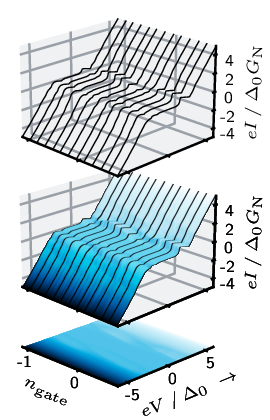

/Users/oliver/Documents/cryolab/dissertation-figures/ssn-set/ssn1-sset-iv/cal_iv/main.png

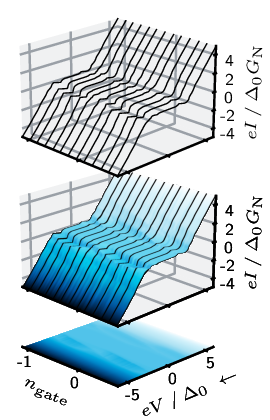

/Users/oliver/Documents/cryolab/dissertation-figures/ssn-set/ssn1-sset-iv/cal_didv/main.png

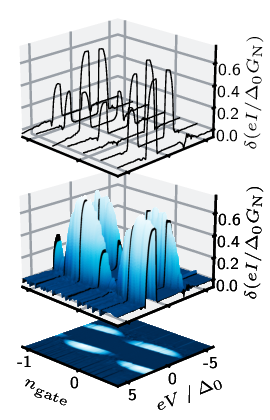

/Users/oliver/Documents/cryolab/dissertation-figures/ssn-set/ssn1-sset-iv/cal_dvdi/main.png

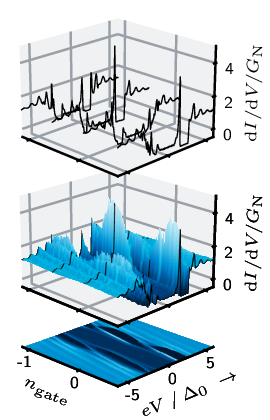

/Users/oliver/Documents/cryolab/dissertation-figures/ssn-set/ssn1-sset-didv/cal_iv/main.png

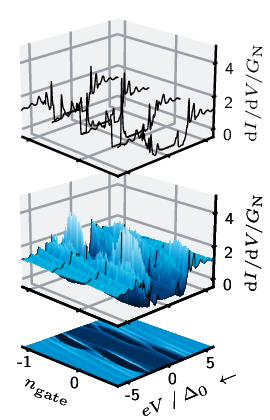

/Users/oliver/Documents/cryolab/dissertation-figures/ssn-set/ssn1-sset-didv/cal_didv/main.png

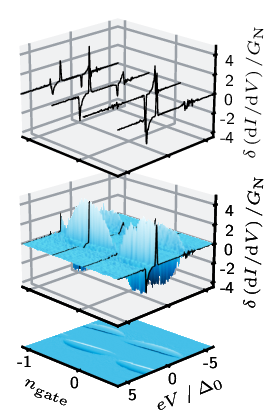

/Users/oliver/Documents/cryolab/dissertation-figures/ssn-set/ssn1-sset-didv/cal_dvdi/main.png

In [146]:
# ssn-set
from superconductivity.visuals.landscape import export_landscape_thesis

exports = export_landscape_thesis(
    Vbias=Vbias,
    Abias=Vgate,
    Ibias=Vbias,
    Iexp=Iup,
    dGexp=Idown,
    dRexp=Iup - Idown,
    waterfall_traces=13,
    name="cal",
    sub_dir=f"ssn-set/ssn1-sset-iv/",
    surface_points=(300, 100),
    plots=("iv",),
    Alabel="$n_\\mathrm{gate}$",
    Vlabel="$eV\\,/\\,\\Delta_0\\ \\rightarrow$",
)
exports = export_landscape_thesis(
    Vbias=Vbias,
    Abias=Vgate,
    Ibias=Vbias,
    Iexp=Iup,
    dGexp=Idown,
    dRexp=Iup - Idown,
    waterfall_traces=13,
    name="cal",
    sub_dir=f"ssn-set/ssn1-sset-iv/",
    surface_points=(300, 100),
    plots=("didv",),
    Alabel="$n_\\mathrm{gate}$",
    Vlabel="$eV\\,/\\,\\Delta_0\\ \\leftarrow$",
    dGlabel="$eI\\,/\\,\\Delta_0G_\\mathrm{N}$",
)
exports = export_landscape_thesis(
    Vbias=Vbias,
    Abias=Vgate,
    Ibias=Vbias,
    Iexp=Iup,
    dGexp=dGup,
    dRexp=Iup - Idown,
    waterfall_traces=7,
    name="cal",
    sub_dir=f"ssn-set/ssn1-sset-iv/",
    surface_points=(300, 100),
    Alabel="$n_\\mathrm{gate}$",
    Ilabel="$eV\\,/\\,\\Delta_0$",
    dRlabel="$\\delta\\!\\left(eI/\\Delta_0G_\\mathrm{N}\\right)$",
    plots=("dvdi",),
)

exports = export_landscape_thesis(
    Vbias=Vbias,
    Abias=Vgate,
    Ibias=Vbias,
    Iexp=dGup,
    dGexp=dGdown,
    dRexp=dGup - dGdown,
    waterfall_traces=4,
    name="cal",
    sub_dir=f"ssn-set/ssn1-sset-didv/",
    surface_points=(300, 100),
    plots=("iv",),
    Ilim=(-0.5, 5),
    Iticks=[0, 2, 4],
    Alabel="$n_\\mathrm{gate}$",
    Vlabel="$eV\\,/\\,\\Delta_0\\ \\rightarrow$",
    Ilabel="$\\mathrm{d}I/\\mathrm{d}V/G_\\mathrm{N}$",
)
exports = export_landscape_thesis(
    Vbias=Vbias,
    Abias=Vgate,
    Ibias=Vbias,
    Iexp=dGup,
    dGexp=dGdown,
    dRexp=dGup - dGdown,
    waterfall_traces=4,
    name="cal",
    sub_dir=f"ssn-set/ssn1-sset-didv/",
    surface_points=(300, 100),
    plots=("didv",),
    dGlim=(-0.5, 5),
    dGticks=[0, 2, 4],
    Alabel="$n_\\mathrm{gate}$",
    Vlabel="$eV\\,/\\,\\Delta_0\\ \\leftarrow$",
    dGlabel="$\\mathrm{d}I/\\mathrm{d}V/G_\\mathrm{N}$",
)
exports = export_landscape_thesis(
    Vbias=Vbias,
    Abias=Vgate,
    Ibias=Vbias,
    Iexp=dGup,
    dGexp=dGdown,
    dRexp=dGup - dGdown,
    waterfall_traces=4,
    name="cal",
    sub_dir=f"ssn-set/ssn1-sset-didv/",
    surface_points=(300, 100),
    Alabel="$n_\\mathrm{gate}$",
    Ilabel="$eV\\,/\\,\\Delta_0$",
    dRlabel="$\\delta\\left(\\mathrm{d}I/\\mathrm{d}V\\right)/G_\\mathrm{N}$",
    plots=("dvdi",),
    # cmap_mpl=plt.get_cmap("RdBu_r"),
)